# Winam Gulf water hyacinth spatial-panel test model

This notebook builds a **spatially explicit monthly panel dataset** from already-classified water hyacinth GeoTIFFs in Google Drive.

It is designed as a **test-period prototype**, not the final dissertation model. It:

1. mounts Google Drive;
2. finds classified WH GeoTIFFs for a chosen period;
3. creates fixed 500 m or 1 km grid cells over Winam Gulf;
4. aggregates each classified raster to `grid cell × month`;
5. pulls environmental driver covariates directly from **Google Earth Engine** — rainfall (CHIRPS), wind and air temperature (ERA5), water-surface temperature (MODIS LST), turbidity and chlorophyll-a proxies (Sentinel-2 / Sentinel-3 / MODIS), distance to rivers and shore, and catchment pressure (ESA WorldCover / WorldPop / GHSL) — and optionally merges CSV covariates for layers that have no EE asset (lake level, ENSO/IOD, bathymetry, in-situ nutrients);
6. creates lagged WH-cover and lagged environmental terms;
7. fits a simple two-stage spatial panel model:
   - WH presence/absence;
   - WH proportional cover where WH is present;
8. exports panel tables, predictions and grid outputs.

The intended response variable is **monthly WH proportional cover per spatial unit**, not pixel-level WH occurrence.

The Earth Engine layers, assets and project (`ee-bmillwardsadler1`) match those already used in `Batch_Export.ipynb` and `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`, so the same authenticated Colab runtime can run all three notebooks.

## 1. Install packages

Run this once at the start of a fresh Colab runtime.

In [9]:
# In Colab, uncomment and run this if packages are missing.
# This can take a few minutes.

# earthengine-api and geemap are needed for the Earth Engine covariate extraction
# in section 8. They match the dependencies of the classifier/export notebooks.
!pip -q install rasterio geopandas pyproj shapely fiona pyogrio statsmodels scikit-learn pygam tqdm earthengine-api geemap libpysal esda

## 2. Imports and Google Drive mount

In [10]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import box
from tqdm.auto import tqdm

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.windows import from_bounds, Window

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
)

import matplotlib.pyplot as plt

# Import the earthengine-api library
import ee

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive was not mounted automatically. If running outside Colab, this is expected.")
    print(e)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)

EE_PROJECT = 'ee-bmillwardsadler1'
ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. User configuration

Edit this cell first.

Important assumptions:

- By default this notebook now reads the **classified GeoTIFFs and run logs produced by `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb`**.
- `WH_CLASS_VALUES` is set to `[2]`, matching the classifier notebook's `FLOATING_CLASS_CODE` for floating plants / water hyacinth.
- `CLASSIFIER_SENSOR_FILTER` and `CLASSIFIER_PRODUCT_FILTER` choose which classifier output becomes the panel response. The default uses the S2 Route B model output only, so S1, rule-based rasters, and probability rasters are not accidentally averaged into the same monthly response.
- If you want to run the panel model from a manually curated folder instead, set `USE_CLASSIFIER_RUN_LOG = False` and point `CLASSIFIED_TIF_DIR` at that folder.
- The default grid CRS is **EPSG:32736**, UTM Zone 36S, which is suitable for the Winam Gulf area south of the equator.
- The default AOI is the same broad Winam Gulf rectangle used in your previous GEE workflow.


In [11]:
# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

# These defaults match Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb:
#   DRIVE_ROOT / "outputs" / "full_stack_batch"
CLASSIFIER_BATCH_OUTPUT_DIR = Path("/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch")
CLASSIFIER_TABLE_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "tables"
CLASSIFIED_TIF_DIR = CLASSIFIER_BATCH_OUTPUT_DIR / "classified_geotiffs"
CLASSIFIER_RUN_LOG_GLOB = "winam_full_stack_run_log_*.csv"

OUTPUT_DIR = Path("/content/drive/MyDrive/WH_spatial_panel_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Prefer the classifier notebook's run log because it records exactly which
# classified rasters were generated/reused for each sensor and date window.
# Set False to discover classified GeoTIFFs directly from CLASSIFIED_TIF_DIR.
USE_CLASSIFIER_RUN_LOG = True

# Classifier-output selection. Defaults intentionally keep a single response per
# month by using only S2 model classifications. Use None to include all sensors,
# or set e.g. ["S1"] if you want the SCC/S1 panel instead.
CLASSIFIER_SENSOR_FILTER = ["S2"]       # None, ["S2"], ["S1"], or ["S2", "S1"]
CLASSIFIER_PRODUCT_FILTER = "model"     # "model", "rules", or "all"
PREFER_PATCH_CLEANED_S1 = True           # run-log model paths already point to patch-cleaned files when enabled

# Optional monthly environmental covariates.
# Expected format: one row per month, with a column called 'month'.
# Example columns:
# month,rainfall_mm,wind_speed_ms,lake_level_m,turbidity,chl_a
ENV_MONTHLY_CSV = None
# ENV_MONTHLY_CSV = Path("/content/drive/MyDrive/WH_drivers/monthly_covariates.csv")

# Optional spatial covariates by grid_id.
# Expected format: one row per grid_id, with a column called 'grid_id'.
# Example columns:
# grid_id,dist_river_m,fetch_m,depth_m,shelter_index
SPATIAL_COVARIATES_CSV = None
# SPATIAL_COVARIATES_CSV = Path("/content/drive/MyDrive/WH_drivers/grid_spatial_covariates.csv")

# ---------------------------------------------------------------------
# Test period
# ---------------------------------------------------------------------

TEST_START = "2017-01-01"
TEST_END = "2026-12-31"

# ---------------------------------------------------------------------
# Spatial design
# ---------------------------------------------------------------------

# Use 500 for a more detailed panel, or 1000 for a simpler/coarser test.
# 1000 m is recommended when USE_EARTH_ENGINE is True, because the per-cell
# Earth Engine reductions scale with the number of grid cells.
CELL_SIZE_M = 500

# UTM Zone 36S. Suitable for Winam Gulf because it is just south of the equator.
PANEL_CRS = "EPSG:32736"

# Broad Winam Gulf AOI in WGS84: min_lon, min_lat, max_lon, max_lat
# This matches the `winam` rectangle used in Batch_Export.ipynb.
AOI_BBOX_WGS84 = (34.0, -0.55, 34.9, 0.0)

# ---------------------------------------------------------------------
# Classified raster settings
# ---------------------------------------------------------------------

# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb writes floating plants /
# WH-like vegetation as class code 2 (FLOATING_CLASS_CODE = 2). This is the
# response class aggregated into WH cover by the panel model.
WH_CLASS_VALUES = [2]

# The classifier notebook writes NODATA_VALUE = 255. Keep it here even if a
# GeoTIFF's nodata metadata is missing.
EXTRA_NODATA_VALUES = [255]

# Valid classifier classes. S2 uses 0-3; S1/SCC uses 0-2. Including 3 is safe for
# S1 because it simply will not occur.
VALID_CLASS_VALUES = [0, 1, 2, 3]

# Minimum valid pixels in a cell-month for that observation to be retained.
MIN_VALID_PIXELS_PER_CELL_MONTH = 10

# How to combine duplicate classified GeoTIFFs in the same month.
# With the default classifier filters, duplicates usually mean multiple snapshots
# in the same month. Options: "mean", "max"
DUPLICATE_MONTH_METHOD = "mean"

# ---------------------------------------------------------------------
# Model settings
# ---------------------------------------------------------------------

TRAIN_FRACTION = 0.75
RANDOM_STATE = 42

# Fraction of the TRAIN months held out as a validation block used only to tune
# the presence probability threshold. The final TEST months are never used here.
VALIDATION_FRACTION = 0.25

# --- WH presence (Stage 1) target definition ---------------------------------
# Define WH "present" using an ecologically meaningful threshold rather than any
# non-zero pixel. If PRESENCE_AREA_HA_THRESHOLD is set it takes precedence;
# otherwise a fractional-cover threshold is used.
PRESENCE_COVER_THRESHOLD = 0.02      # >= 2% of valid cell area (~0.5 ha at 500 m); raised from 0.01 to cut label noise from near-zero cells flipping on classifier noise. See the presence-threshold sensitivity grid below.
PRESENCE_AREA_HA_THRESHOLD = None    # e.g. 0.5 to require >= 0.5 ha of WH instead

# Presence probability-threshold tuning. With "prevalence_match" the threshold
# whose predicted positive rate is closest to the observed WH prevalence on the
# validation block is selected; combined with calibrated probabilities this keeps
# total predicted WH extent roughly unbiased (rather than the F1-optimal point,
# which over-predicts presence). Other options: "f1", "precision", "recall".
PRESENCE_THRESHOLD_METRIC = "prevalence_match"
# A higher-recall threshold is also reported if its precision stays above this.
PRESENCE_MIN_PRECISION_FOR_RECALL = 0.5

# Probability calibration for the presence model. The base logistic regression is
# fit WITHOUT class balancing and its probabilities are calibrated on the held-out
# validation months so their sum matches the true number of present cells.
# "isotonic" (flexible, needs plenty of data) or "sigmoid" (Platt; safer when the
# validation block is small).
PRESENCE_CALIBRATION_METHOD = "isotonic"

# --- Habitat / valid-cell filters (applied before modelling) -----------------
# MIN_VALID_PIXELS_PER_CELL_MONTH is defined above with the raster settings.
MIN_VALID_FRACTION_PER_CELL_MONTH = None   # e.g. 0.5 to require >=50% valid cell area
REQUIRE_EVER_WET_OR_EVER_OBSERVED = True   # keep only cells ever validly observed

# ---------------------------------------------------------------------
# Earth Engine environmental covariates
# ---------------------------------------------------------------------

# Master switch. When True, section 8 pulls environmental driver covariates
# directly from Google Earth Engine for each grid cell / month. When False, the
# notebook keeps its original behaviour and uses only the optional CSVs above.
USE_EARTH_ENGINE = True

# Cloud project used for ee.Initialize. Matches Batch_Export.ipynb and
# Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb.
EE_PROJECT = "ee-bmillwardsadler1"

# Run ee.Authenticate() automatically if ee.Initialize fails the first time on a
# fresh runtime. Set False if you authenticate Earth Engine some other way.
EE_AUTHENTICATE = True

# Per-driver switches. Turn heavy collections (Sentinel-2/3) off for a quick
# test while keeping the cheap climate layers. Each maps to a row of the
# recommended environmental-driver table.
EE_LAYERS = {
    "rainfall_chirps":    True,   # CHIRPS daily -> monthly total + antecedent sums
    "rainfall_era5":      False,  # ERA5 hourly total precipitation (secondary)
    "wind_era5":          True,   # ERA5 hourly 10 m u/v wind -> speed/direction/axis
    "air_temp_era5":      True,   # ERA5 hourly 2 m air temperature
    "water_temp_modis":   True,   # MODIS LST (MOD11A2) day LST over water
    "chl_modis":          False,  # OFF: chlorophyll-a is sourced from Sentinel-3 OLCI
    "waterquality_s2":    True,   # Sentinel-2 turbidity (NDTI + red); chl-a -> Sentinel-3
    "waterquality_s3":    True,   # Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020)
    "river_distance":     True,   # distance to HydroSHEDS rivers
    "shore_distance":     True,   # distance to shore + openness (JRC GSW)
    "catchment_pressure": True,   # ESA WorldCover fractions, WorldPop, GHSL built-up
    "gsw_water_fraction": True,   # JRC GSW water fraction per cell (for the "gsw"/"both" water mask)
}

# Which Sentinel-2 water-quality proxies to produce (subset of {"chla", "turbidity"}).
# Chlorophyll-a is retrieved from Sentinel-3 OLCI (see below), so the Sentinel-2 layer
# is limited to turbidity. Add "chla" to also produce the Sentinel-2 NDCI chl-a proxy.
EE_S2_PRODUCTS = {"turbidity"}

# Antecedent rainfall windows (days) summed up to the end of each month.
EE_RAIN_ANTECEDENT_DAYS = [30, 90]

# Bay-axis bearing (degrees clockwise from north) used to resolve the monthly
# wind vector into along-axis and cross-axis components. Winam Gulf opens to the
# main lake roughly to the west/south-west, so its long axis is approximately
# E-W; positive along-axis wind points eastward, into the gulf.
EE_BAY_AXIS_BEARING_DEG = 90.0

# JRC Global Surface Water occurrence threshold (%) used to define water for the
# water-quality reductions and the shoreline geometry. Higher = more permanent
# water. (Batch_Export.ipynb uses 5 for an inclusive export mask; a higher value
# here keeps water-quality proxies over genuinely open water.)
EE_WATER_OCCURRENCE_THRESHOLD = 30

# Sentinel-2 granule cloud prefilter (CLOUDY_PIXEL_PERCENTAGE) before SCL masking.
EE_S2_CLOUD_PCT = 70

# Single scale (m) for the AOI-mean monthly climate reductions. The climate
# datasets are coarse (CHIRPS ~5 km, ERA5 ~28 km, MODIS ~1-4 km) relative to the
# gulf, so an AOI mean at 1 km is appropriate and fast.
EE_CLIMATE_AOI_SCALE = 1000

# Buffer (m) around each grid cell used for the catchment-pressure layers
# (land cover, population, built-up), representing local catchment influence.
EE_CATCHMENT_BUFFER_M = 2000

# Representative year for WorldPop (annual; available 2000-2021).
EE_STATIC_YEAR = 2020

# reduceRegions tiling. Larger tileScale reduces "User memory limit exceeded".
EE_TILE_SCALE = 4

# Grid cells per getInfo request for the per-cell reductions. Lower this if
# requests time out; raise it to issue fewer, larger requests.
EE_MAX_CELLS_PER_REQUEST = 1500

# --- Sentinel-3 OLCI chlorophyll-a (Kravitz et al. 2020) ---
# Kravitz, J., Matthews, M., Bernard, S., Griffith, D. (2020). Application of
# Sentinel 3 OLCI for chl-a retrieval over small inland water targets: successes
# and challenges. Remote Sensing of Environment, 237, 111562.
# https://doi.org/10.1016/j.rse.2019.111562
#
# GEE's COPERNICUS/S3/OLCI carries only TOA radiances + quality_flags; the
# per-pixel observation geometry and meteorology are absent (Warren et al. 2021,
# Remote Sensing 13:1098), so the paper's BRR and 6SV1 atmospheric corrections
# cannot be run inside GEE. Kravitz et al. show their MCI/MPH band-difference
# algorithms are robust to atmospheric correction and give TOA-reflectance
# calibrations (their Table B.1). The notebook computes OLCI TOA reflectance and
# applies:
#   - MCI on TOA reflectance (their best TOA method, R2 = 0.53);
#   - MPH (best overall, R2 = 0.55; only a BRR calibration exists, applied to TOA
#     reflectance here as a documented approximation).
# Use {"mci"} for the single most defensible product, or {"mci", "mph"} for both.
EE_S3_PRODUCTS = {"mci", "mph"}

# Quadratic chl-a calibrations chl = a0*X^2 + a1*X + a2 (Kravitz et al. 2020, Table B.1).
EE_S3_CALIB = {
    "mci": (-93927.30, 7700.85, 16.62),    # Source "TOA Ref", model MCI
    "mph": (-169671.35, 10815.89, 7.54),   # Source "BRR", model MPH (best overall)
}

# Plausible range (mg/m3) used to clamp the retrieved chl-a.
EE_S3_CHLA_CLAMP = (0.0, 1000.0)

# Nominal OLCI top-of-atmosphere solar irradiance E0 (W m-2 um-1; Thuillier 2003)
# for the radiance->reflectance conversion (GEE lacks per-pixel solar flux).
EE_OLCI_E0 = {"Oa08": 1523.6, "Oa10": 1480.0, "Oa11": 1403.0, "Oa12": 1294.0, "Oa18": 935.0}

# Per-band OLCI radiance scale factors (gee:scale in the GEE COPERNICUS/S3/OLCI
# catalogue). The OLCI images carry no per-band "*_radiance_scale" property, so
# these published constants convert the stored DN bands to TOA radiance.
EE_OLCI_RADIANCE_SCALE = {"Oa08": 0.00876539, "Oa10": 0.00773378, "Oa11": 0.00675523,
                          "Oa12": 0.0071996, "Oa18": 0.00549962}

# ---------------------------------------------------------------------
# Earth Engine covariate caching (Drive)
# ---------------------------------------------------------------------

# Earth Engine extraction (section 8) is the slow part of this notebook. After
# the first successful run the covariate tables are written to Drive, and later
# runs reload them from disk instead of re-querying Earth Engine.
#
#   USE_EE_CACHE     - reload cached covariate tables when they are available.
#   EE_FORCE_REFRESH - ignore any cache and re-query Earth Engine, then rewrite
#                      the cache (use after editing the cached tables by hand).
#   EE_CACHE_DIR     - folder holding the cached tables and their manifest.
#                      Defaults to OUTPUT_DIR, so they are the same files that
#                      section 17 exports.
#
# The cache is keyed by a fingerprint of the settings that change the covariate
# values (cell size, AOI, test period, the panel's month set and the EE_*
# parameters below), so changing any of them rebuilds the cache automatically.
USE_EE_CACHE = True
EE_FORCE_REFRESH = False
EE_CACHE_DIR = OUTPUT_DIR

# =====================================================================
# Methodological additions: bathymetry, water mask, probabilistic response,
# neighbour spatial-lag terms, and structure-aware cross-validation.
# =====================================================================

# --- Bathymetry (Lake Victoria analytical bathymetry raster) -----------------
# Per-cell mean depth (m) as a static habitat covariate. The supplied raster is
# depth-positive-down (0 at the shoreline, deeper offshore), 100 m, ESRI:102024,
# and is clipped to the lake shoreline so it also defines the water mask below.
# Upload Lake_Victoria_Analytical_ras.tif to Drive and point this at it.
BATHYMETRY_RASTER = Path("/content/drive/MyDrive/WH_drivers/Lake_Victoria_Analytical_ras.tif")
BATHYMETRY_DEPTH_POSITIVE_DOWN = True   # True for this raster (values increase with depth)
BATHYMETRY_RESAMPLING = "bilinear"      # continuous surface -> bilinear

# --- Water / littoral habitat mask (Priority 1) ------------------------------
# Restrict the panel to plausibly-wettable cells instead of the full bounding
# box, so "absence" means open water without WH rather than dry land.
#   "bathymetry" : fraction of the cell covered by valid lake-bathymetry pixels
#                  (no Earth Engine needed);
#   "gsw"        : JRC Global Surface Water occurrence fraction per cell (computed
#                  in the Earth Engine static extraction; needs USE_EARTH_ENGINE);
#   "both"       : require both; "none" : disable the mask.
WATER_MASK_SOURCE = "bathymetry"
MIN_WATER_FRACTION = 0.5

# --- Probabilistic (confidence-weighted) response (Priority 2) ---------------
# Use the classifier's per-pixel winning-class confidence raster to build a
# confidence-weighted WH cover that propagates classification uncertainty into
# the response. Falls back to hard-class cover automatically when no probability
# raster is available. The hard-class cover is always retained as wh_cover_hard.
USE_PROBABILITY_RESPONSE = True
PROBA_NODATA_VALUE = 255
PROBA_SCALE = 100.0                      # rasters store 0-100 -> divide to 0-1
WEIGHT_COVER_BY_CONFIDENCE = True        # weight Stage-2 cover rows by mean cell confidence

# --- Neighbourhood spatial-lag terms (Priority 3) ----------------------------
# Last month's mean WH cover/presence in adjacent cells. WH drifts with wind and
# spreads by fragmentation, so neighbour state is a mechanistic colonisation
# predictor (an autologistic-style term; Augustin et al. 1996).
NEIGHBOUR_LAG_ENABLED = True
NEIGHBOUR_CONTIGUITY = "queen"           # "queen" (8) or "rook" (4)

# --- Structure-aware cross-validation (Priority 4) ---------------------------
CV_TEMPORAL_ENABLED = True
CV_TEMPORAL_N_FOLDS = 4                   # rolling-origin (expanding-window) folds
CV_TEMPORAL_MIN_TRAIN_MONTHS = 6
CV_SPATIAL_ENABLED = True
CV_SPATIAL_BLOCK_KM = 10.0                # block size for leave-block-out spatial CV
CV_SPATIAL_N_FOLDS = 5
BOYCE_N_BINS = 10


## 4. Helper functions

In [12]:
def parse_month_from_filename(path):
    """
    Extract a monthly timestamp from a GeoTIFF filename.

    Handles common patterns:
    - YYYY-MM-DD
    - YYYY_MM_DD
    - YYYY-MM
    - YYYY_MM
    - YYYYMMDD
    - YYYYMM

    If the name contains a date range, the first date is used.
    """
    name = Path(path).stem

    patterns = [
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})[-_](?P<day>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})(?P<day>\d{2})",
        r"(?P<year>20\d{2})[-_](?P<month>\d{2})",
        r"(?P<year>20\d{2})(?P<month>\d{2})",
    ]

    for pat in patterns:
        m = re.search(pat, name)
        if m:
            year = int(m.group("year"))
            month = int(m.group("month"))
            return pd.Timestamp(year=year, month=month, day=1)

    return pd.NaT


def _normalise_classifier_sensor(sensor):
    if pd.isna(sensor):
        return None
    sensor = str(sensor).upper()
    if sensor in {"S1", "S1_SCC", "SCC"}:
        return "S1"
    if sensor == "S2":
        return "S2"
    return sensor


def _classifier_sensor_from_path(path):
    stem = Path(path).stem.lower()
    if stem.startswith("winam_s2_predictors_"):
        return "S2"
    if stem.startswith("winam_s1_predictors_") or stem.startswith("winam_s1_scc_predictors_"):
        return "S1"
    return None


def _classifier_product_from_path(path):
    stem = Path(path).stem.lower()
    if stem.endswith("_proba") or "_proba" in stem:
        return "probability"
    if stem.endswith("_local_rules"):
        return "rules"
    if "_local_" in stem:
        return "model"
    return "unknown"


def _path_is_classifier_classification(path):
    product = _classifier_product_from_path(path)
    return product in {"model", "rules"}


def _passes_classifier_filters(sensor, product):
    sensor = _normalise_classifier_sensor(sensor)
    if CLASSIFIER_SENSOR_FILTER is not None:
        allowed = {_normalise_classifier_sensor(s) for s in CLASSIFIER_SENSOR_FILTER}
        if sensor not in allowed:
            return False

    if CLASSIFIER_PRODUCT_FILTER != "all" and product != CLASSIFIER_PRODUCT_FILTER:
        return False

    return True


def _latest_classifier_run_log(table_dir=CLASSIFIER_TABLE_DIR, pattern=CLASSIFIER_RUN_LOG_GLOB):
    table_dir = Path(table_dir)
    candidates = sorted(table_dir.glob(pattern), key=lambda p: p.stat().st_mtime)
    return candidates[-1] if candidates else None


def _records_from_classifier_run_log(run_log_path):
    """Read classifier-notebook outputs from its batch run log."""
    run_log_path = Path(run_log_path)
    log = pd.read_csv(run_log_path)
    required = {"sensor", "start_date", "end_date", "status"}
    missing = required.difference(log.columns)
    if missing:
        raise ValueError(f"Classifier run log is missing required columns {sorted(missing)}: {run_log_path}")

    path_columns = []
    if CLASSIFIER_PRODUCT_FILTER in {"model", "all"} and "model_classification_tif" in log.columns:
        path_columns.append(("model_classification_tif", "model"))
    if CLASSIFIER_PRODUCT_FILTER in {"rules", "all"} and "rule_classification_tif" in log.columns:
        path_columns.append(("rule_classification_tif", "rules"))
    if not path_columns:
        raise ValueError(
            "No usable classification path columns were found in the classifier run log. "
            "Expected model_classification_tif and/or rule_classification_tif."
        )

    records = []
    completed = log[log["status"].astype(str).str.lower().eq("completed")].copy()
    for _, row in completed.iterrows():
        sensor = _normalise_classifier_sensor(row["sensor"])
        for col, product in path_columns:
            raw_path = row.get(col, "")
            if pd.isna(raw_path) or str(raw_path).strip() == "":
                continue
            path = Path(str(raw_path))
            if not _passes_classifier_filters(sensor, product):
                continue
            if product == "model" and not PREFER_PATCH_CLEANED_S1 and path.stem.endswith("_patch_cleaned"):
                uncleaned = path.with_name(path.name.replace("_patch_cleaned", ""))
                if uncleaned.exists():
                    path = uncleaned
            if not path.exists():
                print(f"Skipping missing classifier output from run log: {path}")
                continue
            proba_path = None
            if product == "model" and "model_probability_tif" in log.columns:
                rawp = row.get("model_probability_tif", "")
                if not (pd.isna(rawp) or str(rawp).strip() == ""):
                    cand = Path(str(rawp))
                    proba_path = str(cand) if cand.exists() else None
            month = pd.Timestamp(row["start_date"]).to_period("M").to_timestamp()
            records.append({
                "path": path,
                "month": month,
                "sensor": sensor,
                "product": product,
                "proba_path": proba_path,
                "start_date": row["start_date"],
                "end_date": row["end_date"],
                "source_run_log": str(run_log_path),
            })
    return records


def _records_from_classifier_folder(folder):
    """Fallback discovery for classifier GeoTIFF folders when no run log is used."""
    folder = Path(folder)
    files = sorted(list(folder.rglob("*.tif")) + list(folder.rglob("*.tiff")))
    records = []
    for fp in files:
        if not _path_is_classifier_classification(fp):
            continue
        product = _classifier_product_from_path(fp)
        sensor = _classifier_sensor_from_path(fp)
        if not _passes_classifier_filters(sensor, product):
            continue
        month = parse_month_from_filename(fp)
        if pd.isna(month):
            continue
        proba_path = None
        if product == "model":
            cand = fp.with_name(fp.stem + "_proba" + fp.suffix)
            proba_path = str(cand) if cand.exists() else None
        records.append({
            "path": fp,
            "month": month,
            "sensor": sensor,
            "product": product,
            "proba_path": proba_path,
            "start_date": None,
            "end_date": None,
            "source_run_log": None,
        })
    return records


def find_classified_tifs(folder, start, end):
    """
    Find classifier-notebook classified GeoTIFFs and retain those whose month
    falls within the requested test period.

    When USE_CLASSIFIER_RUN_LOG is True, the latest run log in CLASSIFIER_TABLE_DIR
    is used so probability rasters, stale ad-hoc files, and unselected sensors or
    products are not accidentally included in the panel response. If no run log is
    available, discovery falls back to CLASSIFIED_TIF_DIR.
    """
    folder = Path(folder)
    start = pd.Timestamp(start).to_period("M").to_timestamp()
    end = pd.Timestamp(end).to_period("M").to_timestamp()

    records = []
    run_log_path = None
    if USE_CLASSIFIER_RUN_LOG:
        run_log_path = _latest_classifier_run_log()
        if run_log_path is not None:
            print(f"Using classifier run log: {run_log_path}")
            records = _records_from_classifier_run_log(run_log_path)
        else:
            print(f"No classifier run log found in {CLASSIFIER_TABLE_DIR}; falling back to folder discovery.")

    if run_log_path is None:
        records = _records_from_classifier_folder(folder)

    records = [r for r in records if start <= r["month"] <= end]
    out = pd.DataFrame(records)
    if len(out) == 0:
        raise FileNotFoundError(
            f"No classifier GeoTIFFs found in {folder} between {start.date()} and {end.date()} "
            f"for sensor filter {CLASSIFIER_SENSOR_FILTER} and product filter {CLASSIFIER_PRODUCT_FILTER}. "
            "Run Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb first, or adjust the classifier-output filters."
        )

    out = out.drop_duplicates(["path", "month", "sensor", "product"]).sort_values(
        ["month", "sensor", "product", "path"]
    ).reset_index(drop=True)
    return out


def create_grid_from_bbox(aoi_bbox_wgs84, cell_size_m, panel_crs):
    """
    Create square grid cells over the AOI bounding box.

    The grid is generated in a projected CRS so each cell has a meaningful metric area.
    """
    aoi_wgs84 = gpd.GeoDataFrame(
        {"name": ["aoi"]},
        geometry=[box(*aoi_bbox_wgs84)],
        crs="EPSG:4326",
    )

    aoi_proj = aoi_wgs84.to_crs(panel_crs)
    xmin, ymin, xmax, ymax = aoi_proj.total_bounds

    xmin = np.floor(xmin / cell_size_m) * cell_size_m
    ymin = np.floor(ymin / cell_size_m) * cell_size_m
    xmax = np.ceil(xmax / cell_size_m) * cell_size_m
    ymax = np.ceil(ymax / cell_size_m) * cell_size_m

    xs = np.arange(xmin, xmax, cell_size_m)
    ys = np.arange(ymin, ymax, cell_size_m)

    cells = []
    for x in xs:
        for y in ys:
            geom = box(x, y, x + cell_size_m, y + cell_size_m)
            if geom.intersects(aoi_proj.geometry.iloc[0]):
                cells.append(geom)

    grid = gpd.GeoDataFrame(
        {"grid_id": np.arange(len(cells), dtype=np.int32)},
        geometry=cells,
        crs=panel_crs,
    )

    # Retain simple centroid-based spatial controls.
    cent = grid.geometry.centroid
    grid["x_km"] = cent.x / 1000.0
    grid["y_km"] = cent.y / 1000.0
    grid["cell_area_m2"] = grid.geometry.area

    return grid


def clamp_window(win, width, height):
    """
    Clamp a rasterio window to raster bounds.
    """
    col_off = max(0, int(np.floor(win.col_off)))
    row_off = max(0, int(np.floor(win.row_off)))
    col_max = min(width, int(np.ceil(win.col_off + win.width)))
    row_max = min(height, int(np.ceil(win.row_off + win.height)))

    if col_max <= col_off or row_max <= row_off:
        return None

    return Window(col_off, row_off, col_max - col_off, row_max - row_off)


def aggregate_one_raster_to_grid(
    tif_path,
    month,
    grid_gdf,
    panel_crs,
    wh_class_values,
    extra_nodata_values=None,
    valid_class_values=None,
):
    """
    Aggregate one classified WH GeoTIFF to the fixed grid.

    The raster is read through a WarpedVRT in the panel CRS, so pixel area is
    approximately metric and consistent across rasters.
    """
    extra_nodata_values = [] if extra_nodata_values is None else list(extra_nodata_values)
    wh_class_values = np.array(wh_class_values)

    with rasterio.open(tif_path) as src:
        vrt_kwargs = {
            "crs": panel_crs,
            "resampling": Resampling.nearest,
        }

        if src.nodata is not None:
            vrt_kwargs["nodata"] = src.nodata

        with WarpedVRT(src, **vrt_kwargs) as vrt:
            grid_bounds = grid_gdf.total_bounds
            raw_win = from_bounds(*grid_bounds, transform=vrt.transform)
            win = clamp_window(raw_win, vrt.width, vrt.height)

            if win is None:
                return pd.DataFrame()

            arr = vrt.read(1, window=win)
            transform = vrt.window_transform(win)

            # Rasterize grid IDs onto the same raster grid.
            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(
                shapes=shapes,
                out_shape=arr.shape,
                transform=transform,
                fill=-1,
                dtype="int32",
            )

            valid = id_arr >= 0

            if src.nodata is not None:
                valid &= arr != src.nodata

            if len(extra_nodata_values) > 0:
                valid &= ~np.isin(arr, np.array(extra_nodata_values))

            if valid_class_values is not None:
                valid &= np.isin(arr, np.array(valid_class_values))

            wh = valid & np.isin(arr, wh_class_values)

            valid_ids = id_arr[valid].astype(np.int32)
            wh_ids = id_arr[wh].astype(np.int32)

            n_cells = int(grid_gdf["grid_id"].max()) + 1
            valid_counts = np.bincount(valid_ids, minlength=n_cells)
            wh_counts = np.bincount(wh_ids, minlength=n_cells)

            pixel_area_m2 = abs(transform.a * transform.e)

            df = pd.DataFrame({
                "grid_id": np.arange(n_cells, dtype=np.int32),
                "month": pd.Timestamp(month),
                "valid_pixels": valid_counts.astype(np.int64),
                "wh_pixels": wh_counts.astype(np.int64),
            })

            df = df[df["valid_pixels"] > 0].copy()
            df["valid_area_m2"] = df["valid_pixels"] * pixel_area_m2
            df["wh_area_m2"] = df["wh_pixels"] * pixel_area_m2
            df["wh_cover"] = df["wh_area_m2"] / df["valid_area_m2"]
            df["source_file"] = Path(tif_path).name

            return df


def load_monthly_covariates(csv_path):
    """
    Load monthly covariates from CSV.

    Required column:
    - month

    The month column can be YYYY-MM, YYYY-MM-DD, or another pandas-parseable date.
    """
    df = pd.read_csv(csv_path)
    if "month" not in df.columns:
        raise ValueError("ENV_MONTHLY_CSV must contain a 'month' column.")

    df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def clean_feature_columns(df, candidate_cols):
    """
    Keep numeric feature columns that are not entirely missing and not constant.
    """
    keep = []
    for col in candidate_cols:
        if col not in df.columns:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue
        non_missing = df[col].dropna()
        if len(non_missing) == 0:
            continue
        if non_missing.nunique() <= 1:
            continue
        keep.append(col)
    return keep


In [13]:
# =====================================================================
# Earth Engine covariate helpers
# =====================================================================
# These functions pull the environmental driver layers that have usable
# Google Earth Engine assets and reduce them onto the spatial-panel grid.
#
# Coverage of the recommended environmental-driver table:
#   Rainfall ............ CHIRPS daily (UCSB-CHG/CHIRPS/DAILY); optional ERA5
#   Wind ................ ERA5 hourly 10 m u/v (ECMWF/ERA5/HOURLY)
#   Air temperature ..... ERA5 hourly 2 m (ECMWF/ERA5/HOURLY)
#   Water temperature ... MODIS LST 8-day day (MODIS/061/MOD11A2), water-masked
#   Turbidity/TSS ....... Sentinel-2 NDTI + red reflectance (water-masked)
#   Chlorophyll-a ....... Sentinel-2 NDCI (water-masked) and MODIS-Aqua chlor_a;
#                         optional Sentinel-3 OLCI MCI bloom index
#   River influence ..... distance to HydroSHEDS rivers (WWF/HydroSHEDS/v1/FreeFlowingRivers)
#   Shoreline retention . distance to shore + openness (JRC/GSW1_4/GlobalSurfaceWater)
#   Catchment pressure .. ESA WorldCover v200, WorldPop GP 100m, GHSL P2023A built-up
#
# Layers WITHOUT a standard EE asset are still handled by the optional CSVs in
# section 9: lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD
# indices, bathymetry/depth, and in-situ nutrients.
# =====================================================================

try:
    import ee
except Exception:
    ee = None

try:
    from shapely.geometry import mapping as _shapely_mapping
except Exception:
    _shapely_mapping = None

_EE_STATE = {"initialised": False}


def initialize_earth_engine(project=None, authenticate=None):
    """Initialise Earth Engine, authenticating on first use if needed."""
    if ee is None:
        raise ImportError("earthengine-api is not installed. Run the install cell first.")
    project = project or EE_PROJECT
    if authenticate is None:
        authenticate = EE_AUTHENTICATE
    if _EE_STATE["initialised"]:
        return ee
    try:
        ee.Initialize(project=project)
    except Exception:
        if authenticate:
            ee.Authenticate()
        ee.Initialize(project=project)
    _EE_STATE["initialised"] = True
    print(f"Earth Engine initialised on project: {project}")
    return ee


def ee_aoi_geometry(bbox=None):
    """AOI as an ee.Geometry rectangle in EPSG:4326 (matches AOI_BBOX_WGS84)."""
    bbox = AOI_BBOX_WGS84 if bbox is None else bbox
    return ee.Geometry.Rectangle(list(bbox), proj="EPSG:4326", geodesic=False)


def ee_water_mask01(aoi):
    """Mask that keeps water (JRC GSW occurrence >= threshold) and drops land."""
    return (
        ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
        .select("occurrence")
        .gte(EE_WATER_OCCURRENCE_THRESHOLD)
        .selfMask()
        .clip(aoi)
    )


def mask_s2_sr(img):
    """Sentinel-2 SCL cloud/shadow/snow mask (same logic as Batch_Export.ipynb)."""
    scl = img.select("SCL")
    mask = (
        scl.neq(3)     # cloud shadow
        .And(scl.neq(8))    # medium-probability cloud
        .And(scl.neq(9))    # high-probability cloud
        .And(scl.neq(10))   # thin cirrus
        .And(scl.neq(11))   # snow/ice
    )
    return img.updateMask(mask)


def _masked_band_template(band_names):
    """A fully masked multi-band image, used so monthly composites always carry
    their band schema even when a month has no imagery (keeps reduceRegions from
    failing on a zero-band image)."""
    n = len(band_names)
    return (
        ee.Image.constant([0] * n).rename(band_names).toFloat()
        .updateMask(ee.Image.constant(0))
    )


# ---------------------------------------------------------------------
# AOI-mean monthly climate covariates (rainfall, wind, temperature, chl-a)
# ---------------------------------------------------------------------

def climate_image_for_month(month_start):
    """Multi-band monthly climate image for an ee.Date month start."""
    start = ee.Date(month_start)
    end = start.advance(1, "month")
    aoi = ee_aoi_geometry()
    bands = []

    if EE_LAYERS.get("rainfall_chirps"):
        chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").select("precipitation")
        bands.append(chirps.filterDate(start, end).sum().rename("rain_chirps_mm"))
        for d in EE_RAIN_ANTECEDENT_DAYS:
            d = int(d)
            bands.append(
                chirps.filterDate(end.advance(-d, "day"), end).sum().rename(f"rain_chirps_{d}d_mm")
            )

    if EE_LAYERS.get("rainfall_era5"):
        era5p = ee.ImageCollection("ECMWF/ERA5/HOURLY").select("total_precipitation_hourly")
        bands.append(
            era5p.filterDate(start, end).sum().multiply(1000.0).rename("rain_era5_mm")
        )

    if EE_LAYERS.get("wind_era5"):
        era5 = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(start, end)
        u = era5.select("u_component_of_wind_10m").mean().rename("wind_u_ms")
        v = era5.select("v_component_of_wind_10m").mean().rename("wind_v_ms")
        spd = (
            era5.map(lambda im: im.expression(
                "sqrt(u*u + v*v)",
                {"u": im.select("u_component_of_wind_10m"),
                 "v": im.select("v_component_of_wind_10m")},
            ).rename("s")).mean().rename("wind_speed_ms")
        )
        bands.extend([u, v, spd])

    if EE_LAYERS.get("air_temp_era5"):
        era5t = ee.ImageCollection("ECMWF/ERA5/HOURLY").filterDate(start, end).select("temperature_2m")
        bands.append(era5t.mean().subtract(273.15).rename("air_temp_c"))

    if EE_LAYERS.get("water_temp_modis"):
        lst = (
            ee.ImageCollection("MODIS/061/MOD11A2").filterDate(start, end)
            .select("LST_Day_1km").mean().multiply(0.02).subtract(273.15)
            .updateMask(ee_water_mask01(aoi)).rename("water_temp_c")
        )
        bands.append(lst)

    if EE_LAYERS.get("chl_modis"):
        # MODIS-Aqua ocean colour ends 2022-02-28; covers the default 2021 test.
        chl = (
            ee.ImageCollection("NASA/OCEANDATA/MODIS-Aqua/L3SMI").filterDate(start, end)
            .select("chlor_a").mean().rename("chl_modis_mg_m3")
        )
        bands.append(chl)

    return ee.Image.cat(bands)


def aoi_monthly_dataframe(image_for_month, months, scale, aoi):
    """AOI-mean of a per-month image, returned as a month-indexed DataFrame."""
    month_millis = [int(pd.Timestamp(m).value // 10**6) for m in months]

    def per_month(ms):
        ms = ee.Number(ms)
        img = image_for_month(ee.Date(ms))
        stats = img.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=scale,
            maxPixels=1e13,
            tileScale=EE_TILE_SCALE,
            bestEffort=True,
        )
        return ee.Feature(None, stats).set("month_millis", ms)

    fc = ee.FeatureCollection(ee.List(month_millis).map(per_month))
    info = fc.getInfo()
    rows = []
    for feat in info["features"]:
        props = dict(feat["properties"])
        ms = props.pop("month_millis")
        props["month"] = pd.Timestamp(int(ms), unit="ms").to_period("M").to_timestamp()
        rows.append(props)
    return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)


def add_wind_components(monthly_df):
    """Derive wind direction and bay-axis components from monthly mean u/v."""
    if monthly_df is None or not {"wind_u_ms", "wind_v_ms"}.issubset(monthly_df.columns):
        return monthly_df
    theta = np.radians(EE_BAY_AXIS_BEARING_DEG)
    u = monthly_df["wind_u_ms"]
    v = monthly_df["wind_v_ms"]
    # Direction the wind blows TOWARDS, degrees clockwise from north.
    monthly_df["wind_dir_to_deg"] = np.degrees(np.arctan2(u, v)) % 360
    # Components relative to the bay axis (positive along-axis = towards bearing).
    monthly_df["wind_axis_comp_ms"] = u * np.sin(theta) + v * np.cos(theta)
    monthly_df["wind_cross_comp_ms"] = u * np.cos(theta) - v * np.sin(theta)
    return monthly_df


# ---------------------------------------------------------------------
# Per grid cell / month water-quality covariates (Sentinel-2 / Sentinel-3)
# ---------------------------------------------------------------------

def gdf_to_ee_fc(gdf_wgs84):
    """Build an ee.FeatureCollection from a WGS84 GeoDataFrame chunk."""
    feats = []
    for row in gdf_wgs84.itertuples(index=False):
        geom = ee.Geometry(_shapely_mapping(row.geometry), proj="EPSG:4326", geodesic=False)
        feats.append(ee.Feature(geom, {"grid_id": int(row.grid_id)}))
    return ee.FeatureCollection(feats)


def reduce_image_over_cells(image, grid_wgs84, reducer, scale, buffer_m=0, extra_props=None):
    """reduceRegions an image over grid cells, chunked, returned as a DataFrame."""
    rows = []
    n = len(grid_wgs84)
    for start in range(0, n, EE_MAX_CELLS_PER_REQUEST):
        chunk = grid_wgs84.iloc[start:start + EE_MAX_CELLS_PER_REQUEST]
        fc = gdf_to_ee_fc(chunk)
        if buffer_m and buffer_m > 0:
            fc = fc.map(lambda f: f.buffer(buffer_m))
        reduced = image.reduceRegions(
            collection=fc, reducer=reducer, scale=scale, tileScale=EE_TILE_SCALE
        )
        info = reduced.getInfo()
        for feat in info["features"]:
            props = dict(feat["properties"])
            props.pop("system:index", None)
            if extra_props:
                props.update(extra_props)
            rows.append(props)
    return pd.DataFrame(rows)


def s2_waterquality_image(month_start, aoi):
    """Monthly median Sentinel-2 water-quality proxies, masked to water.

    EE_S2_PRODUCTS selects which proxies are produced:
      - "turbidity": NDTI + red reflectance
      - "chla":      NDCI (red-edge chlorophyll-a proxy)
    Chlorophyll-a is sourced from Sentinel-3 OLCI by default, so "chla" is off.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    bands = []
    if "chla" in EE_S2_PRODUCTS:
        bands.append("chl_ndci_s2")
    if "turbidity" in EE_S2_PRODUCTS:
        bands += ["turb_ndti_s2", "red_reflectance_s2"]
    coll = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", EE_S2_CLOUD_PCT))
        .map(mask_s2_sr)
    )

    def add_wq(img):
        b = img.select(["B3", "B4", "B5"]).multiply(0.0001)
        out = []
        if "chla" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B5", "B4"]).rename("chl_ndci_s2"))     # red-edge chl-a proxy
        if "turbidity" in EE_S2_PRODUCTS:
            out.append(b.normalizedDifference(["B4", "B3"]).rename("turb_ndti_s2"))     # turbidity proxy
            out.append(b.select("B4").rename("red_reflectance_s2"))                     # turbidity magnitude
        return ee.Image.cat(out)

    # Prepend a fully masked template so the composite always carries its band
    # schema, even for a month with no usable Sentinel-2 imagery.
    wq_coll = ee.ImageCollection([_masked_band_template(bands)]).merge(coll.map(add_wq))
    return wq_coll.median().updateMask(ee_water_mask01(aoi)).clip(aoi)


def _olci_cos_solar_zenith(img):
    """Per-pixel cos(solar zenith) for an OLCI image, from acquisition time and
    pixel location (NOAA approximation). GEE's OLCI asset has no geometry
    tie-points, so the solar geometry needed to convert radiance to reflectance
    is reconstructed here."""
    date = ee.Date(img.get("system:time_start"))
    doy = ee.Number(date.getRelative("day", "year")).add(1)
    hour = ee.Number(date.get("hour")).add(ee.Number(date.get("minute")).divide(60.0))
    gamma = doy.subtract(1).add(hour.subtract(12).divide(24.0)).multiply(2.0 * np.pi / 365.0)
    cg, sg = gamma.cos(), gamma.sin()
    c2g, s2g = gamma.multiply(2).cos(), gamma.multiply(2).sin()
    c3g, s3g = gamma.multiply(3).cos(), gamma.multiply(3).sin()
    decl = (ee.Number(0.006918)
            .subtract(cg.multiply(0.399912)).add(sg.multiply(0.070257))
            .subtract(c2g.multiply(0.006758)).add(s2g.multiply(0.000907))
            .subtract(c3g.multiply(0.002697)).add(s3g.multiply(0.00148)))
    eqtime = ee.Number(229.18).multiply(
        ee.Number(0.000075).add(cg.multiply(0.001868)).subtract(sg.multiply(0.032077))
        .subtract(c2g.multiply(0.014615)).subtract(s2g.multiply(0.040849)))
    lonlat = ee.Image.pixelLonLat()
    lat = lonlat.select("latitude").multiply(np.pi / 180.0)
    lon = lonlat.select("longitude")
    tst = lon.multiply(4).add(hour.multiply(60)).add(eqtime)            # true solar time (min)
    ha = tst.divide(4).subtract(180).multiply(np.pi / 180.0)            # hour angle (rad)
    cosz = (lat.sin().multiply(decl.sin())
            .add(lat.cos().multiply(ha.cos()).multiply(decl.cos())))
    return cosz.clamp(0.05, 1.0)


def s3_chla_image(month_start, aoi):
    """Monthly Sentinel-3 OLCI chlorophyll-a (mg/m3) from band-difference
    algorithms, following Kravitz et al. (2020), Remote Sensing of Environment
    237:111562, https://doi.org/10.1016/j.rse.2019.111562.

    GEE's COPERNICUS/S3/OLCI provides only TOA radiances + quality_flags (no
    observation geometry or meteorology), so the paper's best atmospheric
    corrections (BRR, 6SV1) cannot be reproduced here. Kravitz et al. show the
    MCI and MPH band-difference algorithms are robust to atmospheric correction
    (baseline subtraction removes the smooth atmospheric signal) and publish
    TOA-reflectance calibrations (their Table B.1). We therefore compute OLCI TOA
    reflectance and apply MCI (their best TOA method) and MPH (best overall; its
    only calibration is BRR, applied here to TOA reflectance as an approximation).
    The MPH peak-switching index originates with Matthews et al. (2012), RSE
    124:637-652. Per-band GEE radiance scaling is used as published, which is
    known to deviate slightly from the original product (Warren et al. 2021,
    Remote Sensing 13:1098), so the mg/m3 values are indicative.
    """
    start = pd.Timestamp(month_start)
    end = start + pd.offsets.MonthBegin(1)
    # OLCI bands used: Oa08=665, Oa10=681.25, Oa11=708.75, Oa12=753.75, Oa18=885 nm.
    bands = ["Oa08", "Oa10", "Oa11", "Oa12", "Oa18"]

    def to_reflectance(img):
        cosz = _olci_cos_solar_zenith(img)
        out = []
        for b in bands:
            rad = img.select(b + "_radiance").multiply(ee.Number(EE_OLCI_RADIANCE_SCALE[b]))
            refl = rad.multiply(np.pi).divide(ee.Number(EE_OLCI_E0[b])).divide(cosz).rename(b)
            out.append(refl)
        return ee.Image.cat(out)

    coll = (
        ee.ImageCollection("COPERNICUS/S3/OLCI")
        .filterBounds(aoi)
        .filterDate(str(start.date()), str(end.date()))
        .map(to_reflectance)
    )
    # Monthly median reflectance; masked template keeps the band schema if empty.
    refl = ee.ImageCollection([_masked_band_template(bands)]).merge(coll).median()
    R665, R681, R709, R754, R885 = (refl.select(b) for b in bands)

    out_bands = []
    if "mci" in EE_S3_PRODUCTS:
        # MCI: peak at 709, baseline 681<->754 (Kravitz et al. 2020, eq. 3).
        mci = R709.subtract(R681).subtract(
            R754.subtract(R681).multiply((708.75 - 681.25) / (753.75 - 681.25)))
        a0, a1, a2 = EE_S3_CALIB["mci"]
        out_bands.append(
            mci.pow(2).multiply(a0).add(mci.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mci_s3"))
    if "mph" in EE_S3_PRODUCTS:
        # MPH: peak switches among 681/709/754, baseline 665<->885 (Matthews et al. 2012).
        peak = R681.max(R709).max(R754)
        lam = ee.Image(753.75).where(peak.eq(R709), 708.75).where(peak.eq(R681), 681.25)
        mph = peak.subtract(R665).subtract(
            R885.subtract(R665).multiply(lam.subtract(665.0).divide(885.0 - 665.0)))
        a0, a1, a2 = EE_S3_CALIB["mph"]
        out_bands.append(
            mph.pow(2).multiply(a0).add(mph.multiply(a1)).add(a2)
            .clamp(EE_S3_CHLA_CLAMP[0], EE_S3_CHLA_CLAMP[1]).rename("chl_mph_s3"))

    return ee.Image.cat(out_bands).updateMask(ee_water_mask01(aoi)).clip(aoi)


# ---------------------------------------------------------------------
# Static per grid cell covariates (river/shore geometry, catchment pressure)
# ---------------------------------------------------------------------

def static_cell_mean_image(aoi):
    """Image of cell-mean static layers: distances and shoreline openness."""
    bands = []
    if EE_LAYERS.get("river_distance"):
        rivers = ee.FeatureCollection("WWF/HydroSHEDS/v1/FreeFlowingRivers").filterBounds(aoi.buffer(50000))
        bands.append(rivers.distance(50000).rename("dist_river_m"))
    if EE_LAYERS.get("shore_distance"):
        occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").unmask(0)
        land01 = occ.gte(EE_WATER_OCCURRENCE_THRESHOLD).Not()
        bands.append(land01.distance(ee.Kernel.euclidean(20000, "meters")).rename("dist_shore_m"))
        bands.append(
            occ.reduceNeighborhood(reducer=ee.Reducer.mean(), kernel=ee.Kernel.circle(5000, "meters"))
            .rename("openness_index")
        )
    if not bands:
        return None
    return ee.Image.cat(bands).clip(aoi)


def gsw_water_fraction_image(aoi):
    """Binary water(1)/non-water(0) from JRC GSW occurrence, so a cell-mean
    reduction gives the fraction of the cell that is water. Land / never-water
    pixels are unmasked to 0 (matching the shore-distance layer), so every cell
    gets a defined 0-1 value used by the "gsw"/"both" water mask."""
    occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select("occurrence").unmask(0)
    return (occ.gte(EE_WATER_OCCURRENCE_THRESHOLD)
            .rename("gsw_water_fraction").toFloat().clip(aoi))


def landcover_fraction_image(aoi):
    """ESA WorldCover binary class layers; reduced with mean over a buffer -> fraction."""
    wc = ee.ImageCollection("ESA/WorldCover/v200").filterBounds(aoi).mosaic().select("Map")
    crop = wc.eq(40).rename("frac_cropland")
    urban = wc.eq(50).rename("frac_urban")
    wetland = wc.eq(90).rename("frac_wetland")
    return ee.Image.cat([crop, urban, wetland]).toFloat().clip(aoi)


def population_builtup_image(aoi):
    """WorldPop population and GHSL built-up surface; reduced with sum over a buffer."""
    pop = (
        ee.ImageCollection("WorldPop/GP/100m/pop")
        .filter(ee.Filter.eq("year", int(EE_STATIC_YEAR)))
        .filterBounds(aoi).mosaic().select("population").rename("pop_count")
    )
    built = (
        ee.ImageCollection("JRC/GHSL/P2023A/GHS_BUILT_S")
        .filterDate("2020-01-01", "2021-01-01").first().select("built_surface").rename("ghsl_built_m2")
    )
    return ee.Image.cat([pop, built]).clip(aoi)


# ---------------------------------------------------------------------
# Orchestrator
# ---------------------------------------------------------------------

def extract_ee_covariates(grid_gdf, months):
    """Extract every enabled Earth Engine covariate onto the panel grid.

    Returns (monthly_df, cellmonth_df, static_df, registry) where:
      - monthly_df is keyed by 'month' (AOI-mean climate),
      - cellmonth_df is keyed by ['grid_id', 'month'] (S2/S3 water quality),
      - static_df is keyed by 'grid_id' (river/shore/catchment),
      - registry lists the covariate columns in each group.
    """
    initialize_earth_engine()
    aoi = ee_aoi_geometry()
    grid_wgs84 = grid_gdf[["grid_id", "geometry"]].to_crs("EPSG:4326")
    months = sorted(
        pd.to_datetime(pd.Series(list(months))).dt.to_period("M").dt.to_timestamp().unique()
    )

    registry = {"monthly": [], "cellmonth": [], "static": []}
    monthly_df = cellmonth_df = static_df = None

    # --- AOI-mean monthly climate ---
    climate_keys = ["rainfall_chirps", "rainfall_era5", "wind_era5",
                    "air_temp_era5", "water_temp_modis", "chl_modis"]
    if any(EE_LAYERS.get(k) for k in climate_keys):
        print("Extracting AOI-mean monthly climate covariates (CHIRPS / ERA5 / MODIS) ...")
        monthly_df = aoi_monthly_dataframe(climate_image_for_month, months, EE_CLIMATE_AOI_SCALE, aoi)
        monthly_df = add_wind_components(monthly_df)
        registry["monthly"] = [c for c in monthly_df.columns if c != "month"]
        print("  monthly climate columns:", registry["monthly"])

    # --- Per cell / month water quality ---
    cm_parts = []
    if EE_LAYERS.get("waterquality_s2") and EE_S2_PRODUCTS:
        print("Extracting Sentinel-2 water-quality proxies per cell and month ...")
        frames = []
        for m in tqdm(months, desc="S2 NDCI/NDTI"):
            img = s2_waterquality_image(m, aoi)
            frames.append(reduce_image_over_cells(img, grid_wgs84, ee.Reducer.median(), 20, extra_props={"month": m}))
        cm_parts.append(pd.concat(frames, ignore_index=True))
    if EE_LAYERS.get("waterquality_s3") and EE_S3_PRODUCTS:
        print("Extracting Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month ...")
        frames = []
        for m in tqdm(months, desc="S3 chl-a"):
            img = s3_chla_image(m, aoi)
            frames.append(reduce_image_over_cells(img, grid_wgs84, ee.Reducer.mean(), 300, extra_props={"month": m}))
        cm_parts.append(pd.concat(frames, ignore_index=True))
    if cm_parts:
        cellmonth_df = cm_parts[0]
        for part in cm_parts[1:]:
            cellmonth_df = cellmonth_df.merge(part, on=["grid_id", "month"], how="outer")
        cellmonth_df["month"] = pd.to_datetime(cellmonth_df["month"]).dt.to_period("M").dt.to_timestamp()
        registry["cellmonth"] = [c for c in cellmonth_df.columns if c not in ("grid_id", "month")]
        print("  per-cell/month columns:", registry["cellmonth"])

    # --- Static per cell ---
    static_parts = []
    cell_img = static_cell_mean_image(aoi)
    if cell_img is not None:
        print("Extracting static distance/openness covariates per cell ...")
        static_parts.append(reduce_image_over_cells(cell_img, grid_wgs84, ee.Reducer.mean(), 90))
    if EE_LAYERS.get("gsw_water_fraction"):
        print("Extracting JRC GSW water fraction per cell (water mask) ...")
        gsw_img = gsw_water_fraction_image(aoi)
        static_parts.append(
            reduce_image_over_cells(gsw_img, grid_wgs84, ee.Reducer.mean(), 30)
        )
    if EE_LAYERS.get("catchment_pressure"):
        print("Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...")
        frac_img = landcover_fraction_image(aoi)
        static_parts.append(
            reduce_image_over_cells(frac_img, grid_wgs84, ee.Reducer.mean(), 10, buffer_m=EE_CATCHMENT_BUFFER_M)
        )
        count_img = population_builtup_image(aoi)
        static_parts.append(
            reduce_image_over_cells(count_img, grid_wgs84, ee.Reducer.sum(), 100, buffer_m=EE_CATCHMENT_BUFFER_M)
        )
    if static_parts:
        static_df = static_parts[0]
        for part in static_parts[1:]:
            static_df = static_df.merge(part, on="grid_id", how="outer")
        static_df = static_df.groupby("grid_id", as_index=False).first()
        registry["static"] = [c for c in static_df.columns if c != "grid_id"]
        print("  static columns:", registry["static"])

    return monthly_df, cellmonth_df, static_df, registry

## 4b. Helpers for the methodological additions

In [ ]:
# =====================================================================
# Helpers for the methodological additions
#   - confidence-weighted (probabilistic) WH response   (Priority 2)
#   - per-cell bathymetry sampling + water/littoral mask (bathymetry + Priority 1)
#   - queen/rook neighbour graph + neighbour spatial-lag (Priority 3)
#   - Boyce index for presence evaluation                (Priority 4)
# These are additive; the original hard-classification path is unchanged.
# =====================================================================
try:
    from scipy.stats import spearmanr as _spearmanr
except Exception:
    _spearmanr = None


def aggregate_one_proba_raster_to_grid(
    class_path,
    proba_path,
    month,
    grid_gdf,
    panel_crs,
    wh_class_values,
    extra_nodata_values=None,
    valid_class_values=None,
    proba_nodata_value=255,
    proba_scale=100.0,
):
    """Confidence-weighted WH cover from a classification + max-class proba raster.

    The classifier writes a per-pixel *winning-class* confidence (0-100, nodata
    255). Where the winning class is WH that confidence IS P(WH), so a
    confidence-weighted WH cover -- sum(P(WH)) over WH pixels / valid pixels --
    down-weights low-confidence WH pixels and propagates classification
    uncertainty into the response. The class and proba rasters share the
    classifier's profile, so they are read through identical WarpedVRTs.

    Returns a DataFrame[grid_id, wh_cover_soft, wh_conf_mean] for cells with at
    least one valid pixel (no month column; the caller attaches it).
    """
    extra_nodata_values = [] if extra_nodata_values is None else list(extra_nodata_values)
    wh_class_values = np.array(wh_class_values)

    with rasterio.open(class_path) as csrc, rasterio.open(proba_path) as psrc:
        ckw = {"crs": panel_crs, "resampling": Resampling.nearest}
        if csrc.nodata is not None:
            ckw["nodata"] = csrc.nodata
        with WarpedVRT(csrc, **ckw) as cvrt, WarpedVRT(psrc, crs=panel_crs,
                                                       resampling=Resampling.nearest) as pvrt:
            grid_bounds = grid_gdf.total_bounds
            win = clamp_window(from_bounds(*grid_bounds, transform=cvrt.transform),
                               cvrt.width, cvrt.height)
            if win is None:
                return pd.DataFrame()

            carr = cvrt.read(1, window=win)
            transform = cvrt.window_transform(win)
            # Force the proba read onto the SAME output grid as the classification.
            pwin = clamp_window(from_bounds(*grid_bounds, transform=pvrt.transform),
                                pvrt.width, pvrt.height)
            parr = pvrt.read(1, window=pwin, out_shape=carr.shape,
                             resampling=Resampling.nearest).astype("float64")

            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(shapes=shapes, out_shape=carr.shape, transform=transform,
                               fill=-1, dtype="int32")

            valid = id_arr >= 0
            if csrc.nodata is not None:
                valid &= carr != csrc.nodata
            if len(extra_nodata_values) > 0:
                valid &= ~np.isin(carr, np.array(extra_nodata_values))
            if valid_class_values is not None:
                valid &= np.isin(carr, np.array(valid_class_values))
            wh = valid & np.isin(carr, wh_class_values)

            # Confidence (0-1); proba nodata -> treat as full confidence for an
            # already-classified WH pixel (so soft never undercounts a hard WH px).
            conf = np.where(parr == proba_nodata_value, np.nan, parr / proba_scale)
            conf = np.clip(conf, 0.0, 1.0)

            n_cells = int(grid_gdf["grid_id"].max()) + 1
            valid_counts = np.bincount(id_arr[valid].astype(np.int64), minlength=n_cells)
            wh_idx = id_arr[wh].astype(np.int64)
            wh_conf = conf[wh]
            wh_conf = np.where(np.isfinite(wh_conf), wh_conf, 1.0)
            conf_sum = np.bincount(wh_idx, weights=wh_conf, minlength=n_cells)
            wh_counts = np.bincount(wh_idx, minlength=n_cells)

            df = pd.DataFrame({
                "grid_id": np.arange(n_cells, dtype=np.int32),
                "wh_soft_pixels": conf_sum,
                "wh_pixels_hard": wh_counts.astype(np.int64),
                "valid_pixels_p": valid_counts.astype(np.int64),
            })
            df = df[df["valid_pixels_p"] > 0].copy()
            df["wh_cover_soft"] = df["wh_soft_pixels"] / df["valid_pixels_p"]
            with np.errstate(invalid="ignore", divide="ignore"):
                df["wh_conf_mean"] = np.where(
                    df["wh_pixels_hard"] > 0, df["wh_soft_pixels"] / df["wh_pixels_hard"], np.nan)
            return df[["grid_id", "wh_cover_soft", "wh_conf_mean"]]


def sample_bathymetry_to_grid(grid_gdf, raster_path, panel_crs, depth_positive_down=True,
                              resampling="bilinear"):
    """Mean depth (m) and valid-pixel fraction per grid cell from a bathymetry raster.

    The raster is read through a WarpedVRT in the panel CRS. Because the supplied
    Lake Victoria bathymetry is clipped to the lake shoreline, the fraction of a
    cell covered by valid depth pixels doubles as a water/littoral indicator
    (``bathy_water_fraction``). Returns DataFrame[grid_id, depth_m,
    bathy_water_fraction, n_depth_px].
    """
    raster_path = Path(raster_path)
    rs = getattr(Resampling, str(resampling), Resampling.bilinear)
    with rasterio.open(raster_path) as src:
        with WarpedVRT(src, crs=panel_crs, resampling=rs) as vrt:
            grid_bounds = grid_gdf.total_bounds
            win = clamp_window(from_bounds(*grid_bounds, transform=vrt.transform),
                               vrt.width, vrt.height)
            if win is None:
                raise ValueError("Bathymetry raster does not overlap the grid bounds.")
            arr = vrt.read(1, window=win).astype("float64")
            transform = vrt.window_transform(win)

            bad = ~np.isfinite(arr)
            if src.nodata is not None:
                bad |= np.isclose(arr, src.nodata)
            bad |= (arr < -1e30)            # float32 nodata sentinel
            arr[bad] = np.nan
            if not depth_positive_down:
                arr = -arr                  # store depth as positive-down metres

            shapes = ((geom, int(gid)) for geom, gid in zip(grid_gdf.geometry, grid_gdf["grid_id"]))
            id_arr = rasterize(shapes=shapes, out_shape=arr.shape, transform=transform,
                               fill=-1, dtype="int32")

            in_grid = id_arr >= 0
            has_depth = in_grid & np.isfinite(arr)
            n_cells = int(grid_gdf["grid_id"].max()) + 1

            depth_sum = np.bincount(id_arr[has_depth].astype(np.int64),
                                    weights=arr[has_depth], minlength=n_cells)
            depth_cnt = np.bincount(id_arr[has_depth].astype(np.int64), minlength=n_cells)
            total_cnt = np.bincount(id_arr[in_grid].astype(np.int64), minlength=n_cells)
            with np.errstate(invalid="ignore", divide="ignore"):
                depth_mean = np.where(depth_cnt > 0, depth_sum / depth_cnt, np.nan)
                water_frac = np.where(total_cnt > 0, depth_cnt / total_cnt, np.nan)

    out = pd.DataFrame({
        "grid_id": np.arange(n_cells, dtype=np.int32),
        "depth_m": depth_mean,
        "bathy_water_fraction": water_frac,
        "n_depth_px": depth_cnt.astype(np.int64),
    })
    return out[out["grid_id"].isin(grid_gdf["grid_id"])].reset_index(drop=True)


def build_grid_neighbours(grid_gdf, cell_size_m, contiguity="queen"):
    """Edge list (grid_id, neighbor_id) for a regular grid via integer cell indices.

    O(n) and exact for a regular grid, so it scales to tens of thousands of cells
    without building a full contiguity matrix. ``queen`` = 8-neighbour, ``rook`` =
    4-neighbour.
    """
    cent = grid_gdf.geometry.centroid
    ix = np.round((cent.x.values - cell_size_m / 2.0) / cell_size_m).astype(np.int64)
    iy = np.round((cent.y.values - cell_size_m / 2.0) / cell_size_m).astype(np.int64)
    ids = grid_gdf["grid_id"].values
    coord_to_id = {(int(a), int(b)): int(g) for a, b, g in zip(ix, iy, ids)}
    if contiguity == "rook":
        offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:
        offsets = [(dx, dy) for dx in (-1, 0, 1) for dy in (-1, 0, 1) if not (dx == 0 and dy == 0)]
    edges = []
    for a, b, g in zip(ix, iy, ids):
        for dx, dy in offsets:
            nb = coord_to_id.get((int(a) + dx, int(b) + dy))
            if nb is not None:
                edges.append((int(g), nb))
    return pd.DataFrame(edges, columns=["grid_id", "neighbor_id"])


def add_neighbour_lag(panel_df, edges, value_cols=("wh_cover", "wh_present")):
    """Add the PREVIOUS month's neighbour-mean of each value column.

    For each (cell, month) the neighbour-mean of the current month is computed by
    joining the edge list to the panel, then shifted one month within the cell so
    the feature only uses information available at t-1 (no contemporaneous leakage).
    """
    value_cols = list(value_cols)
    panel_df = panel_df.sort_values(["grid_id", "month"]).reset_index(drop=True)
    base = panel_df[["grid_id", "month"] + value_cols].copy()
    for c in value_cols:
        base[c] = base[c].astype(float)
    merged = edges.merge(
        base.rename(columns={"grid_id": "neighbor_id"}),
        on="neighbor_id", how="left")
    aggd = (merged.groupby(["grid_id", "month"], as_index=False)[value_cols].mean()
            .rename(columns={c: f"{c}_neigh" for c in value_cols}))
    panel_df = panel_df.merge(aggd, on=["grid_id", "month"], how="left")
    for c in value_cols:
        panel_df[f"{c}_neigh_lag1"] = panel_df.groupby("grid_id")[f"{c}_neigh"].shift(1)
    panel_df = panel_df.drop(columns=[f"{c}_neigh" for c in value_cols])
    return panel_df


def boyce_index(y_true, y_prob, n_bins=10, window=0.1):
    """Continuous Boyce index (Hirzel et al. 2006): Spearman correlation between the
    predicted-probability bin midpoint and the presence-enrichment ratio
    (observed positive rate in bin / overall positive rate). ~+1 = well ranked,
    ~0 = no better than random. Robust to prevalence, unlike AUC alone."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    pos_rate = y_true.mean()
    if pos_rate <= 0 or pos_rate >= 1:
        return np.nan
    lo = np.linspace(0.0, 1.0 - window, n_bins)
    hi = lo + window
    mids = (lo + hi) / 2.0
    ratios = []
    for a, b in zip(lo, hi):
        inb = (y_prob >= a) & (y_prob <= b) if b >= 1.0 else (y_prob >= a) & (y_prob < b)
        ratios.append(y_true[inb].mean() / pos_rate if inb.sum() > 0 else np.nan)
    ratios = np.array(ratios)
    ok = np.isfinite(ratios)
    if ok.sum() < 3:
        return np.nan
    if _spearmanr is not None:
        return float(_spearmanr(mids[ok], ratios[ok]).correlation)
    # Fallback: Spearman via rank-Pearson.
    xr = pd.Series(mids[ok]).rank().values
    yr = pd.Series(ratios[ok]).rank().values
    return float(np.corrcoef(xr, yr)[0, 1])


## 5. Find classifier-output GeoTIFFs for the test period

This step uses the classifier notebook's latest batch run log when available. The default filters select only S2 model-classification rasters, excluding S1, paper-rule rasters, and `_proba` probability rasters so the monthly response is not mixed across products.


In [14]:
tif_index = find_classified_tifs(CLASSIFIED_TIF_DIR, TEST_START, TEST_END)

print(f"Found {len(tif_index)} classifier GeoTIFF(s).")
display(tif_index.head(20))

if {"sensor", "product"}.issubset(tif_index.columns):
    print("Classifier outputs selected for the panel:")
    display(tif_index.groupby(["sensor", "product"]).size().rename("n_geotiffs").reset_index())

dupes = tif_index.groupby("month").size()
dupes = dupes[dupes > 1]
if len(dupes) > 0:
    print("Months with multiple GeoTIFFs. These will be combined later using:", DUPLICATE_MONTH_METHOD)
    display(dupes)


Using classifier run log: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables/winam_full_stack_run_log_route_b_s1_scc_spatialcv_proba_v3.csv
Found 223 classifier GeoTIFF(s).


,path,month,sensor,product,start_date,end_date,source_run_log
0,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-11-01,S2,model,2020-11-02,2020-11-03,/content/drive/MyDrive/Winam_RF_Training_Data/...
1,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-11-01,S2,model,2020-11-12,2020-11-13,/content/drive/MyDrive/Winam_RF_Training_Data/...
2,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-11-01,S2,model,2020-11-22,2020-11-23,/content/drive/MyDrive/Winam_RF_Training_Data/...
3,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-11-01,S2,model,2020-11-27,2020-11-28,/content/drive/MyDrive/Winam_RF_Training_Data/...
4,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-12-01,S2,model,2020-12-02,2020-12-03,/content/drive/MyDrive/Winam_RF_Training_Data/...
5,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-12-01,S2,model,2020-12-07,2020-12-08,/content/drive/MyDrive/Winam_RF_Training_Data/...
6,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-12-01,S2,model,2020-12-12,2020-12-13,/content/drive/MyDrive/Winam_RF_Training_Data/...
7,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-12-01,S2,model,2020-12-22,2020-12-23,/content/drive/MyDrive/Winam_RF_Training_Data/...
8,/content/drive/MyDrive/Winam_RF_Training_Data/...,2020-12-01,S2,model,2020-12-27,2020-12-28,/content/drive/MyDrive/Winam_RF_Training_Data/...
9,/content/drive/MyDrive/Winam_RF_Training_Data/...,2021-01-01,S2,model,2021-01-01,2021-01-02,/content/drive/MyDrive/Winam_RF_Training_Data/...


Classifier outputs selected for the panel:


,sensor,product,n_geotiffs
0,S2,model,223


Months with multiple GeoTIFFs. These will be combined later using: mean


,0
month,
2020-11-01,4
2020-12-01,5
2021-01-01,5
2021-02-01,4
2021-03-01,3
2021-04-01,4
2021-05-01,5
2021-06-01,5
2021-07-01,4


## 6. Create the spatial grid

This creates the fixed spatial units used in the panel. For a quick test, `CELL_SIZE_M = 1000` is faster. For a more detailed prototype, use `CELL_SIZE_M = 500`.

Created 24,522 grid cells at 500 m resolution.


,grid_id,geometry,x_km,y_km,cell_area_m2
0,0,"POLYGON ((611500 9939000, 611500 9939500, 6110...",611.25,9939.25,250000.0
1,1,"POLYGON ((611500 9939500, 611500 9940000, 6110...",611.25,9939.75,250000.0
2,2,"POLYGON ((611500 9940000, 611500 9940500, 6110...",611.25,9940.25,250000.0
3,3,"POLYGON ((611500 9940500, 611500 9941000, 6110...",611.25,9940.75,250000.0
4,4,"POLYGON ((611500 9941000, 611500 9941500, 6110...",611.25,9941.25,250000.0


Saved grid to:
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.gpkg
/content/drive/MyDrive/WH_spatial_panel_test/winam_grid_500m.geojson


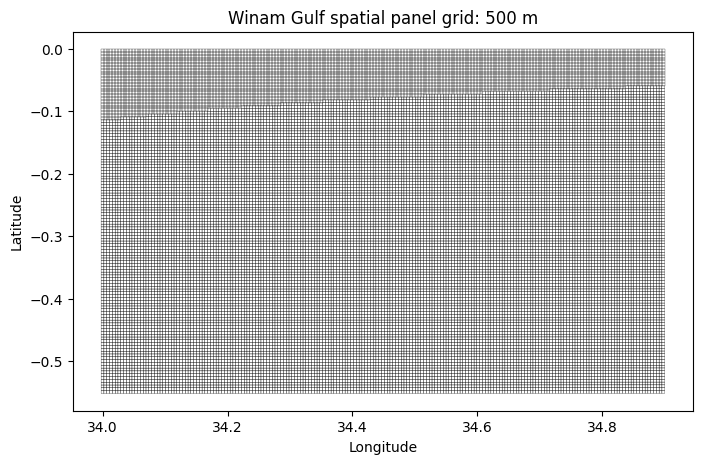

In [15]:
grid = create_grid_from_bbox(AOI_BBOX_WGS84, CELL_SIZE_M, PANEL_CRS)

print(f"Created {len(grid):,} grid cells at {CELL_SIZE_M} m resolution.")
display(grid.head())

grid_path_gpkg = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.gpkg"
grid_path_geojson = OUTPUT_DIR / f"winam_grid_{CELL_SIZE_M}m.geojson"

grid.to_file(grid_path_gpkg, layer="grid", driver="GPKG")
grid.to_crs("EPSG:4326").to_file(grid_path_geojson, driver="GeoJSON")

print("Saved grid to:")
print(grid_path_gpkg)
print(grid_path_geojson)

ax = grid.to_crs("EPSG:4326").plot(figsize=(8, 6), facecolor="none", edgecolor="black", linewidth=0.2)
ax.set_title(f"Winam Gulf spatial panel grid: {CELL_SIZE_M} m")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 6b. Bathymetry, water mask, and neighbour graph

Samples per-cell **depth** from the Lake Victoria analytical bathymetry raster (also used as the water/littoral mask, since it is clipped to the lake shoreline) and builds the **queen/rook neighbour graph** for the spatial-lag features.

In [ ]:
# ---------------------------------------------------------------------
# Bathymetry covariate, water/littoral mask inputs, and neighbour graph
# ---------------------------------------------------------------------
# Adds three grid-level structures used downstream:
#   - depth_m / bathy_water_fraction : sampled from the Lake Victoria analytical
#     bathymetry raster. Depth is a static habitat covariate; because the raster
#     is clipped to the lake shoreline, the per-cell valid-pixel fraction is also
#     used as the water/littoral mask (Priority 1).
#   - grid_neighbours : queen/rook contiguity edge list for the neighbour
#     spatial-lag features (Priority 3).
# depth_m and bathy_water_fraction are attached to `grid`, so they flow into the
# panel through the existing grid-attribute merge in section 7.

grid_neighbours = None
if NEIGHBOUR_LAG_ENABLED:
    grid_neighbours = build_grid_neighbours(grid, CELL_SIZE_M, contiguity=NEIGHBOUR_CONTIGUITY)
    _deg = grid_neighbours.groupby("grid_id").size()
    print(f"Neighbour graph ({NEIGHBOUR_CONTIGUITY}): {len(grid_neighbours):,} directed edges, "
          f"mean degree {_deg.mean():.2f} over {grid['grid_id'].nunique():,} cells.")
else:
    print("Neighbour spatial-lag features disabled (NEIGHBOUR_LAG_ENABLED = False).")

# Bathymetry sampling (graceful if the raster is missing, so the notebook still runs).
for _col in ("depth_m", "bathy_water_fraction"):
    if _col in grid.columns:
        grid = grid.drop(columns=_col)

if BATHYMETRY_RASTER is not None and Path(BATHYMETRY_RASTER).exists():
    try:
        bathy_cov = sample_bathymetry_to_grid(
            grid, BATHYMETRY_RASTER, PANEL_CRS,
            depth_positive_down=BATHYMETRY_DEPTH_POSITIVE_DOWN,
            resampling=BATHYMETRY_RESAMPLING,
        )
        grid = grid.merge(bathy_cov[["grid_id", "depth_m", "bathy_water_fraction"]],
                          on="grid_id", how="left")
        _have = grid["depth_m"].notna()
        print(f"\nBathymetry sampled for {int(_have.sum()):,}/{len(grid):,} cells "
              f"({100 * _have.mean():.0f}% contain lake pixels).")
        print(f"  depth_m (m):            min {grid.loc[_have,'depth_m'].min():.1f}, "
              f"median {grid.loc[_have,'depth_m'].median():.1f}, "
              f"max {grid.loc[_have,'depth_m'].max():.1f}")
        print(f"  cells >= MIN_WATER_FRACTION ({MIN_WATER_FRACTION:g}): "
              f"{int((grid['bathy_water_fraction'] >= MIN_WATER_FRACTION).sum()):,}")
    except Exception as exc:
        grid["depth_m"] = np.nan
        grid["bathy_water_fraction"] = np.nan
        print(f"\nBathymetry sampling failed ({type(exc).__name__}: {exc}); "
              "depth_m / bathy_water_fraction set to NaN.")
else:
    grid["depth_m"] = np.nan
    grid["bathy_water_fraction"] = np.nan
    print(f"\nNo bathymetry raster found at BATHYMETRY_RASTER={BATHYMETRY_RASTER}.")
    print("Upload Lake_Victoria_Analytical_ras.tif and point BATHYMETRY_RASTER at it to "
          "enable the depth covariate and the bathymetry water mask.")

display(grid[["grid_id", "x_km", "y_km", "depth_m", "bathy_water_fraction"]].head())


## 7. Aggregate classifier-output WH rasters to the grid

This is the main preprocessing step.

For every selected classifier GeoTIFF, the notebook calculates, for each grid cell:

- valid classified pixel count;
- WH / floating-plant pixel count using `WH_CLASS_VALUES`;
- valid classified area;
- WH area;
- WH proportional cover.

The result is a `grid_id × month` panel with source classifier metadata retained for auditability.


In [16]:
panel_parts = []
metadata_cols = ["sensor", "product", "start_date", "end_date", "source_run_log"]

for row in tqdm(tif_index.itertuples(index=False), total=len(tif_index)):
    df = aggregate_one_raster_to_grid(
        tif_path=row.path,
        month=row.month,
        grid_gdf=grid,
        panel_crs=PANEL_CRS,
        wh_class_values=WH_CLASS_VALUES,
        extra_nodata_values=EXTRA_NODATA_VALUES,
        valid_class_values=VALID_CLASS_VALUES,
    )
    if len(df) > 0:
        proba_path = getattr(row, "proba_path", None)
        if (USE_PROBABILITY_RESPONSE and proba_path is not None
                and not (isinstance(proba_path, float) and pd.isna(proba_path))
                and str(proba_path).strip() not in ("", "None", "nan")
                and Path(str(proba_path)).exists()):
            try:
                soft = aggregate_one_proba_raster_to_grid(
                    class_path=row.path,
                    proba_path=str(proba_path),
                    month=row.month,
                    grid_gdf=grid,
                    panel_crs=PANEL_CRS,
                    wh_class_values=WH_CLASS_VALUES,
                    extra_nodata_values=EXTRA_NODATA_VALUES,
                    valid_class_values=VALID_CLASS_VALUES,
                    proba_nodata_value=PROBA_NODATA_VALUE,
                    proba_scale=PROBA_SCALE,
                )
                if len(soft) > 0:
                    df = df.merge(soft, on="grid_id", how="left")
            except Exception as exc:
                print(f"  proba aggregation skipped for {Path(row.path).name}: "
                      f"{type(exc).__name__}: {exc}")
        row_dict = row._asdict()
        for col in metadata_cols:
            if col in row_dict:
                df[f"source_{col}"] = row_dict[col]
        panel_parts.append(df)

if len(panel_parts) == 0:
    raise RuntimeError("No panel rows were created. Check raster CRS, AOI, class codes and no-data settings.")

panel_raw = pd.concat(panel_parts, ignore_index=True)

print(f"Raw panel rows before duplicate-month handling: {len(panel_raw):,}")
display(panel_raw.head())


  0%|          | 0/223 [00:00<?, ?it/s]

Raw panel rows before duplicate-month handling: 2,166,252


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log
0,0,2020-11-01,713,0,71300.0,0.0,0.0,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02,2020-11-03,/content/drive/MyDrive/Winam_RF_Training_Data/...
1,1,2020-11-01,1084,0,108400.0,0.0,0.0,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02,2020-11-03,/content/drive/MyDrive/Winam_RF_Training_Data/...
2,2,2020-11-01,456,0,45600.0,0.0,0.0,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02,2020-11-03,/content/drive/MyDrive/Winam_RF_Training_Data/...
3,3,2020-11-01,4,0,400.0,0.0,0.0,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02,2020-11-03,/content/drive/MyDrive/Winam_RF_Training_Data/...
4,5,2020-11-01,524,0,52400.0,0.0,0.0,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02,2020-11-03,/content/drive/MyDrive/Winam_RF_Training_Data/...


### Combine duplicate observations within the same month

If the classifier output has only one selected raster per month, this step will not change much.

If there are multiple selected snapshots in the same month, the default behaviour is to take the **mean** grid-cell WH cover/area across those rasters. You can change this to `max` in the configuration cell.


In [17]:
if DUPLICATE_MONTH_METHOD not in {"mean", "max"}:
    raise ValueError("DUPLICATE_MONTH_METHOD must be either 'mean' or 'max'.")

source_agg = lambda x: "; ".join(sorted(set(map(str, x.dropna()))))
source_metadata_cols = [c for c in panel_raw.columns if c.startswith("source_")]

if DUPLICATE_MONTH_METHOD == "mean":
    agg_funcs = {
        "valid_pixels": "mean",
        "wh_pixels": "mean",
        "valid_area_m2": "mean",
        "wh_area_m2": "mean",
        "wh_cover": "mean",
        "source_file": source_agg,
    }
elif DUPLICATE_MONTH_METHOD == "max":
    agg_funcs = {
        "valid_pixels": "max",
        "wh_pixels": "max",
        "valid_area_m2": "max",
        "wh_area_m2": "max",
        "wh_cover": "max",
        "source_file": source_agg,
    }

for col in source_metadata_cols:
    agg_funcs[col] = source_agg

# Carry the confidence-weighted response columns through the monthly aggregation.
for _soft_col in ["wh_cover_soft", "wh_conf_mean"]:
    if _soft_col in panel_raw.columns:
        agg_funcs[_soft_col] = "mean"

panel = (
    panel_raw
    .groupby(["grid_id", "month"], as_index=False)
    .agg(agg_funcs)
)

# Retain only minimally valid cell-months.
panel = panel[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()

# Merge grid attributes.
grid_attrs = grid.drop(columns="geometry").copy()
panel = panel.merge(grid_attrs, on="grid_id", how="left")

# Basic response variables.
panel["wh_area_ha"] = panel["wh_area_m2"] / 10_000
panel["valid_area_ha"] = panel["valid_area_m2"] / 10_000
# Fractional valid coverage of the nominal cell area (1.0 == fully observed).
# Used by the optional habitat / valid-cell filter before modelling.
panel["valid_fraction"] = (panel["valid_area_m2"] / (CELL_SIZE_M ** 2)).clip(upper=1.0)

# --- Optional confidence-weighted (probabilistic) response (Priority 2) ------
# Keep hard-class cover/area for reference, then -- if enabled and available --
# swap the modelling response to the confidence-weighted cover and recompute the
# observed area from it so downstream area comparisons stay internally consistent.
panel["wh_cover_hard"] = panel["wh_cover"]
panel["wh_area_ha_hard"] = panel["wh_area_ha"]
if USE_PROBABILITY_RESPONSE and "wh_cover_soft" in panel.columns and panel["wh_cover_soft"].notna().any():
    panel["wh_cover"] = panel["wh_cover_soft"].where(panel["wh_cover_soft"].notna(),
                                                     panel["wh_cover_hard"])
    panel["wh_area_m2"] = panel["wh_cover"] * panel["valid_area_m2"]
    panel["wh_area_ha"] = panel["wh_area_m2"] / 10_000
    print("Response: CONFIDENCE-WEIGHTED WH cover (USE_PROBABILITY_RESPONSE=True); "
          "hard-class cover retained as wh_cover_hard.")
else:
    print("Response: HARD-CLASS WH cover (probability rasters unavailable or disabled).")

# --- WH presence definition --------------------------------------------------
# Previously: panel["wh_present"] = panel["wh_area_m2"] > 0  (any non-zero pixel).
# Now configurable: an area threshold (ha) takes precedence if set, otherwise a
# fractional-cover threshold. See PRESENCE_*_THRESHOLD in the configuration cell.
if PRESENCE_AREA_HA_THRESHOLD is not None:
    panel["wh_present"] = panel["wh_area_ha"] >= PRESENCE_AREA_HA_THRESHOLD
    presence_definition = f"wh_area_ha >= {PRESENCE_AREA_HA_THRESHOLD} ha"
else:
    panel["wh_present"] = panel["wh_cover"] >= PRESENCE_COVER_THRESHOLD
    presence_definition = f"wh_cover >= {PRESENCE_COVER_THRESHOLD:g} (fractional cover)"

print(f"Panel rows after duplicate-month handling and validity filtering: {len(panel):,}")
print(f"Months: {panel['month'].nunique()}")
print(f"Grid cells represented: {panel['grid_id'].nunique()}")

# WH-present prevalence under the chosen definition.
print(f"\nWH presence defined as: {presence_definition}")
print(f"Overall WH-present prevalence: {panel['wh_present'].mean():.4f} "
      f"({int(panel['wh_present'].sum()):,} of {len(panel):,} cell-months)")
print("\nWH-present prevalence by month:")
prevalence_by_month = (
    panel.groupby("month")["wh_present"].agg(["mean", "sum", "size"])
    .rename(columns={"mean": "present_rate", "sum": "n_present", "size": "n_cells"})
)
display(prevalence_by_month)

display(panel.head())


Panel rows after duplicate-month handling and validity filtering: 614,196
Months: 58
Grid cells represented: 10828

WH presence defined as: wh_cover >= 0.02 (fractional cover)
Overall WH-present prevalence: 0.1688 (103,664 of 614,196 cell-months)

WH-present prevalence by month:


,present_rate,n_present,n_cells
month,,,
2020-11-01,0.148692,1609,10821
2020-12-01,0.094847,1027,10828
2021-01-01,0.286625,3103,10826
2021-02-01,0.164311,1779,10827
2021-03-01,0.116479,1261,10826
2021-04-01,0.082579,894,10826
2021-05-01,0.286797,3104,10823
2021-06-01,0.192535,2084,10824
2021-07-01,0.136141,1474,10827


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log,x_km,y_km,cell_area_m2,wh_area_ha,valid_area_ha,valid_fraction,wh_present
0,0,2020-11-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02; 2020-11-12; 2020-11-22; 2020-11-27,2020-11-03; 2020-11-13; 2020-11-23; 2020-11-28,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False
1,0,2020-12-01,712.0,0.000000,71200.0,0.000000,0.00000,winam_s2_predictors_2020-12-02_to_2020-12-03_l...,S2,model,2020-12-02; 2020-12-12; 2020-12-22; 2020-12-27,2020-12-03; 2020-12-13; 2020-12-23; 2020-12-28,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.12,0.2848,False
2,0,2021-01-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-01-21_to_2021-01-22_l...,S2,model,2021-01-21; 2021-01-26; 2021-01-31,2021-01-22; 2021-01-27; 2021-02-01,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False
3,0,2021-02-01,713.0,5.333333,71300.0,533.333333,0.00748,winam_s2_predictors_2021-02-10_to_2021-02-11_l...,S2,model,2021-02-10; 2021-02-15; 2021-02-25,2021-02-11; 2021-02-16; 2021-02-26,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.053333,7.13,0.2852,False
4,0,2021-03-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-03-02_to_2021-03-03_l...,S2,model,2021-03-02; 2021-03-07; 2021-03-12,2021-03-03; 2021-03-08; 2021-03-13,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False


### Sensitivity of the WH-present definition to the chosen threshold

The response variable depends strongly on how "present" is defined. The table
below shows how the number of positive cell-months, the positive rate, the mean
WH signal among positives, and the number of months with at least one positive
cell change as the fractional-cover presence threshold is varied. Threshold `0`
reproduces the original "any non-zero WH pixel" definition.


In [18]:
presence_threshold_grid = [0, 0.001, 0.005, 0.01, 0.02, 0.05]

sensitivity_rows = []
for thr in presence_threshold_grid:
    # thr == 0 reproduces the original "any non-zero WH" definition.
    present = panel["wh_cover"] > 0 if thr == 0 else panel["wh_cover"] >= thr
    n_pos = int(present.sum())
    sensitivity_rows.append({
        "cover_threshold": thr,
        "n_positive_cell_months": n_pos,
        "pct_positive": round(100 * present.mean(), 3),
        "mean_cover_among_pos": round(panel.loc[present, "wh_cover"].mean(), 4) if n_pos else np.nan,
        "mean_area_ha_among_pos": round(panel.loc[present, "wh_area_ha"].mean(), 4) if n_pos else np.nan,
        "n_months_with_positive": int(panel.loc[present, "month"].nunique()),
    })

presence_sensitivity = pd.DataFrame(sensitivity_rows)
print("Sensitivity of WH-present prevalence to the cover threshold:")
display(presence_sensitivity)


Sensitivity of WH-present prevalence to the cover threshold:


,cover_threshold,n_positive_cell_months,pct_positive,mean_cover_among_pos,mean_area_ha_among_pos,n_months_with_positive
0,0.000,182498,29.713,0.1163,1.0008,58
1,0.001,158343,25.781,0.1340,1.1521,58
2,0.005,133002,21.655,0.1591,1.3626,58
3,0.010,119421,19.443,0.1763,1.5035,58
4,0.020,103664,16.878,0.2009,1.6965,58
5,0.050,80540,13.113,0.2491,2.0447,58


## Classifier accuracy and response measurement error

The response is a classifier output, so its accuracy and per-cell confidence are reported here rather than assumed perfect (Priority 2).

In [ ]:
# ---------------------------------------------------------------------
# Classifier accuracy and response measurement-error (Priority 2)
# ---------------------------------------------------------------------
# The panel response is itself a classifier output, so its error should be
# surfaced rather than treated as ground truth. This cell (a) reports any
# cross-validation accuracy metrics the classifier notebook logged, and (b)
# summarises the per-cell classification confidence and the hard-vs-soft cover
# agreement, which quantify the measurement error entering the response.

# (a) Classifier CV accuracy metrics, if the classifier notebook saved a table.
_metric_tables = []
try:
    for _patt in ("*model_selection*metrics*.csv", "*metrics*.csv", "*cv*metrics*.csv",
                  "*_metrics_*.csv"):
        _metric_tables += list(Path(CLASSIFIER_TABLE_DIR).glob(_patt))
except Exception:
    pass
_metric_tables = sorted(set(_metric_tables), key=lambda p: p.stat().st_mtime if p.exists() else 0)
if _metric_tables:
    _mt = _metric_tables[-1]
    print(f"Classifier accuracy metrics from: {_mt.name}")
    try:
        _mdf = pd.read_csv(_mt)
        _show = [c for c in ["sensor", "model", "method", "accuracy", "balanced_accuracy",
                             "kappa", "macro_f1", "weighted_f1"] if c in _mdf.columns]
        display(_mdf[_show] if _show else _mdf.head())
    except Exception as exc:
        print("  could not read metrics table:", exc)
else:
    print("No classifier CV-metrics CSV found in CLASSIFIER_TABLE_DIR.")
    print("  (Look for the model-selection metrics exported by "
          "Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb; accuracy/kappa/macro-F1 "
          "should be quoted alongside these panel results.)")

# (b) Response confidence + hard-vs-soft agreement, from the panel.
if "wh_conf_mean" in panel.columns and panel["wh_conf_mean"].notna().any():
    _c = panel["wh_conf_mean"].dropna()
    print(f"\nPer-cell WH classification confidence (winning-class P over WH pixels), "
          f"n={len(_c):,}:")
    display(_c.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3))
    _low = (_c < 0.6).mean()
    print(f"Share of WH-bearing cell-months with mean confidence < 0.60: {_low:.1%} "
          "(these contribute most of the response measurement error).")
else:
    print("\nNo per-cell confidence available (probability rasters not aggregated).")

if {"wh_cover_hard", "wh_cover_soft"}.issubset(panel.columns) and panel["wh_cover_soft"].notna().any():
    _m = panel[["wh_cover_hard", "wh_cover_soft"]].dropna()
    if len(_m) > 2:
        _corr = _m["wh_cover_hard"].corr(_m["wh_cover_soft"])
        _bias = (_m["wh_cover_soft"] - _m["wh_cover_hard"]).mean()
        print(f"\nHard vs confidence-weighted cover: r={_corr:.3f}, "
              f"mean(soft - hard)={_bias:+.4f} "
              f"(soft is typically slightly lower, having down-weighted low-confidence WH pixels).")
        _ha = panel["valid_area_m2"]
        _area_hard = float((panel["wh_cover_hard"] * _ha / 1e4).sum())
        _area_soft = float((panel["wh_cover_soft"].fillna(panel["wh_cover_hard"]) * _ha / 1e4).sum())
        print(f"Panel-total WH area: hard={_area_hard:,.0f} ha, "
              f"confidence-weighted={_area_soft:,.0f} ha "
              f"({_area_soft / _area_hard:.0%} of hard).")
        print(f"Modelling response in use: "
              f"{'confidence-weighted (soft)' if USE_PROBABILITY_RESPONSE else 'hard-class'} cover.")
else:
    print("\nConfidence-weighted cover not available; the response uses hard-class cover.")


## 8. Earth Engine environmental covariate extraction

This step pulls the environmental driver layers that have usable Google Earth Engine assets and reduces them onto the panel. It runs when `USE_EARTH_ENGINE = True` (configured in section 3) and is wrapped in a `try/except` so the notebook still completes if Earth Engine is unavailable.

Three tables are produced:

| Output | Keyed by | Layers |
| --- | --- | --- |
| `ee_monthly_cov` | `month` | Rainfall (CHIRPS, monthly + antecedent sums), wind (ERA5 u/v, speed, direction, bay-axis components), air temperature (ERA5), water-surface temperature (MODIS LST), optional MODIS ocean-colour chlorophyll-a (off by default) |
| `ee_cellmonth_cov` | `grid_id`, `month` | Sentinel-2 **turbidity** (NDTI + red reflectance) proxy; **Sentinel-3 OLCI chlorophyll-a** (mg/m³) via MCI and MPH band-difference algorithms calibrated per Kravitz et al. (2020); all water-masked |
| `ee_static_cov` | `grid_id` | Distance to rivers (HydroSHEDS), distance to shore and openness (JRC GSW), catchment pressure (ESA WorldCover fractions, WorldPop population, GHSL built-up) |

**Resolution strategy.** Reanalysis/coarse climate layers (CHIRPS ~5 km, ERA5 ~28 km, MODIS ~1–4 km) are extracted as **AOI-mean monthly series**, so they enter as month-level covariates. Sentinel-2 water-quality proxies (~20 m) are extracted **per grid cell and month**, because they carry real within-gulf spatial signal. Static layers are extracted **once per cell**.

**Sentinel-3 OLCI chlorophyll-a.** GEE's OLCI asset provides only TOA radiances (no geometry/meteorology tie-points), so the best atmospheric corrections in Kravitz et al. (2020) — BRR and 6SV1 — cannot be reproduced inside GEE. Their key result is that the **MCI and MPH band-difference algorithms are robust to atmospheric correction**, and they publish TOA-reflectance calibrations (Table B.1). The notebook therefore computes OLCI TOA reflectance (nominal solar irradiance + analytically reconstructed solar zenith) and retrieves chl-a with **MCI** (their best TOA method, R²=0.53) and **MPH** (best overall, R²=0.55; its BRR calibration is applied to TOA reflectance as a documented approximation). For publication-grade chl-a, process BRR/6SV externally (SNAP / Py6S) and ingest via the CSV hook in section 9.

**Layers that need a CSV instead (no standard EE asset):** lake level (DAHITI / Hydroweb / G-REALM altimetry), ENSO/IOD indices, bathymetry/depth, and in-situ nutrients (TN, TP, DIN, SRP). Supply these through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV` in section 9.

**Caching to Drive.** Earth Engine extraction is the slow step here, so the covariate tables are cached. The first successful run writes them to `EE_CACHE_DIR` (defaults to `OUTPUT_DIR`) alongside a small JSON manifest, and every later run reloads them from Drive instead of querying Earth Engine — so the per-cell reductions only run once per configuration. The cache is keyed by a fingerprint of the settings that change the covariates (cell size, AOI, test period, the panel's month set and the `EE_*` parameters), so it rebuilds automatically when any of those change. Set `EE_FORCE_REFRESH = True` (or delete the `ee_*_covariates_*` files) to force a fresh pull, or `USE_EE_CACHE = False` to bypass the cache entirely.

> The first run on a fresh Colab runtime triggers `ee.Authenticate()`. Per-cell reductions scale with the number of grid cells, so prefer `CELL_SIZE_M = 1000` for Earth Engine test runs, or turn off `waterquality_s2`/`waterquality_s3` in `EE_LAYERS` for the quickest pass.

In [19]:
# Initialise the EE covariate containers so later cells work even when
# USE_EARTH_ENGINE is False or extraction fails.
ee_monthly_cov = None
ee_cellmonth_cov = None
ee_static_cov = None
ee_registry = {"monthly": [], "cellmonth": [], "static": []}

# ---------------------------------------------------------------------
# Drive cache helpers for the Earth Engine covariates
# ---------------------------------------------------------------------
# Earth Engine extraction is the slow step in this notebook. The covariate
# tables are written to EE_CACHE_DIR after the first successful run and reloaded
# on later runs (see USE_EE_CACHE / EE_FORCE_REFRESH in section 3), so the
# per-cell Earth Engine reductions only happen once per configuration. A small
# JSON manifest records which tables exist plus a fingerprint of the settings
# that change the covariates, so the cache is rebuilt automatically when any of
# those settings change.
import hashlib
import json

_EE_CACHE_TAG = f"{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}"
EE_CACHE_PATHS = {
    "monthly":   Path(EE_CACHE_DIR) / f"ee_monthly_covariates_{_EE_CACHE_TAG}.csv",
    "cellmonth": Path(EE_CACHE_DIR) / f"ee_cellmonth_covariates_{_EE_CACHE_TAG}.csv",
    "static":    Path(EE_CACHE_DIR) / f"ee_static_covariates_{_EE_CACHE_TAG}.csv",
}
EE_CACHE_MANIFEST = Path(EE_CACHE_DIR) / f"ee_covariates_cache_manifest_{_EE_CACHE_TAG}.json"


def _ee_cache_signature(months):
    """Fingerprint the configuration that determines the EE covariate values."""
    payload = {
        "cell_size_m": CELL_SIZE_M,
        "panel_crs": PANEL_CRS,
        "aoi_bbox_wgs84": list(AOI_BBOX_WGS84),
        "n_grid_cells": int(grid["grid_id"].nunique()),
        "months": [str(pd.Timestamp(m).date()) for m in months],
        "ee_layers": {k: bool(v) for k, v in EE_LAYERS.items()},
        "ee_s2_products": sorted(EE_S2_PRODUCTS),
        "ee_s3_products": sorted(EE_S3_PRODUCTS),
        "ee_rain_antecedent_days": list(EE_RAIN_ANTECEDENT_DAYS),
        "ee_bay_axis_bearing_deg": EE_BAY_AXIS_BEARING_DEG,
        "ee_water_occurrence_threshold": EE_WATER_OCCURRENCE_THRESHOLD,
        "ee_s2_cloud_pct": EE_S2_CLOUD_PCT,
        "ee_climate_aoi_scale": EE_CLIMATE_AOI_SCALE,
        "ee_catchment_buffer_m": EE_CATCHMENT_BUFFER_M,
        "ee_static_year": EE_STATIC_YEAR,
        "ee_s3_calib": {k: list(v) for k, v in EE_S3_CALIB.items()},
    }
    blob = json.dumps(payload, sort_keys=True, default=str)
    return hashlib.sha256(blob.encode("utf-8")).hexdigest()


def _registry_from_tables(monthly_df, cellmonth_df, static_df):
    """Rebuild the covariate-group registry from cached table columns."""
    return {
        "monthly":   [] if monthly_df is None else [c for c in monthly_df.columns if c != "month"],
        "cellmonth": [] if cellmonth_df is None else [c for c in cellmonth_df.columns if c not in ("grid_id", "month")],
        "static":    [] if static_df is None else [c for c in static_df.columns if c != "grid_id"],
    }


def _read_cached_table(path):
    df = pd.read_csv(path)
    if "month" in df.columns:
        df["month"] = pd.to_datetime(df["month"]).dt.to_period("M").dt.to_timestamp()
    return df


def save_ee_cache(monthly_df, cellmonth_df, static_df, registry, signature):
    """Write the EE covariate tables and a manifest to EE_CACHE_DIR."""
    Path(EE_CACHE_DIR).mkdir(parents=True, exist_ok=True)
    written = {}
    for key, table in (("monthly", monthly_df),
                       ("cellmonth", cellmonth_df),
                       ("static", static_df)):
        path = EE_CACHE_PATHS[key]
        if table is not None and len(table) > 0:
            table.to_csv(path, index=False)
            written[key] = path.name
        elif path.exists():
            path.unlink()  # drop a stale table that no longer applies
    manifest = {
        "signature": signature,
        "tag": _EE_CACHE_TAG,
        "registry": registry,
        "tables": written,
        "created_utc": pd.Timestamp.now(tz="UTC").isoformat(),
    }
    EE_CACHE_MANIFEST.write_text(json.dumps(manifest, indent=2))
    return written


def load_ee_cache(signature):
    """Return (monthly, cellmonth, static, registry) from the cache, or None.

    None means there is no usable cache (no manifest, the configuration changed,
    or a listed file is missing), so the caller re-queries Earth Engine.
    """
    if not EE_CACHE_MANIFEST.exists():
        return None
    try:
        manifest = json.loads(EE_CACHE_MANIFEST.read_text())
    except (ValueError, OSError):
        return None
    if manifest.get("signature") != signature:
        print("Cached Earth Engine covariates are stale (configuration changed); rebuilding.")
        return None
    tables = manifest.get("tables", {})
    loaded = {"monthly": None, "cellmonth": None, "static": None}
    for key in loaded:
        if key in tables:
            path = EE_CACHE_PATHS[key]
            if not path.exists():
                print(f"Cache manifest lists {path.name} but the file is missing; rebuilding.")
                return None
            loaded[key] = _read_cached_table(path)
    registry = manifest.get("registry") or _registry_from_tables(
        loaded["monthly"], loaded["cellmonth"], loaded["static"])
    return loaded["monthly"], loaded["cellmonth"], loaded["static"], registry


if USE_EARTH_ENGINE:
    panel_months = sorted(panel["month"].unique())
    ee_cache_signature = _ee_cache_signature(panel_months)

    cached = load_ee_cache(ee_cache_signature) if (USE_EE_CACHE and not EE_FORCE_REFRESH) else None

    if cached is not None:
        ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry = cached
        print(f"Loaded Earth Engine covariates from the Drive cache in {EE_CACHE_DIR}.")
        print("Earth Engine was not queried. Set EE_FORCE_REFRESH = True (or delete the "
              "ee_*_covariates_* files) to rebuild from Earth Engine.")
        for label, table in (("Monthly climate", ee_monthly_cov),
                             ("Per-cell/month water-quality", ee_cellmonth_cov),
                             ("Static per-cell", ee_static_cov)):
            if table is not None:
                print(f"\n{label} covariates: {table.shape}")
                display(table.head())
    else:
        print(f"Requesting Earth Engine covariates for {len(panel_months)} month(s) "
              f"and {grid['grid_id'].nunique():,} grid cells.")
        if CELL_SIZE_M < 1000:
            print("Note: per-cell Earth Engine reductions scale with cell count. "
                  "If requests are slow or time out, use CELL_SIZE_M = 1000, lower "
                  "EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.")
        try:
            ee_monthly_cov, ee_cellmonth_cov, ee_static_cov, ee_registry = extract_ee_covariates(
                grid, panel_months
            )
            print("\nEarth Engine covariate extraction complete.")
            if USE_EE_CACHE:
                written = save_ee_cache(ee_monthly_cov, ee_cellmonth_cov, ee_static_cov,
                                        ee_registry, ee_cache_signature)
                kinds = ", ".join(written) if written else "no tables"
                print(f"Cached Earth Engine covariates to {EE_CACHE_DIR} ({kinds}); "
                      "later runs reload them instead of re-querying Earth Engine.")
            if ee_monthly_cov is not None:
                print(f"\nMonthly climate covariates: {ee_monthly_cov.shape}")
                display(ee_monthly_cov.head())
            if ee_cellmonth_cov is not None:
                print(f"\nPer-cell/month water-quality covariates: {ee_cellmonth_cov.shape}")
                display(ee_cellmonth_cov.head())
            if ee_static_cov is not None:
                print(f"\nStatic per-cell covariates: {ee_static_cov.shape}")
                display(ee_static_cov.head())
        except Exception as exc:
            print("Earth Engine covariate extraction failed; continuing without EE covariates.")
            print(f"Reason: {type(exc).__name__}: {exc}")
            print("Check ee.Authenticate()/EE_PROJECT, your internet connection, or disable "
                  "individual layers in EE_LAYERS, then re-run this cell.")
            ee_monthly_cov = ee_cellmonth_cov = ee_static_cov = None
            ee_registry = {"monthly": [], "cellmonth": [], "static": []}
else:
    print("USE_EARTH_ENGINE is False. Skipping Earth Engine extraction.")
    print("The notebook will use only the optional CSV covariates (if provided) in section 9.")

Requesting Earth Engine covariates for 58 month(s) and 24,522 grid cells.
Note: per-cell Earth Engine reductions scale with cell count. If requests are slow or time out, use CELL_SIZE_M = 1000, lower EE_MAX_CELLS_PER_REQUEST, or disable the Sentinel-2/3 layers.
Earth Engine initialised on project: ee-bmillwardsadler1
Extracting AOI-mean monthly climate covariates (CHIRPS / ERA5 / MODIS) ...
  monthly climate columns: ['air_temp_c', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'water_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms']
Extracting Sentinel-2 water-quality proxies per cell and month ...


S2 NDCI/NDTI:   0%|          | 0/58 [00:00<?, ?it/s]

Extracting Sentinel-3 OLCI chl-a (MCI/MPH; Kravitz et al. 2020) per cell and month ...


S3 chl-a:   0%|          | 0/58 [00:00<?, ?it/s]

  per-cell/month columns: ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3']
Extracting static distance/openness covariates per cell ...
Extracting catchment-pressure covariates per cell (WorldCover / WorldPop / GHSL) ...
  static columns: ['dist_river_m', 'dist_shore_m', 'openness_index', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Earth Engine covariate extraction complete.
Cached Earth Engine covariates to /content/drive/MyDrive/WH_spatial_panel_test (monthly, cellmonth, static); later runs reload them instead of re-querying Earth Engine.

Monthly climate covariates: (58, 12)


,air_temp_c,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,water_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,month,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms
0,22.309304,407.824985,779.102231,407.824985,25.669684,1.819611,0.327597,0.191992,2020-11-01,59.627038,0.327597,-0.191992
1,22.814784,86.771123,700.799876,88.654500,25.594623,1.958240,0.502575,0.626934,2020-12-01,38.717053,0.502575,-0.626934
2,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,2021-01-01,27.963809,0.334201,-0.629500
3,23.638283,91.869614,261.786441,91.441365,25.078659,2.236033,0.361000,0.443403,2021-02-01,39.151018,0.361000,-0.443403
4,23.962942,110.344206,283.616746,110.484806,26.130017,2.208792,0.549439,0.465422,2021-03-01,49.732536,0.549439,-0.465422



Per-cell/month water-quality covariates: (1422276, 6)


,grid_id,red_reflectance_s2,turb_ndti_s2,month,chl_mci_s3,chl_mph_s3
0,0,0.01175,-0.334277,2020-11-01,18.295328,6.365894
1,0,0.01445,-0.292636,2020-12-01,18.618538,6.621357
2,0,0.01630,-0.257015,2021-01-01,19.803437,6.815337
3,0,0.02040,-0.221501,2021-02-01,23.995393,7.293303
4,0,0.02320,-0.202736,2021-03-01,18.611918,5.978393



Static per-cell covariates: (24522, 9)


,grid_id,dist_river_m,dist_shore_m,openness_index,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count
0,0,3793.678025,5859.103448,98.196150,0.0,0.0,0.0,0.0,0.0
1,1,3403.025457,5455.402397,98.180733,0.0,0.0,0.0,0.0,0.0
2,2,2907.817495,4955.964765,97.966694,0.0,0.0,0.0,0.0,0.0
3,3,2406.151524,4450.013955,96.671707,0.0,0.0,0.0,0.0,0.0
4,4,1902.289913,3941.848739,94.577738,0.0,0.0,0.0,0.0,0.0


## 9. Merge covariates (Earth Engine + optional CSVs)

This is where the environmental-driver variables enter the panel. The classified GeoTIFFs alone produce the WH response variable, but they cannot explain environmental controls unless these covariates are merged in.

Three things are merged here:

1. **Earth Engine covariates** from section 8 (`ee_monthly_cov` on `month`, `ee_static_cov` on `grid_id`, `ee_cellmonth_cov` on `grid_id` + `month`).
2. **Optional monthly CSV** (`ENV_MONTHLY_CSV`) for month-level drivers without an EE asset — lake level, ENSO/IOD, in-situ nutrients.
3. **Optional spatial CSV** (`SPATIAL_COVARIATES_CSV`) for static per-cell drivers without an EE asset — bathymetry/depth, manually derived fetch/shelter.

The merge also builds three column registries used by the feature-engineering step:

- `MONTHLY_COVARIATE_COLS` and `CELLMONTH_COVARIATE_COLS` — **time-varying**, so they receive one-month lags;
- `STATIC_COVARIATE_COLS` — **time-invariant**, so they are used directly without lags.

CSV columns that duplicate an Earth Engine column are dropped (the CSV is only for drivers EE cannot supply), so providing a CSV never silently overwrites an EE covariate.

In [20]:
# Track covariate groups so feature engineering can lag the time-varying
# covariates but treat static spatial covariates as time-invariant.
MONTHLY_COVARIATE_COLS = []
CELLMONTH_COVARIATE_COLS = []
STATIC_COVARIATE_COLS = []


def _merge_and_record(panel_df, cov_df, on, group_cols):
    """Left-merge a covariate table into the panel and record its new columns."""
    if cov_df is None or len(cov_df) == 0:
        return panel_df
    cov_df = cov_df.copy()
    on_cols = [on] if isinstance(on, str) else list(on)
    if "month" in on_cols and "month" in cov_df.columns:
        cov_df["month"] = pd.to_datetime(cov_df["month"]).dt.to_period("M").dt.to_timestamp()
    new_cols = [c for c in cov_df.columns if c not in on_cols]
    overlap = [c for c in new_cols if c in panel_df.columns]
    if overlap:
        print("  dropping covariate columns already present in the panel:", overlap)
        cov_df = cov_df.drop(columns=overlap)
        new_cols = [c for c in new_cols if c not in overlap]
    panel_df = panel_df.merge(cov_df, on=on_cols, how="left")
    for c in new_cols:
        if c not in group_cols:
            group_cols.append(c)
    return panel_df


# 1) Earth Engine covariates (from section 8).
print("Merging Earth Engine covariates ...")
panel = _merge_and_record(panel, ee_monthly_cov, "month", MONTHLY_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_static_cov, "grid_id", STATIC_COVARIATE_COLS)
panel = _merge_and_record(panel, ee_cellmonth_cov, ["grid_id", "month"], CELLMONTH_COVARIATE_COLS)

# 2) Optional monthly covariates CSV (lake level, ENSO/IOD, nutrients, ...).
if ENV_MONTHLY_CSV is not None:
    env = load_monthly_covariates(ENV_MONTHLY_CSV)
    print("Loaded monthly environmental covariates from CSV:")
    display(env.head())
    panel = _merge_and_record(panel, env, "month", MONTHLY_COVARIATE_COLS)
else:
    print("No ENV_MONTHLY_CSV supplied (use it for lake level, ENSO/IOD, nutrients, etc.).")

# 3) Optional static spatial covariates CSV (bathymetry/depth, fetch, ...).
if SPATIAL_COVARIATES_CSV is not None:
    spatial_cov = pd.read_csv(SPATIAL_COVARIATES_CSV)
    if "grid_id" not in spatial_cov.columns:
        raise ValueError("SPATIAL_COVARIATES_CSV must contain a 'grid_id' column.")
    print("Loaded spatial covariates from CSV:")
    display(spatial_cov.head())
    panel = _merge_and_record(panel, spatial_cov, "grid_id", STATIC_COVARIATE_COLS)
else:
    print("No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).")

if not (MONTHLY_COVARIATE_COLS or CELLMONTH_COVARIATE_COLS or STATIC_COVARIATE_COLS):
    print("\nNo environmental covariates were merged.")
    print("The test model will use seasonality, grid coordinates and lagged WH cover only.")

print("\nCovariate groups assembled:")
print("  Monthly (time-varying):       ", MONTHLY_COVARIATE_COLS)
print("  Per-cell/month (time-varying):", CELLMONTH_COVARIATE_COLS)
print("  Static (time-invariant):      ", STATIC_COVARIATE_COLS)
print(f"\nPanel now has {panel.shape[0]:,} rows and {panel.shape[1]} columns.")
display(panel.head())

Merging Earth Engine covariates ...
No ENV_MONTHLY_CSV supplied (use it for lake level, ENSO/IOD, nutrients, etc.).
No SPATIAL_COVARIATES_CSV supplied (use it for bathymetry/depth, fetch, etc.).

Covariate groups assembled:
  Monthly (time-varying):        ['air_temp_c', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'water_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms']
  Per-cell/month (time-varying): ['red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3']
  Static (time-invariant):       ['dist_river_m', 'dist_shore_m', 'openness_index', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']

Panel now has 614,196 rows and 43 columns.


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log,x_km,y_km,cell_area_m2,wh_area_ha,valid_area_ha,valid_fraction,wh_present,air_temp_c,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,water_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,dist_river_m,dist_shore_m,openness_index,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3
0,0,2020-11-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02; 2020-11-12; 2020-11-22; 2020-11-27,2020-11-03; 2020-11-13; 2020-11-23; 2020-11-28,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False,22.309304,407.824985,779.102231,407.824985,25.669684,1.819611,0.327597,0.191992,59.627038,0.327597,-0.191992,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.01175,-0.334277,18.295328,6.365894
1,0,2020-12-01,712.0,0.000000,71200.0,0.000000,0.00000,winam_s2_predictors_2020-12-02_to_2020-12-03_l...,S2,model,2020-12-02; 2020-12-12; 2020-12-22; 2020-12-27,2020-12-03; 2020-12-13; 2020-12-23; 2020-12-28,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.12,0.2848,False,22.814784,86.771123,700.799876,88.654500,25.594623,1.958240,0.502575,0.626934,38.717053,0.502575,-0.626934,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.01445,-0.292636,18.618538,6.621357
2,0,2021-01-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-01-21_to_2021-01-22_l...,S2,model,2021-01-21; 2021-01-26; 2021-01-31,2021-01-22; 2021-01-27; 2021-02-01,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,27.963809,0.334201,-0.629500,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.01630,-0.257015,19.803437,6.815337
3,0,2021-02-01,713.0,5.333333,71300.0,533.333333,0.00748,winam_s2_predictors_2021-02-10_to_2021-02-11_l...,S2,model,2021-02-10; 2021-02-15; 2021-02-25,2021-02-11; 2021-02-16; 2021-02-26,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.053333,7.13,0.2852,False,23.638283,91.869614,261.786441,91.441365,25.078659,2.236033,0.361000,0.443403,39.151018,0.361000,-0.443403,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.02040,-0.221501,23.995393,7.293303
4,0,2021-03-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-03-02_to_2021-03-03_l...,S2,model,2021-03-02; 2021-03-07; 2021-03-12,2021-03-03; 2021-03-08; 2021-03-13,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False,23.962942,110.344206,283.616746,110.484806,26.130017,2.208792,0.549439,0.465422,49.732536,0.549439,-0.465422,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.02320,-0.202736,18.611918,5.978393


## 10. Feature engineering

This creates:

- cyclic seasonal terms;
- linear time index;
- lagged WH cover and presence per grid cell;
- one-month lags for the **time-varying** environmental covariates (monthly climate + per-cell/month water quality + any monthly CSV).

Static spatial covariates (distances, land-cover fractions, population, built-up) are time-invariant, so they are kept as-is and not lagged.

Lagging helps because WH extent in a given month may respond to antecedent rainfall, wind, temperature or water-quality conditions, rather than only same-month conditions.

In [21]:
panel = panel.sort_values(["grid_id", "month"]).reset_index(drop=True)

# Seasonal and time terms.
panel["month_num"] = panel["month"].dt.month
panel["month_sin"] = np.sin(2 * np.pi * panel["month_num"] / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month_num"] / 12)

month_min = panel["month"].min()
panel["time_index"] = (
    (panel["month"].dt.year - month_min.year) * 12
    + (panel["month"].dt.month - month_min.month)
)

# Lagged WH terms by spatial unit.
panel["wh_cover_lag1"] = panel.groupby("grid_id")["wh_cover"].shift(1)
panel["wh_present_lag1"] = panel.groupby("grid_id")["wh_present"].shift(1).astype("float")

# Neighbour spatial-lag terms (Priority 3): previous month's mean cover/presence
# in adjacent cells (queen/rook contiguity). Already lagged -- not re-lagged.
if NEIGHBOUR_LAG_ENABLED and "grid_neighbours" in globals() and grid_neighbours is not None and len(grid_neighbours):
    panel = add_neighbour_lag(panel, grid_neighbours, value_cols=["wh_cover", "wh_present"])
    neighbour_lag_cols = [c for c in ["wh_cover_neigh_lag1", "wh_present_neigh_lag1"]
                          if c in panel.columns]
    print(f"Neighbour spatial-lag features added: {neighbour_lag_cols}")
else:
    neighbour_lag_cols = []
    print("Neighbour spatial-lag features disabled or no neighbour graph available.")

# Time-varying environmental covariates (monthly climate + per-cell/month water
# quality + any monthly CSV) receive one-month lags. Static spatial covariates do not.
time_varying_cols = [
    c for c in (MONTHLY_COVARIATE_COLS + CELLMONTH_COVARIATE_COLS)
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
]
# gsw_water_fraction is a water/littoral mask used by the habitat filter, not an
# ecological driver, so it is kept out of the model feature set.
_mask_only_static = {"gsw_water_fraction"}
static_cols = [
    c for c in STATIC_COVARIATE_COLS
    if c in panel.columns and pd.api.types.is_numeric_dtype(panel[c])
    and c not in _mask_only_static
]

for col in time_varying_cols:
    panel[f"{col}_lag1"] = panel.groupby("grid_id")[col].shift(1)

# Backwards-compatible alias for the original variable name.
env_candidate_cols = time_varying_cols

print(f"Time-varying covariates lagged ({len(time_varying_cols)}):")
print(time_varying_cols)
print(f"\nStatic spatial covariates ({len(static_cols)}):")
print(static_cols)

display(panel.head())

Time-varying covariates lagged (15):
['air_temp_c', 'rain_chirps_30d_mm', 'rain_chirps_90d_mm', 'rain_chirps_mm', 'water_temp_c', 'wind_speed_ms', 'wind_u_ms', 'wind_v_ms', 'wind_dir_to_deg', 'wind_axis_comp_ms', 'wind_cross_comp_ms', 'red_reflectance_s2', 'turb_ndti_s2', 'chl_mci_s3', 'chl_mph_s3']

Static spatial covariates (8):
['dist_river_m', 'dist_shore_m', 'openness_index', 'frac_cropland', 'frac_urban', 'frac_wetland', 'ghsl_built_m2', 'pop_count']


,grid_id,month,valid_pixels,wh_pixels,valid_area_m2,wh_area_m2,wh_cover,source_file,source_sensor,source_product,source_start_date,source_end_date,source_source_run_log,x_km,y_km,cell_area_m2,wh_area_ha,valid_area_ha,valid_fraction,wh_present,air_temp_c,rain_chirps_30d_mm,rain_chirps_90d_mm,rain_chirps_mm,water_temp_c,wind_speed_ms,wind_u_ms,wind_v_ms,wind_dir_to_deg,wind_axis_comp_ms,wind_cross_comp_ms,dist_river_m,dist_shore_m,openness_index,frac_cropland,frac_urban,frac_wetland,ghsl_built_m2,pop_count,red_reflectance_s2,turb_ndti_s2,chl_mci_s3,chl_mph_s3,month_num,month_sin,month_cos,time_index,wh_cover_lag1,wh_present_lag1,air_temp_c_lag1,rain_chirps_30d_mm_lag1,rain_chirps_90d_mm_lag1,rain_chirps_mm_lag1,water_temp_c_lag1,wind_speed_ms_lag1,wind_u_ms_lag1,wind_v_ms_lag1,wind_dir_to_deg_lag1,wind_axis_comp_ms_lag1,wind_cross_comp_ms_lag1,red_reflectance_s2_lag1,turb_ndti_s2_lag1,chl_mci_s3_lag1,chl_mph_s3_lag1
0,0,2020-11-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2020-11-02_to_2020-11-03_l...,S2,model,2020-11-02; 2020-11-12; 2020-11-22; 2020-11-27,2020-11-03; 2020-11-13; 2020-11-23; 2020-11-28,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False,22.309304,407.824985,779.102231,407.824985,25.669684,1.819611,0.327597,0.191992,59.627038,0.327597,-0.191992,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.01175,-0.334277,18.295328,6.365894,11,-5.000000e-01,8.660254e-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2020-12-01,712.0,0.000000,71200.0,0.000000,0.00000,winam_s2_predictors_2020-12-02_to_2020-12-03_l...,S2,model,2020-12-02; 2020-12-12; 2020-12-22; 2020-12-27,2020-12-03; 2020-12-13; 2020-12-23; 2020-12-28,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.12,0.2848,False,22.814784,86.771123,700.799876,88.654500,25.594623,1.958240,0.502575,0.626934,38.717053,0.502575,-0.626934,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.01445,-0.292636,18.618538,6.621357,12,-2.449294e-16,1.000000e+00,1,0.00000,0.0,22.309304,407.824985,779.102231,407.824985,25.669684,1.819611,0.327597,0.191992,59.627038,0.327597,-0.191992,0.01175,-0.334277,18.295328,6.365894
2,0,2021-01-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-01-21_to_2021-01-22_l...,S2,model,2021-01-21; 2021-01-26; 2021-01-31,2021-01-22; 2021-01-27; 2021-02-01,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,27.963809,0.334201,-0.629500,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.01630,-0.257015,19.803437,6.815337,1,5.000000e-01,8.660254e-01,2,0.00000,0.0,22.814784,86.771123,700.799876,88.654500,25.594623,1.958240,0.502575,0.626934,38.717053,0.502575,-0.626934,0.01445,-0.292636,18.618538,6.621357
3,0,2021-02-01,713.0,5.333333,71300.0,533.333333,0.00748,winam_s2_predictors_2021-02-10_to_2021-02-11_l...,S2,model,2021-02-10; 2021-02-15; 2021-02-25,2021-02-11; 2021-02-16; 2021-02-26,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.053333,7.13,0.2852,False,23.638283,91.869614,261.786441,91.441365,25.078659,2.236033,0.361000,0.443403,39.151018,0.361000,-0.443403,3793.678025,5859.103448,98.19615,0.0,0.0,0.0,0.0,0.0,0.02040,-0.221501,23.995393,7.293303,2,8.660254e-01,5.000000e-01,3,0.00000,0.0,22.859020,70.589691,572.920448,81.690576,24.945336,2.098160,0.334201,0.629500,27.963809,0.334201,-0.629500,0.01630,-0.257015,19.803437,6.815337
4,0,2021-03-01,713.0,0.000000,71300.0,0.000000,0.00000,winam_s2_predictors_2021-03-02_to_2021-03-03_l...,S2,model,2021-03-02; 2021-03-07; 2021-03-12,2021-03-03; 2021-03-08; 2021-03-13,/content/drive/MyDrive/Winam_RF_Training_Data/...,611.25,9939.25,250000.0,0.000000,7.13,0.2852,False,23.962942,110.344206,283.616746,110.484806,26.130017,2.208792,0.549439,0.465422,49.732536,0.549439,-0.465422,3793.678025,5859.103448,98.19615,0.0

## 11. Exploratory checks

Before modelling, check whether WH observations are mostly zero, whether the time series looks plausible, and whether some months have poor coverage.

,month,wh_area_ha,valid_area_ha,mean_cover,occurrence_rate,n_cells
0,2020-11-01,2157.329167,231713.315833,0.022567,0.148692,10821
1,2020-12-01,1331.784167,237247.772667,0.014712,0.094847,10828
2,2021-01-01,5135.445500,228809.474333,0.045623,0.286625,10826
3,2021-02-01,3633.280833,228649.200833,0.032999,0.164311,10827
4,2021-03-01,1623.468333,228727.368333,0.020438,0.116479,10826
5,2021-04-01,869.160833,237336.133333,0.013480,0.082579,10826
6,2021-05-01,2889.857000,221894.922833,0.038415,0.286797,10823
7,2021-06-01,3490.964333,228700.088333,0.033877,0.192535,10824
8,2021-07-01,1743.554167,219626.884167,0.025367,0.136141,10827
9,2021-08-01,4267.785833,217307.056667,0.076023,0.463187,10825


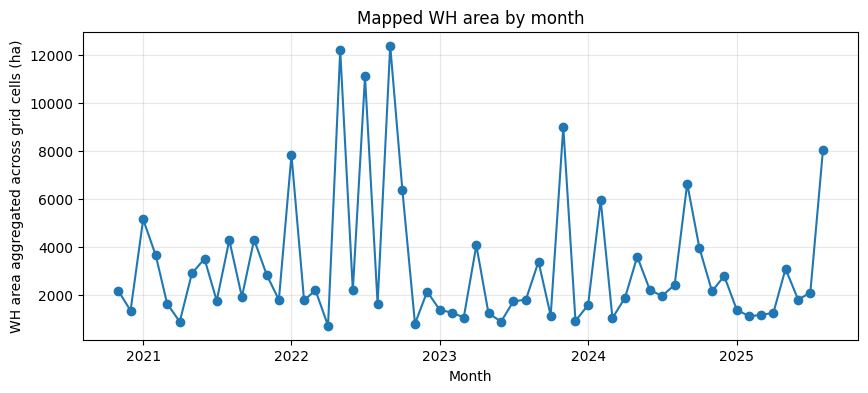

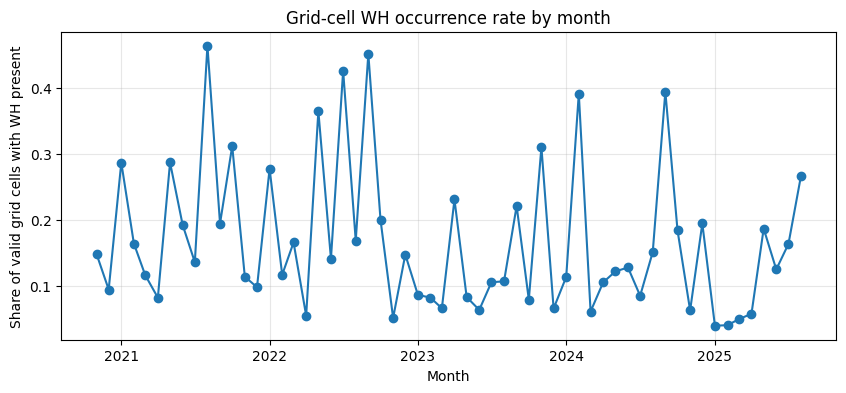

Overall share of cell-months with WH present: 0.1688


In [22]:
monthly_summary = (
    panel.groupby("month", as_index=False)
    .agg(
        wh_area_ha=("wh_area_ha", "sum"),
        valid_area_ha=("valid_area_ha", "sum"),
        mean_cover=("wh_cover", "mean"),
        occurrence_rate=("wh_present", "mean"),
        n_cells=("grid_id", "nunique"),
    )
)

display(monthly_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["wh_area_ha"], marker="o")
ax.set_title("Mapped WH area by month")
ax.set_xlabel("Month")
ax.set_ylabel("WH area aggregated across grid cells (ha)")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_summary["month"], monthly_summary["occurrence_rate"], marker="o")
ax.set_title("Grid-cell WH occurrence rate by month")
ax.set_xlabel("Month")
ax.set_ylabel("Share of valid grid cells with WH present")
ax.grid(True, alpha=0.3)
plt.show()

print("Overall share of cell-months with WH present:", round(panel["wh_present"].mean(), 4))

## Methodological note: presence definition and probability threshold

The previous model used any non-zero WH area to define presence and used a fixed
0.5 probability threshold. This caused the presence model to be highly
conservative: precision was high but recall was very low, so the model missed
most true WH-present cells and underestimated total WH area. The updated workflow
tests a more ecologically meaningful presence threshold and tunes the probability
threshold using validation data.

Concretely, the changes below:

- define presence with a configurable cover/area threshold instead of "any pixel";
- split the existing training period into fitting and validation months and keep
  the original test months untouched;
- tune the presence probability threshold on the validation months (maximising F1
  by default, with a higher-recall option reported);
- form the final predicted WH area as a two-stage hurdle: the positive-cover model
  is applied only to cells predicted present at the tuned threshold, and zero cover
  is assigned to predicted-absent cells.


## Habitat / valid-cell filter

The panel can contain background cells and cell-months with very few valid
pixels, which dilute presence and push the classifier toward always predicting
absence. The filters below are applied conservatively before modelling:

- the existing minimum valid-pixel filter is retained;
- an optional minimum valid-fraction filter (off by default);
- an optional "ever validly observed" cell filter that keeps only cells with at
  least one valid observation across the panel.

No shoreline/littoral mask is invented here. The number of rows and unique cells
removed by each filter is printed.


In [23]:
n_rows_before_filter = len(panel)
n_cells_before_filter = panel["grid_id"].nunique()
print(f"Before habitat/valid-cell filters: {n_rows_before_filter:,} rows, "
      f"{n_cells_before_filter:,} unique cells")

# 1. Minimum valid pixels per cell-month (already applied in section 7).
#    Re-assert here so the filter is explicit and its effect is reported.
before_rows, before_cells = len(panel), panel["grid_id"].nunique()
panel = panel[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH].copy()
print(f"[valid-pixel >= {MIN_VALID_PIXELS_PER_CELL_MONTH}] removed "
      f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")

# 2. Optional minimum valid fraction per cell-month.
if MIN_VALID_FRACTION_PER_CELL_MONTH is not None and "valid_fraction" in panel.columns:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    panel = panel[panel["valid_fraction"] >= MIN_VALID_FRACTION_PER_CELL_MONTH].copy()
    print(f"[valid-fraction >= {MIN_VALID_FRACTION_PER_CELL_MONTH}] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[valid-fraction] filter disabled (MIN_VALID_FRACTION_PER_CELL_MONTH is None)")

# 3. Optional "ever validly observed" cell filter.
#    Conservative: keep cells with at least one valid observation across the panel.
#    With only a classified/no-data validity flag available this is near-universal;
#    it is a scaffold for a stronger habitat mask if an ever-wet indicator is added.
if REQUIRE_EVER_WET_OR_EVER_OBSERVED:
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    ever_valid_cells = (
        panel.loc[panel["valid_pixels"] >= MIN_VALID_PIXELS_PER_CELL_MONTH, "grid_id"].unique()
    )
    panel = panel[panel["grid_id"].isin(ever_valid_cells)].copy()
    print(f"[ever validly observed] removed "
          f"{before_rows - len(panel):,} rows, {before_cells - panel['grid_id'].nunique():,} cells")
else:
    print("[ever validly observed] filter disabled (REQUIRE_EVER_WET_OR_EVER_OBSERVED is False)")

# 4. Water / littoral habitat mask (Priority 1): keep cells that are mostly water.
if WATER_MASK_SOURCE != "none":
    before_rows, before_cells = len(panel), panel["grid_id"].nunique()
    wf = None
    if WATER_MASK_SOURCE in ("bathymetry", "both") and "bathy_water_fraction" in panel.columns:
        wf = panel["bathy_water_fraction"].fillna(0.0)
    if WATER_MASK_SOURCE in ("gsw", "both") and "gsw_water_fraction" in panel.columns:
        g = panel["gsw_water_fraction"].fillna(0.0)
        wf = g if wf is None else (np.minimum(wf, g) if WATER_MASK_SOURCE == "both" else g)
    if wf is None:
        print(f"[water mask] source '{WATER_MASK_SOURCE}' requested but no water-fraction "
              "column is available; skipping (provide bathymetry or a GSW fraction).")
    else:
        panel = panel[wf >= MIN_WATER_FRACTION].copy()
        print(f"[water mask: {WATER_MASK_SOURCE} >= {MIN_WATER_FRACTION:g}] removed "
              f"{before_rows - len(panel):,} rows, "
              f"{before_cells - panel['grid_id'].nunique():,} cells "
              f"(kept {panel['grid_id'].nunique():,} water cells)")
else:
    print("[water mask] disabled (WATER_MASK_SOURCE = 'none')")

print(f"After habitat/valid-cell filters: {len(panel):,} rows, "
      f"{panel['grid_id'].nunique():,} unique cells "
      f"(removed {n_rows_before_filter - len(panel):,} rows, "
      f"{n_cells_before_filter - panel['grid_id'].nunique():,} cells overall)")


Before habitat/valid-cell filters: 614,196 rows, 10,828 unique cells
[valid-pixel >= 10] removed 0 rows, 0 cells
[valid-fraction] filter disabled (MIN_VALID_FRACTION_PER_CELL_MONTH is None)
[ever validly observed] removed 0 rows, 0 cells
After habitat/valid-cell filters: 614,196 rows, 10,828 unique cells (removed 0 rows, 0 cells overall)


## 12. Prepare model dataset

This model is intentionally simple and robust for a test period.

It uses a **temporally blocked train/test split**, rather than a random split, because random splitting would leak information from adjacent months into the test set.

Feature columns now include the Earth Engine and CSV covariates (and their one-month lags for the time-varying ones). Rows are dropped only when the **response** or the **structural lag features** are missing; missing values in the environmental covariates themselves (for example a cloudy Sentinel-2 month, or a cell that is mostly land) are left in place and imputed inside the model pipeline, so adding many covariates does not shrink the panel.

In [24]:
# Candidate model features.
candidate_features = [
    "month_sin",
    "month_cos",
    "time_index",
    "x_km",
    "y_km",
    "wh_cover_lag1",
    "wh_present_lag1",
]

# Time-varying covariates and their one-month lags.
candidate_features += time_varying_cols
candidate_features += [f"{c}_lag1" for c in time_varying_cols if f"{c}_lag1" in panel.columns]

# Static spatial covariates (no lag).
candidate_features += static_cols

# Bathymetry depth (static habitat covariate) and neighbour spatial-lag terms.
candidate_features += [c for c in ["depth_m"] if c in panel.columns]
candidate_features += [c for c in ["wh_cover_neigh_lag1", "wh_present_neigh_lag1"]
                       if c in panel.columns]

feature_cols = clean_feature_columns(panel, candidate_features)

print(f"Model feature columns ({len(feature_cols)}):")
for c in feature_cols:
    print(" -", c)

model_df = panel.dropna(subset=["wh_cover", "wh_present"]).copy()

# Drop rows only when the response or the structural lag features are missing.
# For a very short test period this may remove the first month (lag1 is NaN there).
# Environmental covariates are intentionally NOT in this list: their missing
# values are imputed inside the model pipeline (median imputer), so adding many
# sparse covariates (e.g. cloudy Sentinel-2 months) does not collapse the panel.
structural_required = [
    "wh_cover", "wh_present", "grid_id", "month", "valid_area_m2",
    "wh_cover_lag1", "wh_present_lag1",
]
structural_required = [c for c in structural_required if c in model_df.columns]
model_df = model_df.dropna(subset=structural_required).copy()

if len(model_df) == 0:
    raise RuntimeError("No model rows remain after dropping missing response/lag values.")

months_sorted = np.array(sorted(model_df["month"].unique()))
split_idx = max(1, int(len(months_sorted) * TRAIN_FRACTION))
split_month = months_sorted[split_idx]

train = model_df[model_df["month"] < split_month].copy()
test = model_df[model_df["month"] >= split_month].copy()

# Split the TRAIN period into fitting and validation months. The validation
# months are used only to tune the presence probability threshold; the TEST
# months are never used for tuning and remain unchanged.
train_months = np.array(sorted(train["month"].unique()))
if len(train_months) > 1:
    n_val_months = int(round(len(train_months) * VALIDATION_FRACTION))
    n_val_months = max(1, min(n_val_months, len(train_months) - 1))
else:
    n_val_months = 0

if n_val_months > 0:
    val_months = train_months[-n_val_months:]
    fit_months = train_months[:-n_val_months]
else:
    val_months = np.array([], dtype=train_months.dtype)
    fit_months = train_months

train_fit = train[train["month"].isin(fit_months)].copy()
train_val = train[train["month"].isin(val_months)].copy()

print(
    f"Fitting months:    {pd.Timestamp(fit_months.min()).date()} to {pd.Timestamp(fit_months.max()).date()}"
    if len(fit_months) else "Fitting months:    (none)"
)
print(
    f"Validation months: {pd.Timestamp(val_months.min()).date()} to {pd.Timestamp(val_months.max()).date()}"
    if len(val_months) else "Validation months: (none - threshold tuning falls back to training)"
)
print(f"Testing months:    {test['month'].min().date()} to {test['month'].max().date()}")
print(f"Fit rows: {len(train_fit):,} | Val rows: {len(train_val):,} | "
      f"Train(total) rows: {len(train):,} | Test rows: {len(test):,}")
print(f"Train WH-present rate: {train['wh_present'].mean():.4f}")
print(f"Val   WH-present rate: {train_val['wh_present'].mean():.4f}" if len(train_val) else "Val   WH-present rate: (n/a)")
print(f"Test  WH-present rate: {test['wh_present'].mean():.4f}")

X_train = train[feature_cols]
X_test = test[feature_cols]
X_fit = train_fit[feature_cols]
X_val = train_val[feature_cols]

y_train_presence = train["wh_present"].astype(int)
y_test_presence = test["wh_present"].astype(int)
y_fit_presence = train_fit["wh_present"].astype(int)
y_val_presence = train_val["wh_present"].astype(int)

Model feature columns (45):
 - month_sin
 - month_cos
 - time_index
 - x_km
 - y_km
 - wh_cover_lag1
 - wh_present_lag1
 - air_temp_c
 - rain_chirps_30d_mm
 - rain_chirps_90d_mm
 - rain_chirps_mm
 - water_temp_c
 - wind_speed_ms
 - wind_u_ms
 - wind_v_ms
 - wind_dir_to_deg
 - wind_axis_comp_ms
 - wind_cross_comp_ms
 - red_reflectance_s2
 - turb_ndti_s2
 - chl_mci_s3
 - chl_mph_s3
 - air_temp_c_lag1
 - rain_chirps_30d_mm_lag1
 - rain_chirps_90d_mm_lag1
 - rain_chirps_mm_lag1
 - water_temp_c_lag1
 - wind_speed_ms_lag1
 - wind_u_ms_lag1
 - wind_v_ms_lag1
 - wind_dir_to_deg_lag1
 - wind_axis_comp_ms_lag1
 - wind_cross_comp_ms_lag1
 - red_reflectance_s2_lag1
 - turb_ndti_s2_lag1
 - chl_mci_s3_lag1
 - chl_mph_s3_lag1
 - dist_river_m
 - dist_shore_m
 - openness_index
 - frac_cropland
 - frac_urban
 - frac_wetland
 - ghsl_built_m2
 - pop_count
Fitting months:    2020-12-01 to 2023-07-01
Validation months: 2023-08-01 to 2024-05-01
Testing months:    2024-06-01 to 2025-08-01
Fit rows: 334,941 | 

## 13. Stage 1 model: WH presence/absence

This estimates whether each grid cell contains any mapped WH in each month.

For the final dissertation, you may want to compare this with a GAM, GLMM or Bayesian model. This notebook uses regularised logistic regression because it is fast, transparent and easy to test.

In [25]:
if y_train_presence.nunique() < 2:
    raise RuntimeError(
        "The training set contains only one presence/absence class. "
        "Try a longer test period, larger AOI, different class codes, or coarser grid."
    )


def find_best_threshold(y_true, y_prob, metric="prevalence_match"):
    """Sweep probability thresholds in [0.01, 0.99] and pick the best by ``metric``.

    Supported metrics:
      - "prevalence_match": pick the threshold whose predicted positive rate is
        closest to the observed positive rate of ``y_true``. With calibrated
        probabilities this matches the predicted number of present cells to the
        expected number, which de-biases total predicted WH extent (the dominant
        source of the area over-prediction). Recommended for extent estimation.
      - "f1" / "precision" / "recall": classic operating-point metrics.

    Returns (best, sweep):
      - best:  pandas Series with threshold, precision, recall, f1, pred_pos_rate
      - sweep: DataFrame of those metrics across all thresholds
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    obs_pos_rate = float(y_true.mean())
    thresholds = np.round(np.arange(0.01, 0.991, 0.01), 2)
    rows = []
    for t in thresholds:
        pred = (y_prob >= t).astype(int)
        pred_pos_rate = float(pred.mean())
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "pred_pos_rate": pred_pos_rate,
            "abs_prevalence_gap": abs(pred_pos_rate - obs_pos_rate),
        })
    sweep = pd.DataFrame(rows)
    if metric == "prevalence_match":
        # Smallest gap between predicted and observed positive rate; ties broken
        # toward the higher threshold (fewer false positives).
        best = sweep.sort_values(
            ["abs_prevalence_gap", "threshold"], ascending=[True, False]
        ).iloc[0].copy()
    else:
        score_col = metric if metric in {"f1", "precision", "recall"} else "f1"
        best = sweep.loc[sweep[score_col].idxmax()].copy()
    return best, sweep


def make_base_presence_model():
    """Uncalibrated presence pipeline.

    class_weight="balanced" is intentionally NOT used: balancing inflates the
    predicted probabilities away from the true (~17-20%) WH prevalence and was the
    main driver of the WH-area over-prediction. The raw probabilities are instead
    calibrated below so that their sum reflects the true expected number of
    present cells.
    """
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])


# --- Fit and calibrate the presence model ------------------------------------
# Preferred path: fit the base model on the fitting months, then calibrate the
# probabilities on the held-out validation months (cv="prefit"). Calibrating on
# the most recent pre-test months also partly counters the downward prevalence
# drift into the test period. The presence threshold is then chosen on the same
# calibrated validation probabilities.
use_validation = (
    len(train_val) > 0
    and y_val_presence.nunique() == 2
    and len(train_fit) > 0
    and y_fit_presence.nunique() == 2
)

if use_validation:
    base_fit_model = make_base_presence_model()
    base_fit_model.fit(X_fit, y_fit_presence)
    presence_model = CalibratedClassifierCV(
        base_fit_model, method=PRESENCE_CALIBRATION_METHOD, cv="prefit"
    )
    presence_model.fit(X_val, y_val_presence)
    val_presence_prob = presence_model.predict_proba(X_val)[:, 1]
    best_threshold_row, threshold_sweep = find_best_threshold(
        y_val_presence, val_presence_prob, metric=PRESENCE_THRESHOLD_METRIC
    )
    threshold_source = "validation months (calibrated)"
    threshold_target_rate = float(y_val_presence.mean())
else:
    # Fallback: no usable validation block. Calibrate with internal CV on the
    # full training period and tune the threshold on the training predictions.
    presence_model = CalibratedClassifierCV(
        make_base_presence_model(), method=PRESENCE_CALIBRATION_METHOD, cv=5
    )
    presence_model.fit(X_train, y_train_presence)
    train_presence_prob = presence_model.predict_proba(X_train)[:, 1]
    best_threshold_row, threshold_sweep = find_best_threshold(
        y_train_presence, train_presence_prob, metric=PRESENCE_THRESHOLD_METRIC
    )
    threshold_source = "training predictions (OPTIMISTIC: no usable validation block)"
    threshold_target_rate = float(y_train_presence.mean())

selected_threshold = float(best_threshold_row["threshold"])

# Higher-recall alternative: highest-recall threshold whose precision stays above
# PRESENCE_MIN_PRECISION_FOR_RECALL.
acceptable = threshold_sweep[threshold_sweep["precision"] >= PRESENCE_MIN_PRECISION_FOR_RECALL]
if len(acceptable) > 0:
    high_recall_row = acceptable.sort_values(["recall", "threshold"], ascending=[False, True]).iloc[0]
else:
    high_recall_row = None

# --- Final predictions on the test period ------------------------------------
# The calibrated model is the final predictor (the base is NOT refit on the full
# train, so the validation months stay a genuine calibration hold-out).
test_presence_prob = presence_model.predict_proba(X_test)[:, 1]
test_presence_pred = test_presence_prob >= selected_threshold      # tuned threshold
test_presence_pred_05 = test_presence_prob >= 0.5                  # legacy threshold

# Uncalibrated model refit on the full training period, used only to report
# interpretable standardised logistic-regression coefficients.
coef_model = make_base_presence_model()
coef_model.fit(X_train, y_train_presence)

print(f"Presence model: LogisticRegression (no class balancing) + "
      f"{PRESENCE_CALIBRATION_METHOD} probability calibration")
print(f"Threshold tuned on: {threshold_source}")
print(f"Threshold selection metric: {PRESENCE_THRESHOLD_METRIC}")
print(f"Selected probability threshold: {selected_threshold:.2f}")
print(f"  threshold-set precision={best_threshold_row['precision']:.3f} "
      f"recall={best_threshold_row['recall']:.3f} f1={best_threshold_row['f1']:.3f} "
      f"pred_pos_rate={best_threshold_row['pred_pos_rate']:.3f} "
      f"(target observed rate={threshold_target_rate:.3f})")
if high_recall_row is not None:
    print(f"Higher-recall option (precision >= {PRESENCE_MIN_PRECISION_FOR_RECALL}): "
          f"threshold={high_recall_row['threshold']:.2f} "
          f"precision={high_recall_row['precision']:.3f} "
          f"recall={high_recall_row['recall']:.3f} f1={high_recall_row['f1']:.3f}")
else:
    print(f"No threshold kept precision >= {PRESENCE_MIN_PRECISION_FOR_RECALL}; "
          f"using the {PRESENCE_THRESHOLD_METRIC} threshold only.")

print(f"\nPresence/absence classification report (TEST, tuned threshold = {selected_threshold:.2f}):")
print(classification_report(y_test_presence, test_presence_pred, digits=3))

print("Presence/absence classification report (TEST, legacy threshold = 0.50):")
print(classification_report(y_test_presence, test_presence_pred_05, digits=3))

if y_test_presence.nunique() == 2:
    print("ROC AUC:", round(roc_auc_score(y_test_presence, test_presence_prob), 4))
    print("Average precision (PR AUC):", round(average_precision_score(y_test_presence, test_presence_prob), 4))
    print("Brier score:", round(brier_score_loss(y_test_presence, test_presence_prob), 4))
else:
    print("Test set contains only one class, so ROC AUC and average precision are undefined.")

presence_coef = pd.DataFrame({
    "feature": feature_cols,
    "standardised_logit_coefficient": coef_model.named_steps["model"].coef_[0],
}).sort_values("standardised_logit_coefficient", key=np.abs, ascending=False)

display(presence_coef)


Presence model: LogisticRegression (no class balancing) + isotonic probability calibration
Threshold tuned on: validation months (calibrated)
Threshold selection metric: prevalence_match
Selected probability threshold: 0.15
  threshold-set precision=0.367 recall=0.324 f1=0.344 pred_pos_rate=0.140 (target observed rate=0.158)
Higher-recall option (precision >= 0.5): threshold=0.27 precision=0.505 recall=0.225 f1=0.312

Presence/absence classification report (TEST, tuned threshold = 0.15):
              precision    recall  f1-score   support

           0      0.897     0.939     0.917    137911
           1      0.490     0.353     0.411     22999

    accuracy                          0.855    160910
   macro avg      0.693     0.646     0.664    160910
weighted avg      0.839     0.855     0.845    160910

Presence/absence classification report (TEST, legacy threshold = 0.50):
              precision    recall  f1-score   support

           0      0.873     0.996     0.930    137911

,feature,standardised_logit_coefficient
8,rain_chirps_30d_mm,-2.485803
10,rain_chirps_mm,2.480980
33,red_reflectance_s2_lag1,-0.483026
0,month_sin,0.424542
22,air_temp_c_lag1,-0.417427
43,ghsl_built_m2,0.401333
9,rain_chirps_90d_mm,0.371333
39,openness_index,-0.346188
31,wind_axis_comp_ms_lag1,-0.345835
28,wind_u_ms_lag1,-0.345835


### Presence model diagnostics

Fuller diagnostics for the presence stage: confusion matrix, predicted positive
rates at the legacy (0.5) and tuned thresholds, precision/recall/F1 at the
selected threshold, and the distribution of predicted probabilities for truly
absent vs truly present test cells.


Selected threshold: 0.15 (tuned on validation months (calibrated))
ROC AUC: 0.6855
PR AUC (average precision): 0.3655

Confusion matrix (TEST, tuned threshold); rows=observed, cols=predicted:


,pred_absent,pred_present
obs_absent,129439,8472
obs_present,14869,8130



Observed positive rate (TEST):              0.1429
Predicted positive rate @0.50:              0.0220
Predicted positive rate @0.15 (tuned):       0.1032
TEST precision/recall/F1 @ tuned threshold: 0.490 / 0.353 / 0.411

Predicted-probability quantiles by true class (TEST):


,quantile,prob_true_absent,prob_true_present
0,0.00,0.000000,0.032736
1,0.10,0.101093,0.141989
2,0.25,0.141989,0.141989
3,0.50,0.141989,0.141989
4,0.75,0.141989,0.267666
5,0.90,0.141989,0.604452
6,1.00,1.000000,1.000000


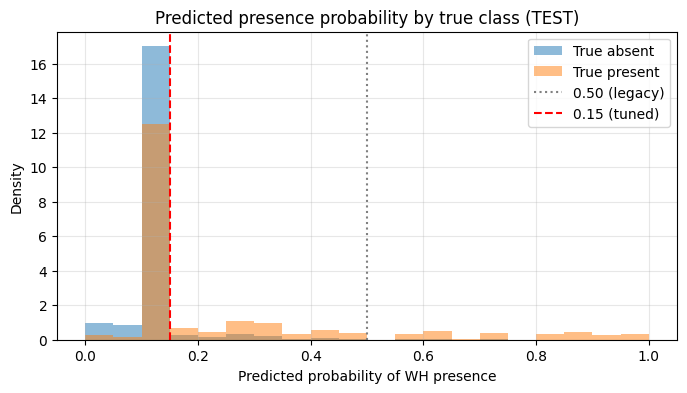

Threshold sweep (validation/optimistic), every 5th row:


,threshold,precision,recall,f1,pred_pos_rate,abs_prevalence_gap
0,0.01,0.158293,1.000000,0.273321,0.999991,0.841699
1,0.06,0.175586,0.971679,0.297425,0.875973,0.717682
2,0.11,0.179266,0.950408,0.301637,0.839207,0.680916
3,0.16,0.380642,0.315647,0.345111,0.131263,0.027028
4,0.21,0.407305,0.295493,0.342505,0.114838,0.043454
5,0.26,0.464925,0.248840,0.324173,0.084721,0.073570
6,0.31,0.506294,0.224514,0.311080,0.070194,0.088098
7,0.36,0.587565,0.178800,0.274169,0.048169,0.110122
8,0.41,0.636385,0.156002,0.250578,0.038803,0.119488
9,0.46,0.688539,0.136259,0.227498,0.031325,0.126966


In [26]:
print("Selected threshold:", round(selected_threshold, 2), f"(tuned on {threshold_source})")

if y_test_presence.nunique() == 2:
    print("ROC AUC:", round(roc_auc_score(y_test_presence, test_presence_prob), 4))
    print("PR AUC (average precision):", round(average_precision_score(y_test_presence, test_presence_prob), 4))
else:
    print("ROC AUC / PR AUC: undefined (single class in test).")

print("\nConfusion matrix (TEST, tuned threshold); rows=observed, cols=predicted:")
cm = confusion_matrix(y_test_presence, test_presence_pred, labels=[0, 1])
display(pd.DataFrame(cm, index=["obs_absent", "obs_present"],
                     columns=["pred_absent", "pred_present"]))

obs_pos_rate = float(y_test_presence.mean())
pred_pos_rate_05 = float(np.mean(test_presence_pred_05))
pred_pos_rate_tuned = float(np.mean(test_presence_pred))
prec_t = precision_score(y_test_presence, test_presence_pred, zero_division=0)
rec_t = recall_score(y_test_presence, test_presence_pred, zero_division=0)
f1_t = f1_score(y_test_presence, test_presence_pred, zero_division=0)

print(f"\nObserved positive rate (TEST):              {obs_pos_rate:.4f}")
print(f"Predicted positive rate @0.50:              {pred_pos_rate_05:.4f}")
print(f"Predicted positive rate @{selected_threshold:.2f} (tuned):       {pred_pos_rate_tuned:.4f}")
print(f"TEST precision/recall/F1 @ tuned threshold: {prec_t:.3f} / {rec_t:.3f} / {f1_t:.3f}")

# Distribution of predicted probabilities by true class.
prob_absent = test_presence_prob[y_test_presence.values == 0]
prob_present = test_presence_prob[y_test_presence.values == 1]

quantiles = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
prob_quantile_table = pd.DataFrame({
    "quantile": quantiles,
    "prob_true_absent": [np.quantile(prob_absent, q) if len(prob_absent) else np.nan for q in quantiles],
    "prob_true_present": [np.quantile(prob_present, q) if len(prob_present) else np.nan for q in quantiles],
})
print("\nPredicted-probability quantiles by true class (TEST):")
display(prob_quantile_table)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 21)
if len(prob_absent):
    ax.hist(prob_absent, bins=bins, alpha=0.5, density=True, label="True absent")
if len(prob_present):
    ax.hist(prob_present, bins=bins, alpha=0.5, density=True, label="True present")
ax.axvline(0.5, color="grey", linestyle=":", label="0.50 (legacy)")
ax.axvline(selected_threshold, color="red", linestyle="--", label=f"{selected_threshold:.2f} (tuned)")
ax.set_title("Predicted presence probability by true class (TEST)")
ax.set_xlabel("Predicted probability of WH presence")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Threshold sweep (validation/optimistic), every 5th row:")
display(threshold_sweep.iloc[::5].reset_index(drop=True))


### Presence model: Boyce index and residual spatial autocorrelation

Prevalence-robust ranking (Boyce) plus a Moran's I check on the predictive model's TEST residuals (Priorities 3 and 4).

In [ ]:
# ---------------------------------------------------------------------
# Presence model: Boyce index + residual spatial autocorrelation (Priority 3, 4)
# ---------------------------------------------------------------------
# Two structure-aware checks on the predictive presence model, both on the
# untouched TEST period:
#   - Boyce index (Hirzel et al. 2006): a prevalence-robust ranking score that
#     complements ROC/PR AUC (Lobo et al. 2008 show AUC alone can mislead).
#   - Moran's I on per-cell mean TEST residuals: is spatial structure left in the
#     residuals that the plain x_km/y_km terms do not absorb? Significant residual
#     autocorrelation motivates the neighbour spatial-lag term and an explicit
#     spatial effect (Dormann et al. 2007).

if y_test_presence.nunique() == 2:
    _boyce = boyce_index(y_test_presence.values, test_presence_prob, n_bins=BOYCE_N_BINS)
    print(f"Boyce index (TEST): {_boyce:.3f}   "
          "(+1 = presences ranked above absences; ~0 = random)")
else:
    print("Boyce index: undefined (single presence class in TEST).")

# Residual spatial autocorrelation on the predictive presence model.
try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    _HAVE_PYSAL = True
except Exception as _exc:
    _HAVE_PYSAL = False
    print("libpysal/esda not available for residual Moran's I (pip install libpysal esda):",
          repr(_exc))

if _HAVE_PYSAL:
    _res = test[["grid_id", "x_km", "y_km"]].copy()
    _res["resid"] = y_test_presence.values - test_presence_prob      # observed - predicted prob
    _agg = _res.groupby("grid_id", as_index=False).agg(
        x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
    if len(_agg) >= 10:
        _w = KNN.from_array(_agg[["x_km", "y_km"]].values, k=min(8, len(_agg) - 1))
        _w.transform = "r"
        _mi = Moran(_agg["resid"].values, _w, permutations=999)
        print(f"\nPresence residuals: Moran's I = {_mi.I:.4f} (p = {_mi.p_sim:.4f}) "
              f"over {len(_agg):,} cells.")
        if _mi.p_sim < 0.05:
            print("  -> residual spatial autocorrelation remains: the neighbour spatial-lag "
                  "term and/or an explicit spatial effect are warranted.")
        else:
            print("  -> no significant residual spatial autocorrelation in the predictive model.")
    else:
        print("Too few test cells for a residual Moran's I.")


## 14. Stage 2 model: WH cover where present

This estimates proportional WH cover for cell-months where WH is present.

The response is logit-transformed WH cover. Predictions are converted back to proportional cover.

In [27]:
def logit_clip(x, eps=1e-5):
    x = np.clip(np.asarray(x, dtype=float), eps, 1 - eps)
    return np.log(x / (1 - x))


def inv_logit(z):
    return 1 / (1 + np.exp(-z))


positive_train = train[train["wh_present"]].copy()
positive_test = test[test["wh_present"]].copy()

if len(positive_train) < 10:
    raise RuntimeError(
        "Too few positive WH training rows for the cover model. "
        "Try a longer period, larger AOI, coarser grid, or check WH_CLASS_VALUES."
    )

X_train_cover = positive_train[feature_cols]
y_train_cover = logit_clip(positive_train["wh_cover"])

cover_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

# Optionally weight the cover regression by per-cell classification confidence
# (Priority 2): high-confidence WH observations carry more weight in the fit.
cover_fit_kwargs = {}
if WEIGHT_COVER_BY_CONFIDENCE and "wh_conf_mean" in positive_train.columns \
        and positive_train["wh_conf_mean"].notna().any():
    w = positive_train["wh_conf_mean"].fillna(positive_train["wh_conf_mean"].median()).clip(0.01, 1.0)
    cover_fit_kwargs["model__sample_weight"] = w.values
    print(f"Stage-2 cover model weighted by classification confidence "
          f"(mean weight {w.mean():.3f}).")

cover_model.fit(X_train_cover, y_train_cover, **cover_fit_kwargs)

# Conditional cover predictions for all test rows.
test_cover_logit_pred = cover_model.predict(X_test)
test_cover_conditional_pred = inv_logit(test_cover_logit_pred)

# Evaluate only where WH was truly present.
if len(positive_test) > 0:
    X_pos_test = positive_test[feature_cols]
    pos_pred = inv_logit(cover_model.predict(X_pos_test))

    rmse = np.sqrt(mean_squared_error(positive_test["wh_cover"], pos_pred))
    mae = mean_absolute_error(positive_test["wh_cover"], pos_pred)

    print("Positive-cover model performance, evaluated only where WH is observed present:")
    print("RMSE:", round(rmse, 4))
    print("MAE: ", round(mae, 4))
else:
    print("No positive WH rows in test set, so positive-cover performance is undefined.")

cover_coef = pd.DataFrame({
    "feature": feature_cols,
    "standardised_cover_coefficient": cover_model.named_steps["model"].coef_,
}).sort_values("standardised_cover_coefficient", key=np.abs, ascending=False)

display(cover_coef)

Positive-cover model performance, evaluated only where WH is observed present:
RMSE: 0.1538
MAE:  0.1024


,feature,standardised_cover_coefficient
5,wh_cover_lag1,1.373082
8,rain_chirps_30d_mm,-0.800009
10,rain_chirps_mm,0.769309
25,rain_chirps_mm_lag1,0.668999
23,rain_chirps_30d_mm_lag1,-0.639507
33,red_reflectance_s2_lag1,-0.589105
6,wh_present_lag1,-0.483418
18,red_reflectance_s2,0.474183
0,month_sin,0.295676
34,turb_ndti_s2_lag1,0.171416


## 15. Combined expected-cover predictions

The two stages are combined as:

`expected WH cover = probability of WH presence × conditional WH cover`

This is useful for estimating expected WH area in each grid cell and month.

,grid_id,month,valid_area_m2,wh_area_m2,wh_area_ha,wh_cover,wh_present,pred_presence_prob,pred_cover_if_present,pred_expected_cover,pred_wh_area_ha_expected,pred_present_05,pred_present_tuned,pred_wh_area_ha_hurdle_05,pred_wh_area_ha_hurdle_tuned,pred_wh_area_ha
42,0,2024-06-01,71300.0,0.0,0.0,0.0,False,0.141989,0.102587,0.014566,0.103857,0,0,0.0,0.0,0.0
43,0,2024-07-01,71300.0,0.0,0.0,0.0,False,0.141989,0.074306,0.010551,0.075226,0,0,0.0,0.0,0.0
44,0,2024-08-01,69650.0,0.0,0.0,0.0,False,0.141989,0.130720,0.018561,0.129276,0,0,0.0,0.0,0.0
45,0,2024-09-01,71300.0,0.0,0.0,0.0,False,0.141989,0.111161,0.015784,0.112537,0,0,0.0,0.0,0.0
46,0,2024-10-01,58175.0,0.0,0.0,0.0,False,0.141989,0.127380,0.018087,0.105219,0,0,0.0,0.0,0.0


,month,observed_wh_area_ha,predicted_wh_area_ha,predicted_wh_area_ha_expected,observed_mean_cover
0,2024-06-01,2197.480000,557.785354,3599.331159,0.022854
1,2024-07-01,1943.897333,694.740963,2373.123715,0.019984
2,2024-08-01,2406.504000,5468.606844,5711.475383,0.026182
3,2024-09-01,6623.791000,3063.933891,4142.515416,0.063334
4,2024-10-01,3943.900000,5458.721064,6104.074202,0.036956
5,2024-11-01,2138.570000,1163.669482,3179.693830,0.021256
6,2024-12-01,2776.158333,6069.621218,7253.780334,0.031790
7,2025-01-01,1365.640000,2218.080572,4329.531512,0.017004
8,2025-02-01,1095.256000,1285.268952,3128.413939,0.017436
9,2025-03-01,1156.816667,1144.235281,5672.163801,0.018304


Test-period WH area (ha): observed = 41,844.5
  reported (hurdle @ 0.15 threshold): 42,316.4  (101% of observed)
  reference expected-cover sum (biased high): 66,822.9  (160% of observed)


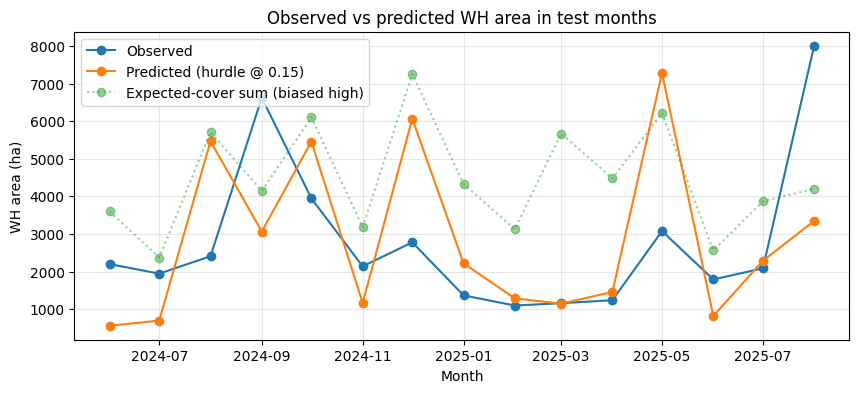

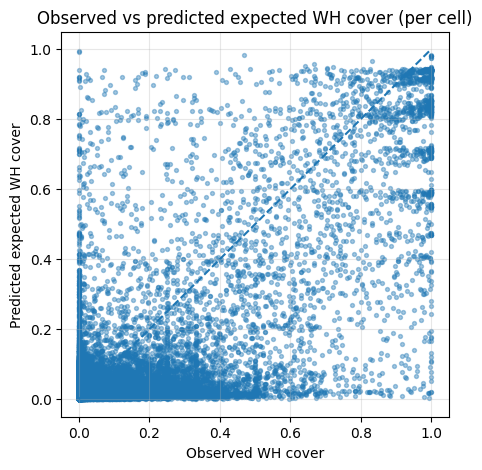

In [28]:
test_preds = test[[
    "grid_id", "month", "valid_area_m2", "wh_area_m2", "wh_area_ha",
    "wh_cover", "wh_present"
]].copy()

test_preds["pred_presence_prob"] = test_presence_prob
test_preds["pred_cover_if_present"] = test_cover_conditional_pred

# Soft "expected cover" = P(present) * E(cover | present). This is a valid
# per-cell expectation, but summing it over every cell (including the many truly
# absent cells, each carrying a small non-zero probability) systematically
# OVER-states total WH area. It is therefore kept for reference only; the
# reported area uses the hurdle estimator below.
test_preds["pred_expected_cover"] = (
    test_preds["pred_presence_prob"] * test_preds["pred_cover_if_present"]
)
test_preds["pred_wh_area_ha_expected"] = (
    test_preds["pred_expected_cover"] * test_preds["valid_area_m2"] / 10_000
)

# --- Two-stage hurdle predictions (used for the reported area) ---------------
# Apply the conditional cover model only where presence is predicted at the given
# threshold, and assign zero cover to predicted-absent cells.
test_preds["pred_present_05"] = (test_preds["pred_presence_prob"] >= 0.5).astype(int)
test_preds["pred_present_tuned"] = (test_preds["pred_presence_prob"] >= selected_threshold).astype(int)

test_preds["pred_wh_area_ha_hurdle_05"] = np.where(
    test_preds["pred_present_05"] == 1,
    test_preds["pred_cover_if_present"] * test_preds["valid_area_m2"] / 10_000,
    0.0,
)
test_preds["pred_wh_area_ha_hurdle_tuned"] = np.where(
    test_preds["pred_present_tuned"] == 1,
    test_preds["pred_cover_if_present"] * test_preds["valid_area_m2"] / 10_000,
    0.0,
)

# Primary reported WH-area prediction = hurdle at the tuned threshold.
test_preds["pred_wh_area_ha"] = test_preds["pred_wh_area_ha_hurdle_tuned"]

display(test_preds.head())

monthly_pred_summary = (
    test_preds.groupby("month", as_index=False)
    .agg(
        observed_wh_area_ha=("wh_area_ha", "sum"),
        predicted_wh_area_ha=("pred_wh_area_ha_hurdle_tuned", "sum"),
        predicted_wh_area_ha_expected=("pred_wh_area_ha_expected", "sum"),
        observed_mean_cover=("wh_cover", "mean"),
    )
)

display(monthly_pred_summary)

# Test-period totals: reported hurdle estimate vs the biased expected-cover sum.
obs_total = monthly_pred_summary["observed_wh_area_ha"].sum()
hurdle_total = monthly_pred_summary["predicted_wh_area_ha"].sum()
soft_total = monthly_pred_summary["predicted_wh_area_ha_expected"].sum()
print(f"Test-period WH area (ha): observed = {obs_total:,.1f}")
if obs_total > 0:
    print(f"  reported (hurdle @ {selected_threshold:.2f} threshold): "
          f"{hurdle_total:,.1f}  ({hurdle_total / obs_total:.0%} of observed)")
    print(f"  reference expected-cover sum (biased high): "
          f"{soft_total:,.1f}  ({soft_total / obs_total:.0%} of observed)")
else:
    print(f"  reported (hurdle): {hurdle_total:,.1f} | expected-cover sum: {soft_total:,.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_pred_summary["month"], monthly_pred_summary["observed_wh_area_ha"],
        marker="o", label="Observed")
ax.plot(monthly_pred_summary["month"], monthly_pred_summary["predicted_wh_area_ha"],
        marker="o", label=f"Predicted (hurdle @ {selected_threshold:.2f})")
ax.plot(monthly_pred_summary["month"], monthly_pred_summary["predicted_wh_area_ha_expected"],
        marker="o", linestyle=":", alpha=0.5, label="Expected-cover sum (biased high)")
ax.set_title("Observed vs predicted WH area in test months")
ax.set_xlabel("Month")
ax.set_ylabel("WH area (ha)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(test_preds["wh_cover"], test_preds["pred_expected_cover"], s=8, alpha=0.4)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Observed vs predicted expected WH cover (per cell)")
ax.set_xlabel("Observed WH cover")
ax.set_ylabel("Predicted expected WH cover")
ax.grid(True, alpha=0.3)
plt.show()


### Test-month area comparison: legacy 0.5 vs tuned threshold

Observed WH area per test month compared with the hurdle prediction using the
legacy 0.5 threshold and the tuned threshold, with absolute and percentage
errors. This shows whether threshold tuning reduces the severe under-prediction
in the later test months.


Test-month WH area: observed vs hurdle predictions (0.5 vs tuned threshold)


,month,observed_wh_area_ha,pred_area_ha_05,pred_area_ha_tuned,abs_err_05_ha,pct_err_05,abs_err_tuned_ha,pct_err_tuned
0,2024-06-01,2197.48,117.99,557.79,2079.49,-94.6,1639.69,-74.6
1,2024-07-01,1943.90,288.68,694.74,1655.21,-85.1,1249.16,-64.3
2,2024-08-01,2406.50,1201.22,5468.61,1205.29,-50.1,3062.10,127.2
3,2024-09-01,6623.79,894.39,3063.93,5729.40,-86.5,3559.86,-53.7
4,2024-10-01,3943.90,1315.60,5458.72,2628.30,-66.6,1514.82,38.4
5,2024-11-01,2138.57,400.93,1163.67,1737.64,-81.3,974.90,-45.6
6,2024-12-01,2776.16,1944.72,6069.62,831.44,-29.9,3293.46,118.6
7,2025-01-01,1365.64,1021.71,2218.08,343.93,-25.2,852.44,62.4
8,2025-02-01,1095.26,713.91,1285.27,381.34,-34.8,190.01,17.3
9,2025-03-01,1156.82,441.65,1144.24,715.17,-61.8,12.58,-1.1


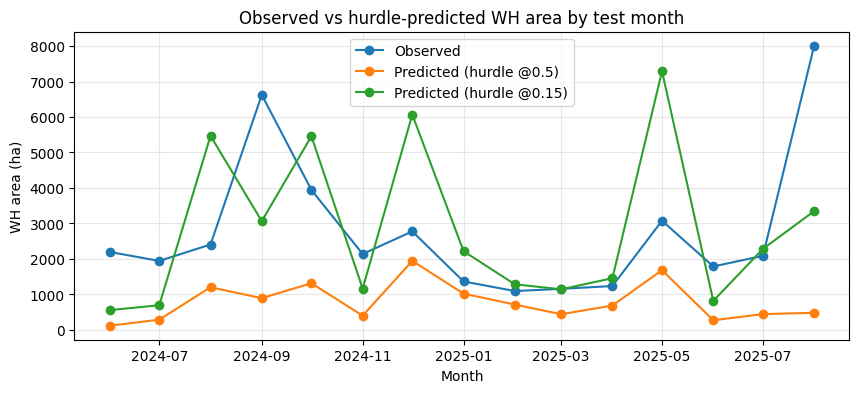

Test-period totals (ha): observed=41844.5, hurdle@0.5=11910.2, hurdle@tuned=42316.4


In [29]:
area_compare = (
    test_preds.groupby("month", as_index=False)
    .agg(
        observed_wh_area_ha=("wh_area_ha", "sum"),
        pred_area_ha_05=("pred_wh_area_ha_hurdle_05", "sum"),
        pred_area_ha_tuned=("pred_wh_area_ha_hurdle_tuned", "sum"),
    )
)


def _pct_err(pred, obs):
    return np.where(obs > 0, 100.0 * (pred - obs) / obs, np.nan)


area_compare["abs_err_05_ha"] = (area_compare["pred_area_ha_05"] - area_compare["observed_wh_area_ha"]).abs()
area_compare["pct_err_05"] = _pct_err(area_compare["pred_area_ha_05"].values, area_compare["observed_wh_area_ha"].values)
area_compare["abs_err_tuned_ha"] = (area_compare["pred_area_ha_tuned"] - area_compare["observed_wh_area_ha"]).abs()
area_compare["pct_err_tuned"] = _pct_err(area_compare["pred_area_ha_tuned"].values, area_compare["observed_wh_area_ha"].values)

# Rounded copy for display.
area_compare_display = area_compare.copy()
for c in ["observed_wh_area_ha", "pred_area_ha_05", "pred_area_ha_tuned", "abs_err_05_ha", "abs_err_tuned_ha"]:
    area_compare_display[c] = area_compare_display[c].round(2)
for c in ["pct_err_05", "pct_err_tuned"]:
    area_compare_display[c] = area_compare_display[c].round(1)

print("Test-month WH area: observed vs hurdle predictions (0.5 vs tuned threshold)")
display(area_compare_display)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(area_compare["month"], area_compare["observed_wh_area_ha"], marker="o", label="Observed")
ax.plot(area_compare["month"], area_compare["pred_area_ha_05"], marker="o", label="Predicted (hurdle @0.5)")
ax.plot(area_compare["month"], area_compare["pred_area_ha_tuned"], marker="o",
        label=f"Predicted (hurdle @{selected_threshold:.2f})")
ax.set_title("Observed vs hurdle-predicted WH area by test month")
ax.set_xlabel("Month")
ax.set_ylabel("WH area (ha)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Test-period totals (ha): observed={area_compare['observed_wh_area_ha'].sum():.1f}, "
      f"hurdle@0.5={area_compare['pred_area_ha_05'].sum():.1f}, "
      f"hurdle@tuned={area_compare['pred_area_ha_tuned'].sum():.1f}")


## 15b. Structure-aware cross-validation (spatial + temporal blocking)

Rolling-origin temporal CV and spatial block CV give honest, dependence-aware skill estimates (Roberts et al. 2017; Ploton et al. 2020).

In [ ]:
# ---------------------------------------------------------------------
# Structure-aware cross-validation: rolling-origin + spatial block (Priority 4)
# ---------------------------------------------------------------------
# A single train/test split gives one, high-variance skill estimate. Here the
# hurdle (presence + conditional-cover) is re-evaluated under two blocking
# schemes that respect the panel's dependence structure (Roberts et al. 2017):
#   - rolling-origin temporal CV: expanding-window folds that always predict the
#     future, so temporal autocorrelation cannot leak backwards;
#   - spatial block CV: leave-block-out over coarse spatial blocks, testing
#     transfer to unseen areas (the optimistic bias non-spatial CV hides;
#     Ploton et al. 2020).
# Each fold reports ROC/PR AUC, Brier, Boyce and total-area recovery.

def _make_cover_pipeline():
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])


def _cv_fit_eval(tr, te, cols):
    """Fit presence + conditional-cover on `tr`, evaluate on `te`. Returns a dict."""
    if len(tr) == 0 or len(te) == 0 or tr["wh_present"].nunique() < 2:
        return None
    ytr = tr["wh_present"].astype(int)
    yte = te["wh_present"].astype(int)
    pm = make_base_presence_model().fit(tr[cols], ytr)
    p_te = pm.predict_proba(te[cols])[:, 1]
    p_tr = pm.predict_proba(tr[cols])[:, 1]
    thr = float(find_best_threshold(ytr, p_tr, metric=PRESENCE_THRESHOLD_METRIC)[0]["threshold"])
    pred_present = (p_te >= thr).astype(int)

    out = {"n_train": len(tr), "n_test": len(te),
           "test_prev": float(yte.mean()), "threshold": round(thr, 2)}
    if yte.nunique() == 2:
        out["roc_auc"] = roc_auc_score(yte, p_te)
        out["pr_auc"] = average_precision_score(yte, p_te)
        out["brier"] = brier_score_loss(yte, p_te)
        out["boyce"] = boyce_index(yte.values, p_te, n_bins=BOYCE_N_BINS)

    pos = tr[tr["wh_present"]]
    if len(pos) >= 10:
        cm = _make_cover_pipeline().fit(pos[cols], logit_clip(pos["wh_cover"]))
        cover_te = inv_logit(cm.predict(te[cols]))
        area_obs = float((te["wh_cover"] * te["valid_area_m2"] / 1e4).sum())
        area_pred = float(np.where(pred_present == 1, cover_te * te["valid_area_m2"] / 1e4, 0.0).sum())
        out["area_obs_ha"] = round(area_obs, 1)
        out["area_pred_ha"] = round(area_pred, 1)
        out["area_recovery"] = round(area_pred / area_obs, 3) if area_obs > 0 else np.nan
    return out


def _summarise_cv(rows, label):
    if not rows:
        print(f"{label}: no evaluable folds.")
        return None
    df = pd.DataFrame(rows)
    print(f"\n{label}: {len(df)} folds")
    display(df)
    _num = [c for c in ["roc_auc", "pr_auc", "brier", "boyce", "area_recovery"] if c in df.columns]
    if _num:
        print(f"{label} mean +/- sd:")
        display(pd.concat([df[_num].mean().rename("mean"),
                           df[_num].std().rename("sd")], axis=1).round(3))
    return df

cv_cols = feature_cols
_all_months = np.array(sorted(model_df["month"].unique()))

# --- Rolling-origin (expanding-window) temporal CV ---
temporal_cv = None
if CV_TEMPORAL_ENABLED and len(_all_months) >= CV_TEMPORAL_MIN_TRAIN_MONTHS + CV_TEMPORAL_N_FOLDS:
    rows = []
    first_cut = max(CV_TEMPORAL_MIN_TRAIN_MONTHS, len(_all_months) - CV_TEMPORAL_N_FOLDS)
    cut_points = range(first_cut, len(_all_months))
    for k, cut in enumerate(cut_points, start=1):
        tr = model_df[model_df["month"] < _all_months[cut]]
        te = model_df[model_df["month"] == _all_months[cut]]
        res = _cv_fit_eval(tr, te, cv_cols)
        if res is not None:
            res = {"fold": k, "test_month": pd.Timestamp(_all_months[cut]).date(), **res}
            rows.append(res)
    temporal_cv = _summarise_cv(rows, "Rolling-origin temporal CV")
else:
    print("Rolling-origin temporal CV skipped (not enough months).")

# --- Spatial block CV (leave-block-out) ---
spatial_cv = None
if CV_SPATIAL_ENABLED:
    bx = np.floor(model_df["x_km"].values / CV_SPATIAL_BLOCK_KM).astype(int)
    by = np.floor(model_df["y_km"].values / CV_SPATIAL_BLOCK_KM).astype(int)
    block_id = pd.Series(list(zip(bx, by)), index=model_df.index)
    uniq_blocks = pd.unique(block_id)
    rng = np.random.default_rng(RANDOM_STATE)
    fold_of_block = {b: (i % CV_SPATIAL_N_FOLDS)
                     for i, b in enumerate(rng.permutation(uniq_blocks))}
    fold_assign = block_id.map(fold_of_block)
    rows = []
    for f in range(CV_SPATIAL_N_FOLDS):
        te_mask = (fold_assign == f).values
        tr = model_df[~te_mask]
        te = model_df[te_mask]
        res = _cv_fit_eval(tr, te, cv_cols)
        if res is not None:
            res = {"fold": f + 1, "n_test_cells": int(te["grid_id"].nunique()), **res}
            rows.append(res)
    spatial_cv = _summarise_cv(rows, f"Spatial block CV ({CV_SPATIAL_BLOCK_KM:g} km blocks)")
else:
    print("Spatial block CV skipped (CV_SPATIAL_ENABLED = False).")

print("\nInterpretation: large drops from the temporal to the spatial-block scores indicate the "
      "model leans on local spatial structure and transfers poorly to unseen areas -- expected "
      "for a drifting invasive, and the motivation for the neighbour-lag and bathymetry terms.")


## 14d. Interpretable environmental-driver model (GAM)

The sklearn pipeline above is tuned for **prediction**. This section instead fits an
**interpretable, inferential** driver model so the environmental-driver effects can be
read off with uncertainty. It uses **generalised additive models (GAMs, `pygam`)** so
each driver gets a **non-linear** response curve — water hyacinth has strong
optimum/threshold responses (air/water-temperature growth optimum, rainfall and
nutrient saturation) that a straight-line logit term cannot capture. It runs on the
same panel and is independent of the predictive stages above.

> **Why GAM and not the earlier mixed model (GLMM).** The variational-Bayes logistic
> GLMM did not converge on the full panel (it ran for many hours and then errored), so
> it is replaced here. The two jobs the GLMM was doing are preserved by other means: a
> **spatial smooth `te(x_km, y_km)`** absorbs smooth across-cell structure, and a
> **cell-block (cluster) bootstrap** — resampling whole grid cells with replacement —
> gives **cluster-robust** confidence bands that respect the repeated-measures
> structure (the same cell observed across many months). `pygam` has no random-effect
> or Beta family, so this spatial-smooth-plus-cluster-bootstrap design is the clean
> in-Colab equivalent for honest driver inference.

It produces:

1. **Multicollinearity screening (VIF).** Collinear drivers are pruned to a VIF-stable
   set (concurvity is the GAM analogue; VIF is a fast pre-screen). The space/time
   controls are kept out of the prune so the spatial surface and seasonality are always
   available.
2. **Presence GAM** — a logistic GAM (`LogisticGAM`): a smooth `s()` per driver, linear
   `l()` season/trend controls, and a `te(x_km, y_km)` spatial surface.
3. **Cover GAM** — a GAM on logit WH cover (`LinearGAM`) over the WH-present rows, same
   term structure. (`pygam` has no Beta family; the logit transform is the in-Colab
   substitute for the natural 0-1 model.)
4. **Cluster-bootstrap effect sizes and partial-dependence bands**, partial-dependence
   plots, and a **Moran's I** residual spatial-autocorrelation check (does the spatial
   surface absorb the spatial signal, or is more structure still needed?).

**Causal-interpretation caveats (unchanged, read before quoting effects):**

- *Reverse causation / bad controls.* Turbidity and chlorophyll-a proxies can be
  **consequences** of WH, not only drivers; their curves are associational. Rely on the
  clearly exogenous forcing (rainfall, wind, air/water temperature) for causal
  statements, and prefer the lagged water-quality terms.
- *Dynamic-panel bias.* The lagged response (`wh_*_lag1`) is excluded by default
  (`DRIVER_INCLUDE_AR_LAGS = False`) for clean contemporaneous driver effects.
- These are inference models, fitted on all available months by default.


In [30]:
# =====================================================================
# Interpretable driver-model configuration (pygam GAM)
# =====================================================================
# Needs pygam: add it to the section-1 install cell, or run:  !pip install pygam
from pygam import LogisticGAM, LinearGAM, s, l, te

DRIVER_MODEL_ENABLED = True

# Fit on all months ("all") or only the predictive-train months ("train").
DRIVER_FIT_ON = "all"

# Include the autoregressive lagged-response terms? Excluded by default for clean
# contemporaneous environmental-driver inference.
DRIVER_INCLUDE_AR_LAGS = False

# Drop drivers one at a time (highest VIF first) until all remaining VIFs < this.
# Only the environmental drivers are pruned; the space/time controls below are kept.
DRIVER_VIF_THRESHOLD = 5.0

# Grouping variable for the spatial coordinates and the cluster bootstrap.
DRIVER_GROUP_COL = "grid_id"

# Structural controls (never VIF-pruned):
#  - spatial coords feed the te(x, y) spatial surface (random-intercept substitute);
#  - season/trend enter as linear controls so driver curves are net of seasonality.
DRIVER_SPATIAL_COLS = ["x_km", "y_km"]
DRIVER_CONTROL_COLS = ["month_sin", "month_cos", "time_index"]

# GAM smoothing controls.
DRIVER_N_SPLINES = 10       # basis functions per driver smooth
DRIVER_SPLINE_LAM = 0.6     # smoothing penalty (higher = smoother / more linear)
DRIVER_TE_N_SPLINES = 8     # basis per axis of the te(x, y) spatial surface
DRIVER_GRIDSEARCH = False   # True -> tune lam by grid search (slower)

# Cluster (cell-block) bootstrap for repeated-measures-robust CIs. This is the slow
# step; it is fast per refit because each refit is capped at DRIVER_BOOTSTRAP_SUBSAMPLE
# rows. ~120 refits on tens of thousands of rows is minutes, not hours.
DRIVER_BOOTSTRAP_ENABLED = True
DRIVER_BOOTSTRAP_N = 120              # number of bootstrap refits (0 disables)
DRIVER_BOOTSTRAP_SUBSAMPLE = 60_000   # cap rows per refit (None = all)
DRIVER_PDEP_GRID = 60                 # points per partial-dependence curve

# Optional row cap for the single point fit (None = all rows).
DRIVER_MAX_FIT_ROWS = None

RANDOM_STATE = globals().get("RANDOM_STATE", 42)
_rng = np.random.default_rng(RANDOM_STATE)

if not DRIVER_MODEL_ENABLED:
    raise SystemExit("DRIVER_MODEL_ENABLED is False; skipping the driver model.")

# Assemble candidate features, then split into (spatial, control, driver) buckets.
driver_candidate_features = list(feature_cols)
if not DRIVER_INCLUDE_AR_LAGS:
    driver_candidate_features = [
        c for c in driver_candidate_features
        if c not in ("wh_cover_lag1", "wh_present_lag1")
    ]

spatial_cols = [c for c in DRIVER_SPATIAL_COLS if c in driver_candidate_features]
control_cols = [c for c in DRIVER_CONTROL_COLS if c in driver_candidate_features]
driver_cols_all = [
    c for c in driver_candidate_features
    if c not in spatial_cols and c not in control_cols
]

driver_source = (model_df if DRIVER_FIT_ON == "all" else train).copy()
if DRIVER_MAX_FIT_ROWS is not None and len(driver_source) > DRIVER_MAX_FIT_ROWS:
    driver_source = driver_source.sample(
        n=DRIVER_MAX_FIT_ROWS, random_state=RANDOM_STATE).copy()

print(f"Driver model source: '{DRIVER_FIT_ON}' "
      f"({len(driver_source):,} rows, {driver_source[DRIVER_GROUP_COL].nunique():,} cells)")
print(f"AR lags included: {DRIVER_INCLUDE_AR_LAGS}")
print(f"Spatial surface: te({', '.join(spatial_cols) or 'none'})")
print(f"Linear controls: {', '.join(control_cols) or 'none'}")
print(f"Candidate driver smooths ({len(driver_cols_all)}): {', '.join(driver_cols_all)}")


Driver model source: 'all' (603,368 rows, 10,828 cells)
AR lags included: False
Spatial surface: te(x_km, y_km)
Linear controls: month_sin, month_cos, time_index
Candidate driver smooths (38): air_temp_c, rain_chirps_30d_mm, rain_chirps_90d_mm, rain_chirps_mm, water_temp_c, wind_speed_ms, wind_u_ms, wind_v_ms, wind_dir_to_deg, wind_axis_comp_ms, wind_cross_comp_ms, red_reflectance_s2, turb_ndti_s2, chl_mci_s3, chl_mph_s3, air_temp_c_lag1, rain_chirps_30d_mm_lag1, rain_chirps_90d_mm_lag1, rain_chirps_mm_lag1, water_temp_c_lag1, wind_speed_ms_lag1, wind_u_ms_lag1, wind_v_ms_lag1, wind_dir_to_deg_lag1, wind_axis_comp_ms_lag1, wind_cross_comp_ms_lag1, red_reflectance_s2_lag1, turb_ndti_s2_lag1, chl_mci_s3_lag1, chl_mph_s3_lag1, dist_river_m, dist_shore_m, openness_index, frac_cropland, frac_urban, frac_wetland, ghsl_built_m2, pop_count


In [31]:
# Median-impute the candidate features (GAMs fit on raw units, so no z-scoring -
# partial-dependence axes stay in physical units), then prune collinear DRIVERS by
# VIF. VIF uses the correlation matrix (scale-invariant); the space/time controls are
# kept regardless so the spatial surface and seasonality are always present.
from sklearn.impute import SimpleImputer

def build_imputed_design(df, cols):
    imp = SimpleImputer(strategy="median")
    X = pd.DataFrame(imp.fit_transform(df[cols]), columns=list(cols), index=df.index)
    return X, imp

def vif_from_corr(X):
    corr = np.atleast_2d(np.corrcoef(X.values, rowvar=False))
    try:
        inv = np.linalg.inv(corr)
    except np.linalg.LinAlgError:
        inv = np.linalg.pinv(corr)
    return np.diag(inv)

def vif_prune(X, threshold):
    cols = list(X.columns)
    dropped = []
    while len(cols) > 1:
        vifs = vif_from_corr(X[cols])
        j = int(np.nanargmax(vifs))
        if np.isfinite(vifs[j]) and vifs[j] > threshold:
            dropped.append((cols[j], float(vifs[j])))
            cols.pop(j)
        else:
            break
    final = pd.DataFrame({"feature": cols, "VIF": vif_from_corr(X[cols])})
    return cols, dropped, final.sort_values("VIF", ascending=False)

# Impute drivers + controls + spatial together so the design columns stay aligned.
all_model_cols = driver_cols_all + control_cols + spatial_cols
X_all, driver_imputer = build_imputed_design(driver_source, all_model_cols)

# VIF-prune the driver block only.
if len(driver_cols_all) >= 2:
    driver_features, vif_dropped, vif_table = vif_prune(
        X_all[driver_cols_all], DRIVER_VIF_THRESHOLD)
else:
    driver_features = list(driver_cols_all)
    vif_dropped = []
    vif_table = pd.DataFrame({"feature": driver_features,
                              "VIF": [np.nan] * len(driver_features)})

print(f"VIF pruning (threshold {DRIVER_VIF_THRESHOLD}): "
      f"dropped {len(vif_dropped)} collinear driver(s)")
for name, v in vif_dropped:
    print(f"  - {name} (VIF {v:.1f})")
print(f"Retained driver smooths ({len(driver_features)}):")
display(vif_table.reset_index(drop=True))

# Final ordered design: [drivers..., controls..., spatial...]; record index map.
design_cols = driver_features + control_cols + spatial_cols
X_design = X_all[design_cols].copy()
col_index = {c: i for i, c in enumerate(design_cols)}
print(f"Design matrix: {X_design.shape[0]:,} rows x {X_design.shape[1]} columns")


VIF pruning (threshold 5.0): dropped 13 collinear driver(s)
  - wind_axis_comp_ms_lag1 (VIF 1675664675309102089179582431232.0)
  - wind_axis_comp_ms (VIF 55996165156943304.0)
  - wind_cross_comp_ms_lag1 (VIF 1525028445247161.8)
  - rain_chirps_mm_lag1 (VIF 235.3)
  - rain_chirps_30d_mm (VIF 184.8)
  - ghsl_built_m2 (VIF 10.2)
  - chl_mci_s3 (VIF 8.1)
  - pop_count (VIF 7.1)
  - red_reflectance_s2 (VIF 6.6)
  - wind_speed_ms (VIF 5.8)
  - wind_cross_comp_ms (VIF 4503599627370499.0)
  - rain_chirps_90d_mm (VIF 10.2)
  - wind_v_ms_lag1 (VIF 5.1)
Retained driver smooths (25):


,feature,VIF
0,wind_u_ms_lag1,4.179300
1,water_temp_c,4.029883
2,wind_u_ms,3.673987
3,air_temp_c_lag1,3.660884
4,turb_ndti_s2_lag1,3.595845
5,rain_chirps_mm,3.557555
6,openness_index,3.499931
7,rain_chirps_90d_mm_lag1,3.430276
8,water_temp_c_lag1,3.365700
9,wind_speed_ms_lag1,3.338375


Design matrix: 603,368 rows x 30 columns


In [32]:
# Shared GAM machinery: build the term structure, fit, and run the cell-block
# (cluster) bootstrap that gives repeated-measures-robust partial-dependence bands and
# per-driver effect sizes (the substitute for the GLMM random cell intercept).

def build_terms():
    """s() per driver, l() per control, te() over the spatial coordinates.

    Returns the pygam TermList plus the 1D term specs we summarise (drivers +
    controls); the te() spatial surface is included in the model but not summarised
    as a 1D curve. Term positions match pygam's term ordering (intercept is appended
    last by pygam and is never one of these positions).
    """
    terms = None
    specs = []
    pos = 0
    for c in driver_features:
        t = s(col_index[c], n_splines=DRIVER_N_SPLINES, lam=DRIVER_SPLINE_LAM)
        terms = t if terms is None else terms + t
        specs.append({"name": c, "role": "driver", "feat_idx": col_index[c], "term_pos": pos})
        pos += 1
    for c in control_cols:
        t = l(col_index[c])
        terms = t if terms is None else terms + t
        specs.append({"name": c, "role": "control", "feat_idx": col_index[c], "term_pos": pos})
        pos += 1
    if len(spatial_cols) == 2:
        t = te(col_index[spatial_cols[0]], col_index[spatial_cols[1]],
               n_splines=DRIVER_TE_N_SPLINES)
        terms = t if terms is None else terms + t
    return terms, specs

def resolve_term_positions(gam, specs):
    """Map each 1D spec to its true index in the fitted pygam term list (rather than
    assuming build order), so partial_dependence(term=...) is always addressed
    correctly. Intercept and the 2D tensor term are skipped (non-int feature)."""
    pos_by_feat = {}
    for ti, term in enumerate(gam.terms):
        if getattr(term, "isintercept", False):
            continue
        feat = getattr(term, "feature", None)
        if isinstance(feat, (int, np.integer)):
            pos_by_feat[int(feat)] = ti
    for sp in specs:
        if sp["feat_idx"] in pos_by_feat:
            sp["term_pos"] = pos_by_feat[sp["feat_idx"]]
    return specs

def make_pdep_grids(X, specs, n):
    """Fixed 1D evaluation grids (other columns held at median) reused across refits."""
    med = np.median(X, axis=0)
    grids = {}
    for sp in specs:
        col = X[:, sp["feat_idx"]]
        lo, hi = np.nanpercentile(col, 1), np.nanpercentile(col, 99)
        xs = np.linspace(lo, hi, n) if hi > lo else np.linspace(col.min(), col.max() + 1e-9, n)
        g = np.tile(med, (n, 1))
        g[:, sp["feat_idx"]] = xs
        grids[sp["name"]] = {"grid_X": g, "xs": xs,
                             "p10": float(np.nanpercentile(col, 10)),
                             "p90": float(np.nanpercentile(col, 90))}
    return grids

def _effect(xs, pdep, p10, p90):
    """Partial-effect size across the driver's 10th->90th percentile (link scale)."""
    return float(np.interp(p90, xs, pdep) - np.interp(p10, xs, pdep))

def fit_gam(gam_ctor, X, y):
    terms, specs = build_terms()
    gam = gam_ctor(terms)
    if DRIVER_GRIDSEARCH:
        gam.gridsearch(X, y, lam=np.logspace(-3, 3, 5))
    else:
        gam.fit(X, y)
    try:
        specs = resolve_term_positions(gam, specs)
    except Exception:
        pass
    return gam, specs

def cluster_bootstrap(gam_ctor, X, y, groups, specs, grids):
    """Resample whole cells with replacement; collect pdep curves + effect sizes."""
    if not (DRIVER_BOOTSTRAP_ENABLED and DRIVER_BOOTSTRAP_N > 0):
        return None, None
    uniq = np.unique(groups)
    idx_by_group = {g: np.where(groups == g)[0] for g in uniq}
    boot_curves = {sp["name"]: [] for sp in specs}
    boot_effects = {sp["name"]: [] for sp in specs}
    n_ok = 0
    for _ in tqdm(range(DRIVER_BOOTSTRAP_N), desc="cluster bootstrap"):
        samp = _rng.choice(uniq, size=len(uniq), replace=True)
        rows = np.concatenate([idx_by_group[g] for g in samp])
        if DRIVER_BOOTSTRAP_SUBSAMPLE and len(rows) > DRIVER_BOOTSTRAP_SUBSAMPLE:
            rows = _rng.choice(rows, size=DRIVER_BOOTSTRAP_SUBSAMPLE, replace=False)
        try:
            terms_b, _ = build_terms()
            gam_b = gam_ctor(terms_b).fit(X[rows], y[rows])
        except Exception:
            continue
        n_ok += 1
        for sp in specs:
            try:
                pd_b = np.asarray(
                    gam_b.partial_dependence(term=sp["term_pos"], X=grids[sp["name"]]["grid_X"]),
                    float)
                boot_curves[sp["name"]].append(pd_b)
                boot_effects[sp["name"]].append(
                    _effect(grids[sp["name"]]["xs"], pd_b,
                            grids[sp["name"]]["p10"], grids[sp["name"]]["p90"]))
            except Exception:
                continue
    print(f"  cluster-bootstrap refits succeeded: {n_ok}/{DRIVER_BOOTSTRAP_N}")
    return boot_curves, boot_effects

def summarise_gam(gam, specs, grids, boot_curves, boot_effects, link_label):
    """Per-term effect-size table + long-form partial-dependence band table."""
    eff_rows, pdep_rows = [], []
    for sp in specs:
        g = grids[sp["name"]]
        out = gam.partial_dependence(term=sp["term_pos"], X=g["grid_X"], width=0.95)
        if isinstance(out, (tuple, list)):  # pygam returns [pdep, confidence_intervals]
            pdep_pt, confi = np.asarray(out[0], float), np.asarray(out[1], float)
        else:
            pdep_pt, confi = np.asarray(out, float), None
        eff_pt = _effect(g["xs"], pdep_pt, g["p10"], g["p90"])

        if boot_effects is not None and len(boot_effects[sp["name"]]) > 1:
            arr = np.asarray(boot_effects[sp["name"]], float)
            lo, hi = np.nanpercentile(arr, 2.5), np.nanpercentile(arr, 97.5)
            sig = bool((lo > 0) or (hi < 0))
        else:
            lo = hi = np.nan
            sig = False
        eff_rows.append({"term": sp["name"], "role": sp["role"],
                         f"effect_p10_p90_{link_label}": eff_pt,
                         "ci_low": lo, "ci_high": hi, "significant_95": sig,
                         "ci_source": "cluster_bootstrap" if not np.isnan(lo) else "none"})

        if boot_curves is not None and len(boot_curves[sp["name"]]) > 1:
            C = np.vstack(boot_curves[sp["name"]])
            band_lo = np.nanpercentile(C, 2.5, axis=0)
            band_hi = np.nanpercentile(C, 97.5, axis=0)
        elif confi is not None:
            band_lo, band_hi = confi[:, 0], confi[:, 1]
        else:
            band_lo = band_hi = np.full_like(g["xs"], np.nan)
        for xv, pv, blo, bhi in zip(g["xs"], pdep_pt, band_lo, band_hi):
            pdep_rows.append({"term": sp["name"], "role": sp["role"],
                              "x": float(xv), "pdep": float(pv),
                              "ci_low": float(blo), "ci_high": float(bhi)})

    eff_tab = pd.DataFrame(eff_rows)
    key = f"effect_p10_p90_{link_label}"
    eff_tab = eff_tab.reindex(
        eff_tab[key].abs().sort_values(ascending=False).index).reset_index(drop=True)
    return eff_tab, pd.DataFrame(pdep_rows)

# ---- Stage 1: presence logistic GAM -------------------------------------------
Xd = X_design.values
y_pres = driver_source["wh_present"].astype(int).values

print(f"Fitting presence LogisticGAM on {len(y_pres):,} rows / "
      f"{driver_source[DRIVER_GROUP_COL].nunique():,} cells ...")
presence_gam = None
presence_effect_table = None
presence_pdep_table = None
try:
    presence_gam, pres_specs = fit_gam(LogisticGAM, Xd, y_pres)
    pres_grids = make_pdep_grids(Xd, pres_specs, DRIVER_PDEP_GRID)
    try:
        presence_gam.summary()
    except Exception:
        pass
    try:
        ps = presence_gam.statistics_
        print(f"Presence GAM: total EDoF {float(ps.get('edof', np.nan)):.1f}; "
              f"pseudo-R2 {ps.get('pseudo_r2', {})}")
    except Exception:
        pass
    pb_curves, pb_eff = cluster_bootstrap(
        LogisticGAM, Xd, y_pres,
        driver_source[DRIVER_GROUP_COL].values, pres_specs, pres_grids)
    presence_effect_table, presence_pdep_table = summarise_gam(
        presence_gam, pres_specs, pres_grids, pb_curves, pb_eff, "logodds")
    print("Presence GAM per-driver effect sizes (change in log-odds across the "
          "10th->90th percentile; cluster-bootstrap 95% CI):")
    display(presence_effect_table)
except Exception as exc:
    print("Presence GAM failed:", repr(exc))


Fitting presence LogisticGAM on 603,368 rows / 10,828 cells ...
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     172.282
Link Function:                        LogitLink Log Likelihood:                               -204571.3747
Number of Samples:                       603368 AIC:                                           409487.3133
                                                AICc:                                          409487.4134
                                                UBRE:                                               2.6789
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:               

cluster bootstrap:   0%|          | 0/120 [00:00<?, ?it/s]

  cluster-bootstrap refits succeeded: 120/120
Presence GAM per-driver effect sizes (change in log-odds across the 10th->90th percentile; cluster-bootstrap 95% CI):


,term,role,effect_p10_p90_logodds,ci_low,ci_high,significant_95,ci_source
0,wind_v_ms,driver,6.766433,2.400652,4.263417,True,cluster_bootstrap
1,wind_u_ms,driver,-4.708562,-3.438969,-2.451253,True,cluster_bootstrap
2,month_sin,control,-4.012809,-2.435641,-1.215509,True,cluster_bootstrap
3,wind_dir_to_deg,driver,-3.808276,-3.128973,-2.011242,True,cluster_bootstrap
4,wind_u_ms_lag1,driver,3.369597,1.376462,2.639759,True,cluster_bootstrap
5,wind_dir_to_deg_lag1,driver,2.969699,2.383107,3.368318,True,cluster_bootstrap
6,time_index,control,-1.508102,-1.599982,-0.971674,True,cluster_bootstrap
7,dist_shore_m,driver,-1.374850,-1.642794,-1.250899,True,cluster_bootstrap
8,month_cos,control,-1.232596,-1.458522,-0.804481,True,cluster_bootstrap
9,turb_ndti_s2,driver,1.142252,1.015606,1.270397,True,cluster_bootstrap


In [33]:
# ---- Stage 2: cover-where-present GAM (logit cover) ----------------------------
# pygam has no Beta family, so we model logit(cover) with a LinearGAM (the in-Colab
# substitute for a Beta GAM), with the same smooth + control + spatial-surface terms.
def _logit_clip(x, eps=1e-5):
    x = np.clip(np.asarray(x, float), eps, 1 - eps)
    return np.log(x / (1 - x))

cover_mask = driver_source["wh_present"].astype(bool).values
Xc = Xd[cover_mask]
groups_c = driver_source[DRIVER_GROUP_COL].values[cover_mask]
y_cover_logit = _logit_clip(driver_source["wh_cover"].values[cover_mask])
print(f"Cover model rows (WH present): {int(cover_mask.sum()):,} in "
      f"{pd.unique(groups_c).size:,} cells")

cover_gam = None
cover_effect_table = None
cover_pdep_table = None
try:
    cover_gam, cov_specs = fit_gam(LinearGAM, Xc, y_cover_logit)
    cov_grids = make_pdep_grids(Xc, cov_specs, DRIVER_PDEP_GRID)
    try:
        cover_gam.summary()
    except Exception:
        pass
    try:
        cs = cover_gam.statistics_
        print(f"Cover GAM: total EDoF {float(cs.get('edof', np.nan)):.1f}; "
              f"pseudo-R2 {cs.get('pseudo_r2', {})}")
    except Exception:
        pass
    cb_curves, cb_eff = cluster_bootstrap(
        LinearGAM, Xc, y_cover_logit, groups_c, cov_specs, cov_grids)
    cover_effect_table, cover_pdep_table = summarise_gam(
        cover_gam, cov_specs, cov_grids, cb_curves, cb_eff, "logit")
    print("Cover GAM per-driver effect sizes (change in logit cover across the "
          "10th->90th percentile; cluster-bootstrap 95% CI):")
    display(cover_effect_table)
except Exception as exc:
    print("Cover GAM failed:", repr(exc))


Cover model rows (WH present): 102,052 in 10,814 cells
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    186.4829
Link Function:                     IdentityLink Log Likelihood:                               -195319.3913
Number of Samples:                       102052 AIC:                                           391013.7482
                                                AICc:                                           391014.442
                                                GCV:                                                 2.705
                                                Scale:                                               1.642
                                                Pseudo R-Squared:                        

cluster bootstrap:   0%|          | 0/120 [00:00<?, ?it/s]

  cluster-bootstrap refits succeeded: 120/120
Cover GAM per-driver effect sizes (change in logit cover across the 10th->90th percentile; cluster-bootstrap 95% CI):


,term,role,effect_p10_p90_logit,ci_low,ci_high,significant_95,ci_source
0,wind_v_ms,driver,-5.274201,-6.417517,-4.059015,True,cluster_bootstrap
1,month_sin,control,2.919807,1.073026,4.468966,True,cluster_bootstrap
2,wind_u_ms_lag1,driver,-2.378932,-3.318035,-1.461234,True,cluster_bootstrap
3,rain_chirps_30d_mm_lag1,driver,-1.492164,-2.018373,-0.785690,True,cluster_bootstrap
4,water_temp_c_lag1,driver,1.332040,0.472209,1.910043,True,cluster_bootstrap
5,wind_dir_to_deg,driver,-1.095040,-2.409656,-0.462817,True,cluster_bootstrap
6,wind_dir_to_deg_lag1,driver,-1.045276,-1.904837,-0.110979,True,cluster_bootstrap
7,frac_wetland,driver,0.973823,0.666291,1.284263,True,cluster_bootstrap
8,frac_cropland,driver,0.901957,0.612968,1.133911,True,cluster_bootstrap
9,rain_chirps_mm,driver,0.707772,0.311296,1.376513,True,cluster_bootstrap


Saved /content/drive/MyDrive/WH_spatial_panel_test/driver_gam_presence_pdep.png


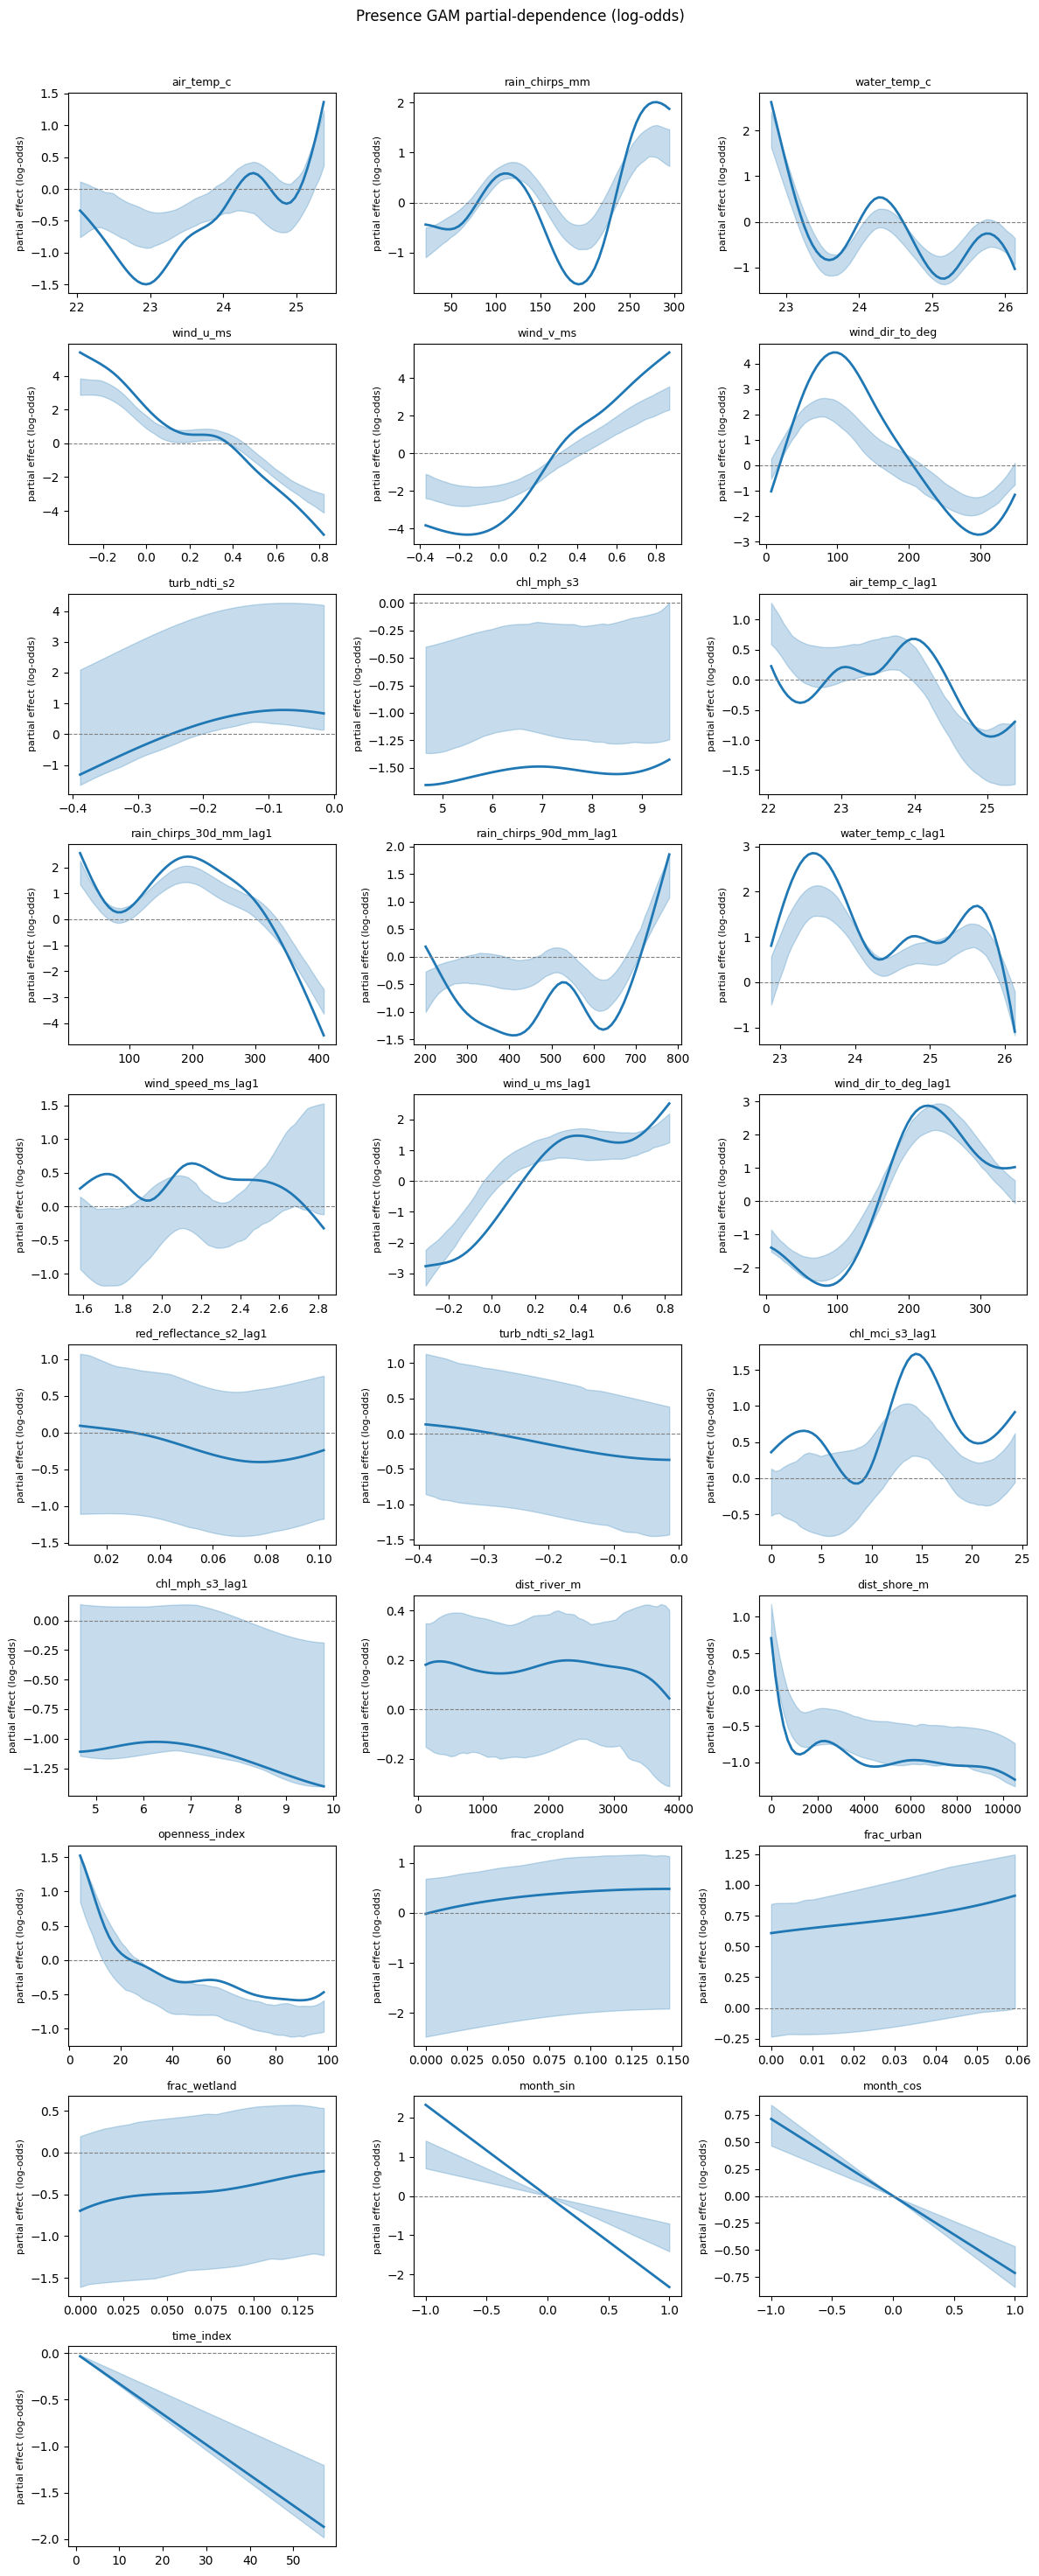

Saved /content/drive/MyDrive/WH_spatial_panel_test/driver_gam_cover_pdep.png


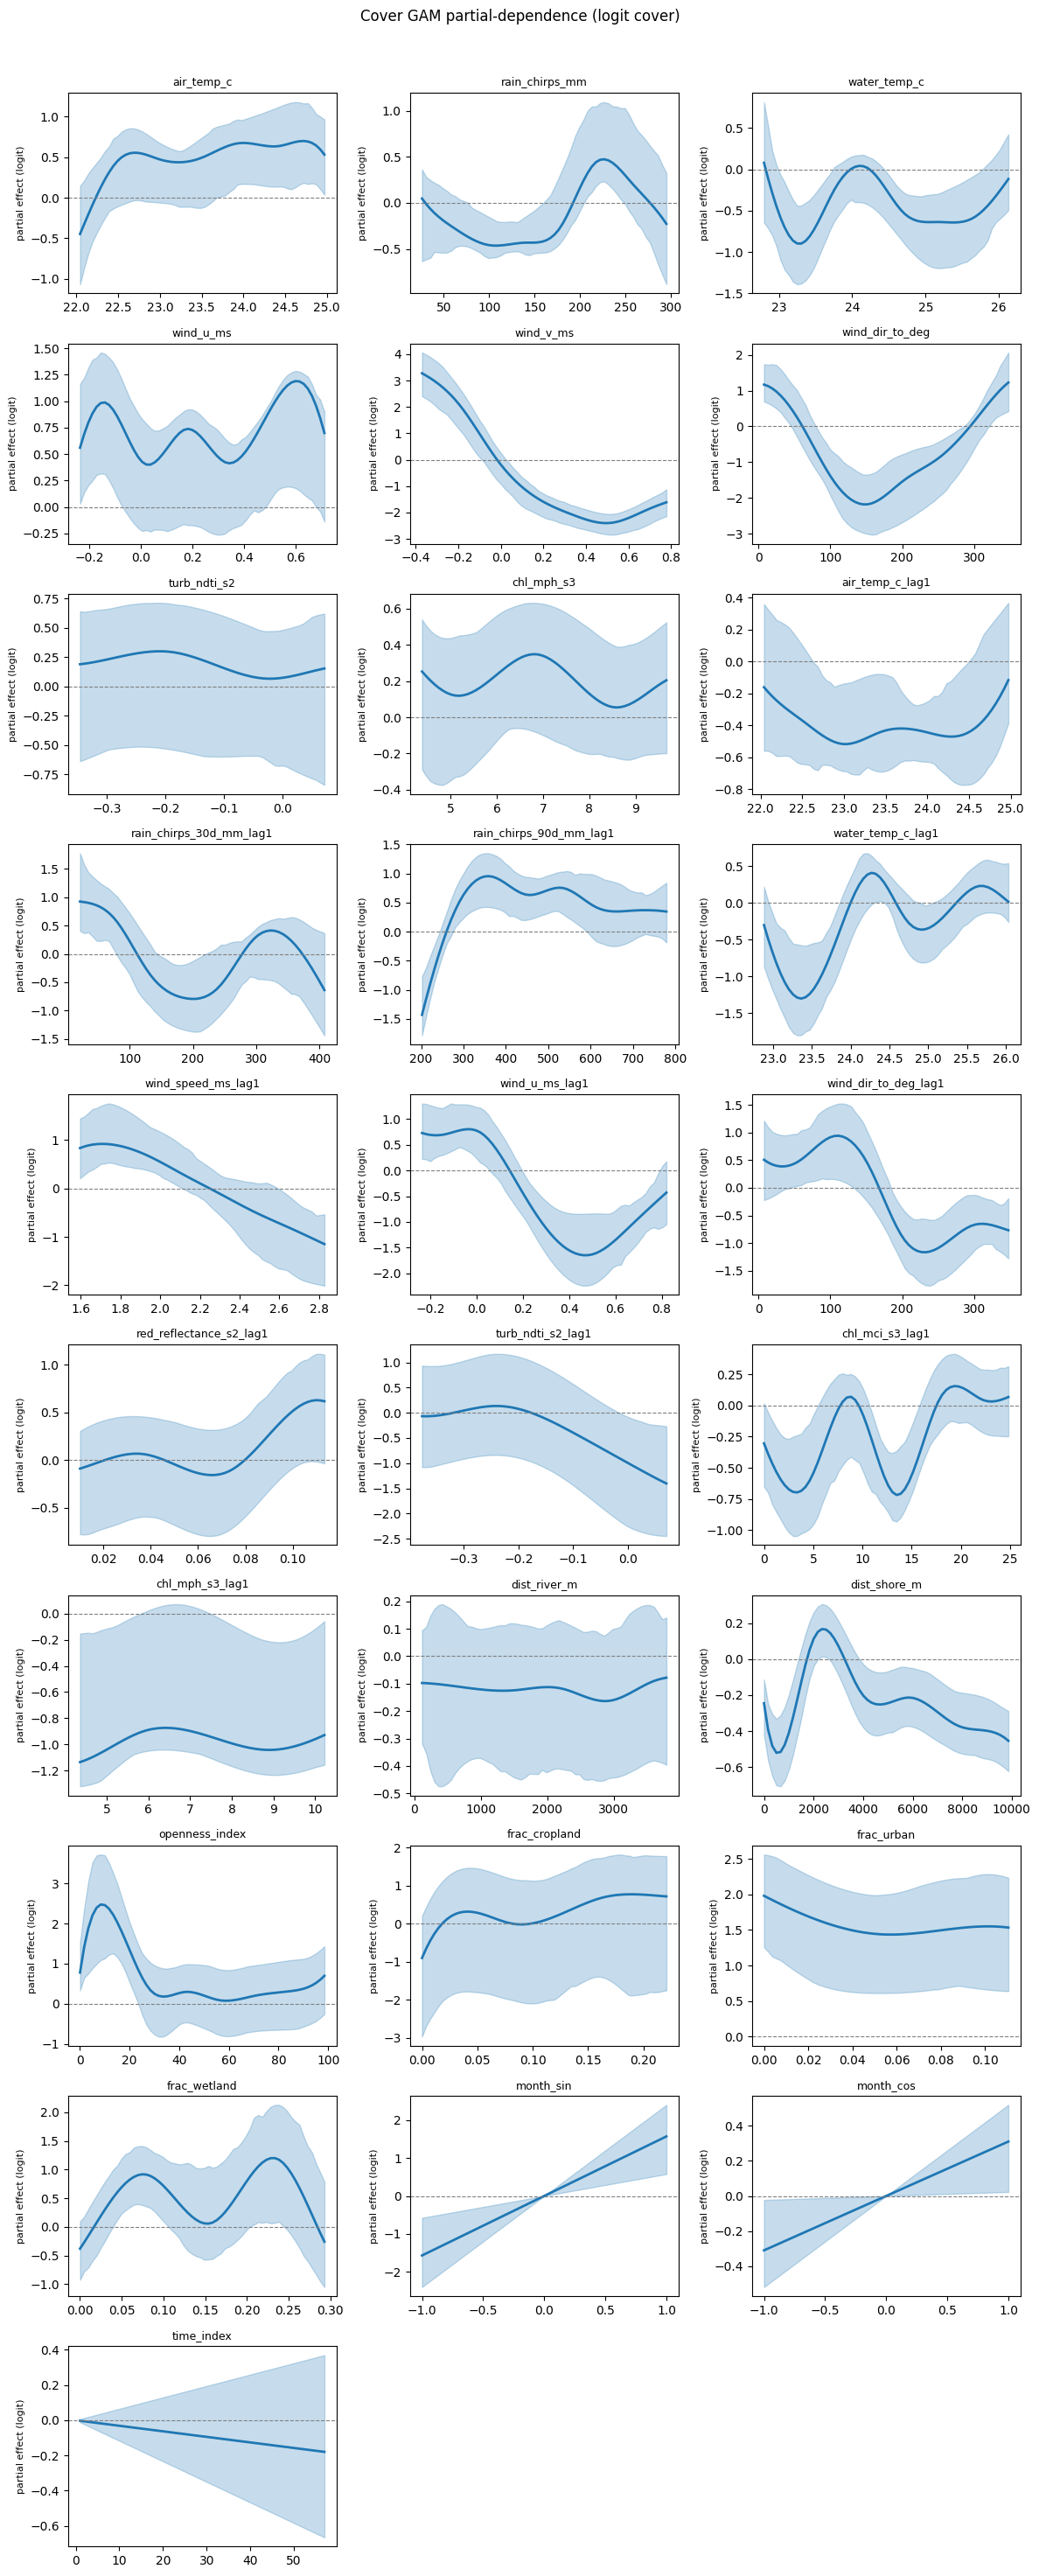

Presence residuals: Moran's I = 0.2675 (p = 0.0010) over 10,828 cells
  -> residual spatial autocorrelation remains; consider a finer te(x, y) surface or an explicit spatial term.
Cover residuals: Moran's I = 0.3558 (p = 0.0010) over 10,814 cells
  -> residual spatial autocorrelation remains; consider a finer te(x, y) surface or an explicit spatial term.


In [34]:
# Partial-dependence plots (point curve + cluster-bootstrap 95% band) and a Moran's I
# residual spatial-autocorrelation check: does the te(x, y) surface absorb the spatial
# signal the GLMM random intercept used to handle, or is an explicit spatial term still
# needed?  Requires: pip install libpysal esda
def plot_pdep(pdep_table, title, link_label, fname):
    if pdep_table is None or pdep_table.empty:
        print(f"{title}: nothing to plot.")
        return
    terms = list(pdep_table["term"].unique())
    ncol = 3
    nrow = int(np.ceil(len(terms) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3 * nrow), squeeze=False)
    flat = axes.ravel()
    for ax, term in zip(flat, terms):
        d = pdep_table[pdep_table["term"] == term]
        ax.plot(d["x"], d["pdep"], color="C0", lw=2)
        if d["ci_low"].notna().any():
            ax.fill_between(d["x"], d["ci_low"], d["ci_high"], color="C0", alpha=0.25)
        ax.axhline(0, color="grey", lw=0.8, ls="--")
        ax.set_title(term, fontsize=9)
        ax.set_ylabel(f"partial effect ({link_label})", fontsize=8)
    for ax in flat[len(terms):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    out = OUTPUT_DIR / fname
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print("Saved", out)
    plt.show()

plot_pdep(presence_pdep_table, "Presence GAM partial-dependence (log-odds)",
          "log-odds", "driver_gam_presence_pdep.png")
plot_pdep(cover_pdep_table, "Cover GAM partial-dependence (logit cover)",
          "logit", "driver_gam_cover_pdep.png")

# ---- Moran's I on per-cell mean residuals -------------------------------------
try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    _HAVE_PYSAL = True
except Exception as exc:
    _HAVE_PYSAL = False
    print("libpysal/esda not available (pip install libpysal esda):", repr(exc))

def _report_moran(label, df, resid, k=8):
    tmp = df[[DRIVER_GROUP_COL, "x_km", "y_km"]].copy()
    tmp["resid"] = np.asarray(resid, float)
    agg = tmp.groupby(DRIVER_GROUP_COL, as_index=False).agg(
        x_km=("x_km", "mean"), y_km=("y_km", "mean"), resid=("resid", "mean"))
    if len(agg) < 10:
        print(f"{label}: too few cells for Moran's I.")
        return
    w = KNN.from_array(agg[["x_km", "y_km"]].values, k=min(k, len(agg) - 1))
    w.transform = "r"
    mi = Moran(agg["resid"].values, w, permutations=999)
    print(f"{label}: Moran's I = {mi.I:.4f} (p = {mi.p_sim:.4f}) over {len(agg):,} cells")
    if mi.p_sim < 0.05:
        print("  -> residual spatial autocorrelation remains; consider a finer "
              "te(x, y) surface or an explicit spatial term.")
    else:
        print("  -> no significant residual spatial autocorrelation; the te(x, y) "
              "surface appears sufficient.")

if _HAVE_PYSAL:
    if presence_gam is not None:
        try:
            _report_moran("Presence residuals", driver_source,
                          y_pres - presence_gam.predict_mu(Xd))
        except Exception as exc:
            print("Presence Moran's I failed:", repr(exc))
    if cover_gam is not None:
        try:
            _report_moran("Cover residuals", driver_source[cover_mask],
                          y_cover_logit - cover_gam.predict_mu(Xc))
        except Exception as exc:
            print("Cover Moran's I failed:", repr(exc))


In [35]:
# Save the GAM driver-model outputs next to the other exports.
import datetime as _dt
_stamp = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
for _name, _tab in [
    ("vif", vif_table),
    ("presence_gam_effects", presence_effect_table),
    ("presence_gam_pdep", presence_pdep_table),
    ("cover_gam_effects", cover_effect_table),
    ("cover_gam_pdep", cover_pdep_table),
]:
    if _tab is not None:
        _path = OUTPUT_DIR / f"driver_{_name}_{_stamp}.csv"
        _tab.to_csv(_path, index=False)
        print("Saved", _path)


Saved /content/drive/MyDrive/WH_spatial_panel_test/driver_vif_20260620_135807.csv
Saved /content/drive/MyDrive/WH_spatial_panel_test/driver_presence_gam_effects_20260620_135807.csv
Saved /content/drive/MyDrive/WH_spatial_panel_test/driver_presence_gam_pdep_20260620_135807.csv
Saved /content/drive/MyDrive/WH_spatial_panel_test/driver_cover_gam_effects_20260620_135807.csv
Saved /content/drive/MyDrive/WH_spatial_panel_test/driver_cover_gam_pdep_20260620_135807.csv


## 16. Map mean observed WH cover by grid cell

This checks whether the spatial pattern looks ecologically sensible.

Cells with consistently high cover should generally correspond to sheltered littoral/embayment zones if the classification and grid design are working.

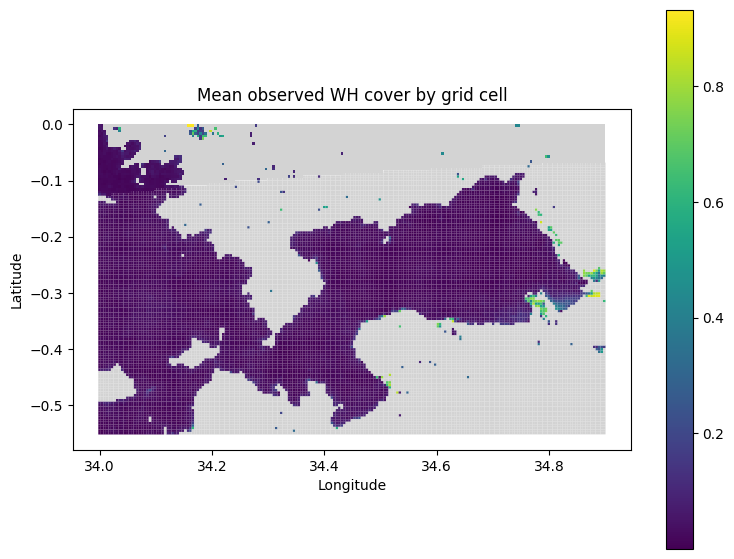

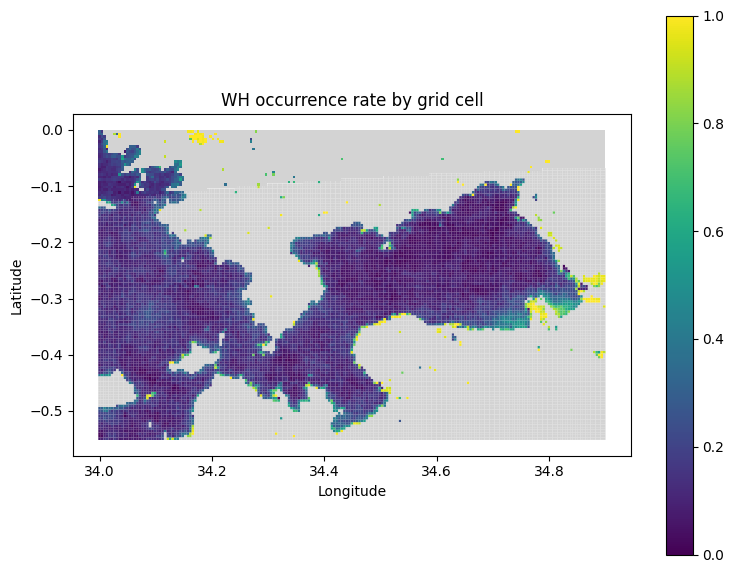

In [36]:
cell_summary = (
    panel.groupby("grid_id", as_index=False)
    .agg(
        mean_wh_cover=("wh_cover", "mean"),
        max_wh_cover=("wh_cover", "max"),
        occurrence_rate=("wh_present", "mean"),
        mean_wh_area_ha=("wh_area_ha", "mean"),
        n_months=("month", "nunique"),
    )
)

grid_summary = grid.merge(cell_summary, on="grid_id", how="left")

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="mean_wh_cover",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("Mean observed WH cover by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

ax = grid_summary.to_crs("EPSG:4326").plot(
    column="occurrence_rate",
    figsize=(9, 7),
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No valid observations"},
)
ax.set_title("WH occurrence rate by grid cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 17. Export outputs

In addition to the panel, predictions, monthly summary, coefficients and grid summary, the raw Earth Engine covariate tables (`ee_monthly_cov`, `ee_cellmonth_cov`, `ee_static_cov`) are saved when they were produced, so the extracted drivers can be inspected or reused without re-querying Earth Engine.

In [37]:
panel_csv = OUTPUT_DIR / f"wh_spatial_panel_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
test_preds_csv = OUTPUT_DIR / f"wh_spatial_panel_predictions_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
monthly_summary_csv = OUTPUT_DIR / f"wh_monthly_summary_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
coef_csv = OUTPUT_DIR / f"wh_model_coefficients_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
grid_summary_gpkg = OUTPUT_DIR / f"wh_grid_summary_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.gpkg"

panel.to_csv(panel_csv, index=False)
test_preds.to_csv(test_preds_csv, index=False)
monthly_summary.to_csv(monthly_summary_csv, index=False)

coef_out = presence_coef.merge(cover_coef, on="feature", how="outer")
coef_out.to_csv(coef_csv, index=False)

grid_summary.to_file(grid_summary_gpkg, layer="grid_summary", driver="GPKG")

saved_paths = [panel_csv, test_preds_csv, monthly_summary_csv, coef_csv, grid_summary_gpkg]

# Also save the raw Earth Engine covariate tables when they were produced.
ee_covariate_tables = {
    "ee_monthly_covariates": ee_monthly_cov,
    "ee_cellmonth_covariates": ee_cellmonth_cov,
    "ee_static_covariates": ee_static_cov,
}
for name, table in ee_covariate_tables.items():
    if table is not None and len(table) > 0:
        out_csv = OUTPUT_DIR / f"{name}_{CELL_SIZE_M}m_{TEST_START}_to_{TEST_END}.csv"
        table.to_csv(out_csv, index=False)
        saved_paths.append(out_csv)

print("Saved:")
for p in saved_paths:
    print(p)

Saved:
/content/drive/MyDrive/WH_spatial_panel_test/wh_spatial_panel_500m_2017-01-01_to_2026-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_spatial_panel_predictions_500m_2017-01-01_to_2026-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_monthly_summary_500m_2017-01-01_to_2026-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_model_coefficients_500m_2017-01-01_to_2026-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/wh_grid_summary_500m_2017-01-01_to_2026-12-31.gpkg
/content/drive/MyDrive/WH_spatial_panel_test/ee_monthly_covariates_500m_2017-01-01_to_2026-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/ee_cellmonth_covariates_500m_2017-01-01_to_2026-12-31.csv
/content/drive/MyDrive/WH_spatial_panel_test/ee_static_covariates_500m_2017-01-01_to_2026-12-31.csv


## Model diagnosis after threshold and target-definition changes

A concise summary of the presence-definition and threshold changes and their
effect on predicted WH extent.


In [38]:
print("=" * 70)
print("MODEL DIAGNOSIS AFTER THRESHOLD AND TARGET-DEFINITION CHANGES")
print("=" * 70)

# 1. Presence definition.
print(f"\nPresence definition: {presence_definition}")

# 2. Selected probability threshold.
print(f"Selected probability threshold: {selected_threshold:.2f} "
      f"(metric={PRESENCE_THRESHOLD_METRIC}, tuned on {threshold_source})")


# 3. Train / validation / test months.
def _months_range(arr):
    arr = list(arr)
    if len(arr) == 0:
        return "(none)"
    return f"{pd.Timestamp(min(arr)).date()} to {pd.Timestamp(max(arr)).date()} ({len(arr)} months)"


print(f"\nFitting months:    {_months_range(fit_months)}")
print(f"Validation months: {_months_range(val_months)}")
print(f"Test months:       {_months_range(test['month'].unique())}")

# 4. Presence model precision / recall / F1 on TEST.
prec_t = precision_score(y_test_presence, test_presence_pred, zero_division=0)
rec_t = recall_score(y_test_presence, test_presence_pred, zero_division=0)
f1_t = f1_score(y_test_presence, test_presence_pred, zero_division=0)
prec_0 = precision_score(y_test_presence, test_presence_pred_05, zero_division=0)
rec_0 = recall_score(y_test_presence, test_presence_pred_05, zero_division=0)
f1_0 = f1_score(y_test_presence, test_presence_pred_05, zero_division=0)
print(f"\nPresence model (TEST) @ tuned {selected_threshold:.2f}: "
      f"precision={prec_t:.3f}, recall={rec_t:.3f}, F1={f1_t:.3f}")
print(f"Presence model (TEST) @ legacy 0.50: "
      f"precision={prec_0:.3f}, recall={rec_0:.3f}, F1={f1_0:.3f}")

# 5. Observed vs predicted area by test month.
print("\nTest-month observed vs predicted WH area (ha):")
display(area_compare_display)

# 6. Notes on whether the model still under-predicts.
obs_total = area_compare["observed_wh_area_ha"].sum()
pred_total_tuned = area_compare["pred_area_ha_tuned"].sum()
pred_total_05 = area_compare["pred_area_ha_05"].sum()
ratio_tuned = (pred_total_tuned / obs_total) if obs_total > 0 else np.nan
ratio_05 = (pred_total_05 / obs_total) if obs_total > 0 else np.nan

print("\nNotes:")
print(f"- Tuned threshold recovers {ratio_tuned:.0%} of observed test-period WH area "
      f"(legacy 0.5 recovered {ratio_05:.0%})." if np.isfinite(ratio_tuned)
      else "- Observed test-period WH area is zero, so recovery ratios are undefined.")
if np.isfinite(ratio_tuned) and ratio_tuned < 0.8:
    print("- The model still UNDER-predicts total WH extent (< 80% of observed). "
          "Consider a lower presence threshold, the higher-recall probability "
          "threshold, or additional habitat covariates.")
elif np.isfinite(ratio_tuned) and ratio_tuned > 1.2:
    print("- The model now OVER-predicts total WH extent (> 120% of observed). "
          "Consider a higher presence/probability threshold.")
else:
    print("- Total predicted WH extent is broadly consistent with observed (within +/-20%).")
print(f"- Presence recall changed from {rec_0:.2f} (legacy 0.5) to {rec_t:.2f} (tuned).")


MODEL DIAGNOSIS AFTER THRESHOLD AND TARGET-DEFINITION CHANGES

Presence definition: wh_cover >= 0.02 (fractional cover)
Selected probability threshold: 0.15 (metric=prevalence_match, tuned on validation months (calibrated))

Fitting months:    2020-12-01 to 2023-07-01 (32 months)
Validation months: 2023-08-01 to 2024-05-01 (10 months)
Test months:       2024-06-01 to 2025-08-01 (15 months)

Presence model (TEST) @ tuned 0.15: precision=0.490, recall=0.353, F1=0.411
Presence model (TEST) @ legacy 0.50: precision=0.849, recall=0.131, F1=0.227

Test-month observed vs predicted WH area (ha):


,month,observed_wh_area_ha,pred_area_ha_05,pred_area_ha_tuned,abs_err_05_ha,pct_err_05,abs_err_tuned_ha,pct_err_tuned
0,2024-06-01,2197.48,117.99,557.79,2079.49,-94.6,1639.69,-74.6
1,2024-07-01,1943.90,288.68,694.74,1655.21,-85.1,1249.16,-64.3
2,2024-08-01,2406.50,1201.22,5468.61,1205.29,-50.1,3062.10,127.2
3,2024-09-01,6623.79,894.39,3063.93,5729.40,-86.5,3559.86,-53.7
4,2024-10-01,3943.90,1315.60,5458.72,2628.30,-66.6,1514.82,38.4
5,2024-11-01,2138.57,400.93,1163.67,1737.64,-81.3,974.90,-45.6
6,2024-12-01,2776.16,1944.72,6069.62,831.44,-29.9,3293.46,118.6
7,2025-01-01,1365.64,1021.71,2218.08,343.93,-25.2,852.44,62.4
8,2025-02-01,1095.26,713.91,1285.27,381.34,-34.8,190.01,17.3
9,2025-03-01,1156.82,441.65,1144.24,715.17,-61.8,12.58,-1.1



Notes:
- Tuned threshold recovers 101% of observed test-period WH area (legacy 0.5 recovered 28%).
- Total predicted WH extent is broadly consistent with observed (within +/-20%).
- Presence recall changed from 0.13 (legacy 0.5) to 0.35 (tuned).


## 18. Interpretation checklist

Use this checklist before treating the results as environmental inference.

### Raster/classification checks

- Confirm that `WH_CLASS_VALUES` correctly identifies water hyacinth.
- Inspect several classified rasters visually.
- Check that missing/cloudy months are not being interpreted as true WH absence.
- **Implemented:** the response can use a **confidence-weighted** WH cover from the classifier probability rasters (`USE_PROBABILITY_RESPONSE`); the classifier-accuracy/confidence cell reports the measurement error entering the response (Priority 2).
- Compare S1-derived and S2-derived classifications separately if both are present.

### Earth Engine covariate checks

- Confirm Earth Engine initialised on the expected project (`EE_PROJECT`) and that section 8 reported the covariate columns you expected.
- The coarse climate layers (CHIRPS, ERA5, MODIS) are **AOI-mean monthly** values, so they vary in time but not between cells; treat them as regional forcing, not local gradients.
- Sentinel-2 turbidity (NDTI + red reflectance) is a **proxy**, not calibrated turbidity/TSS; cloudy months legitimately come back as missing and are imputed in the model.
- `water_temp_c` (MODIS LST over water) and the water-quality proxies are masked to JRC permanent water at `EE_WATER_OCCURRENCE_THRESHOLD`; cells that are mostly land will be missing.
- Chlorophyll-a now comes solely from Sentinel-3 OLCI (MCI/MPH). MODIS-Aqua chl-a is off by default (`chl_modis=False`; it ends 2022-02-28 and is unreliable in turbid inland water) and the Sentinel-2 NDCI chl-a proxy is off (`EE_S2_PRODUCTS={'turbidity'}`). Add 'chla' to EE_S2_PRODUCTS or set chl_modis=True to re-enable those cross-checks.
- Sentinel-3 chl-a (`chl_mci_s3`, `chl_mph_s3`) follows Kravitz et al. (2020): MCI/MPH band-difference algorithms on OLCI **TOA reflectance**, because GEE's OLCI asset lacks the geometry/meteorology needed for the paper's BRR/6SV corrections. The MPH calibration is BRR-derived applied to TOA reflectance, and none of the calibrations are tuned for Winam Gulf, so treat the mg/m³ values as indicative and locally re-calibrate against in-situ chl-a where possible.
- Check the bay-axis assumption: `EE_BAY_AXIS_BEARING_DEG` should match the orientation of the gulf you are modelling.

### Panel-design checks

- Test 500 m vs 1 km cells (1 km is much faster for the per-cell Earth Engine reductions).
- **Implemented:** the grid is restricted to a water/littoral mask via `WATER_MASK_SOURCE` (default `bathymetry`, with `MIN_WATER_FRACTION`); check the dropped-cell counts printed by the habitat filter and tune the threshold.
- Avoid pixel-level modelling because this creates extreme pseudo-replication.
- Check whether high-cover cells correspond to plausible embayments, sheltered shores or river-mouth zones.

### Modelling checks

- Use temporally blocked validation.
- **Implemented:** rolling-origin temporal CV **and** spatial block CV are in section 15b (Roberts et al. 2017; Ploton et al. 2020); report the spatial-block scores, not just the single split.
- **Implemented:** residual spatial autocorrelation (Moran's I) is checked on the predictive presence model and on the GAM; if it stays significant, lean on the neighbour spatial-lag term (`wh_cover_neigh_lag1`) and an explicit spatial effect (Dormann et al. 2007).
- **Implemented:** a queen/rook neighbour spatial-lag of the lagged response (`NEIGHBOUR_LAG_ENABLED`) captures drift/colonisation (autologistic-style; Augustin et al. 1996).
- Check collinearity among rainfall, antecedent rainfall, turbidity, chlorophyll-a, temperature and lake level (the Earth Engine layers add several correlated predictors).
- Treat coefficients as associations, not proof of causation.
- For the final dissertation, consider a GAM, GLMM, hurdle model or Bayesian spatio-temporal model if time allows.

### Layers still to add from non-Earth-Engine sources

The Earth Engine extraction now covers rainfall, wind, temperature, water-quality proxies, river/shore geometry and catchment pressure. The remaining recommended drivers have no standard Earth Engine asset and should be supplied through `ENV_MONTHLY_CSV` / `SPATIAL_COVARIATES_CSV`:

- lake-level anomaly (DAHITI, Hydroweb, G-REALM or Jason/Sentinel altimetry);
- ENSO/IOD indices (ONI/Niño 3.4, Dipole Mode Index) for temporal models;
- in-situ nutrients (TN, TP, DIN, SRP) as mechanistic/confounder variables.

**Bathymetric depth is now included** as a static habitat covariate (`depth_m`, sampled from the Lake Victoria analytical bathymetry raster), which also defines the water mask. Adding **lake level** next — and a level×depth interaction — would complete the move from a technical prototype to a genuinely ecological spatio-temporal model.

**Key references:** Kravitz et al. (2020), *Remote Sensing of Environment* 237:111562 (Sentinel-3 OLCI chl-a, atmospheric-correction comparison); Matthews et al. (2012), *Remote Sensing of Environment* 124:637–652 (MPH algorithm). Methodological additions in this version: Barve et al. (2011), *Ecol. Modelling* 222:1810 (accessible-area/background restriction); Roberts et al. (2017), *Ecography* 40:913 and Ploton et al. (2020), *Nat. Commun.* 11:4540 (spatial/temporal block cross-validation); Dormann et al. (2007), *Ecography* 30:609 (residual spatial autocorrelation); Augustin et al. (1996), *J. Appl. Ecol.* 33:339 (autologistic neighbour term); Hirzel et al. (2006), *Ecol. Modelling* 199:142 (Boyce index); Lobo et al. (2008), *Glob. Ecol. Biogeogr.* 17:145 (limits of AUC).